In [1]:
# papermill parameters -- overridden at runtime by pipeline.py
ARTIFACT_DIR = ""
SAMPLE_DIR   = ""
MODEL_ID     = ""
SNAPSHOT_ID  = ""  # optional override; notebook resolves from manifest if empty


In [2]:
# Parameters
ARTIFACT_DIR = "D:\\repos\\chronoquant\\artifacts\\lgbm_solusdt_s_fw60_2101_2605"
SAMPLE_DIR = "D:\\repos\\chronoquant\\artifacts\\lgbm_solusdt_s_fw60_2101_2605"
MODEL_ID = "lgbm_solusdt_s_fw60_2101_2605"
SNAPSHOT_ID = "solusdt_fw60_2101_2605__21668185"


## Cél

A `lgbm_solusdt_s_fw60_2101_2605` short modell összes feature-jének prediktív erejét vizsgáljuk `ContinuousOptimalBinning` segítségével (max 10 bin per feature). Minden feature-re:
- Optimális bin-ekre osztjuk a feature értékeit (max 10 bin)
- A bin-enkénti target átlagot scatter ploton ábrázoljuk regressziós egyenessel
- IV (Information Value) és MI (Mutual Information) értéket számolunk a prediktív erő összehasonlíthatóságához

**Target:** `short_mfe_fw60` — short MFE 60 perces ablakban. Negatív értékek = profitábilis short mozgás.

**Struktúra:** Egy szekció = egy feature csoport. Minden csoportnál: IV tábla → korrelációs mátrix → tabset (egy fül = egy feature).
**Összefoglaló tábla** a plotok után.

In [3]:
import sys
import io
import base64
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from IPython.display import display, Markdown
from optbinning import ContinuousOptimalBinning
from sklearn.feature_selection import mutual_info_regression

from analyst.lib.db_utils import find_repo_root
_root = find_repo_root()
sys.path.insert(0, str(_root))
sys.path.insert(0, str(_root / "src"))

import utils
from analyst.lib.table_formatting import display_analysis_table, analysis_table_html
from analyst.lib.plot_utils import CQ_COLORS, setup_cq_theme
setup_cq_theme()

# ── Runtime paraméterek (papermill injektálja, fallback fejlesztéshez) ───────
MODEL_ID    = MODEL_ID    or "lgbm_solusdt_s_fw60_2101_2605"
SNAPSHOT_ID = SNAPSHOT_ID or ""   # üres — runtime-ban lesz feltöltve manifest-ből
ARTIFACT_DIR_PATH = Path(ARTIFACT_DIR) if ARTIFACT_DIR else (
    _root / "artifacts" / MODEL_ID
)
_direction  = MODEL_ID.split("_")[2] if len(MODEL_ID.split("_")) > 2 else "l"
TARGET      = "long_mfe_fw60" if _direction == "l" else "short_mfe_fw60"

# ── SNAPSHOT_ID fallback from manifest ───────────────────────────────────────
if not SNAPSHOT_ID:
    import json
    _manifest_path = ARTIFACT_DIR_PATH / "manifest.json"
    if _manifest_path.exists():
        _manifest = json.loads(_manifest_path.read_text(encoding="utf-8"))
        SNAPSHOT_ID = _manifest.get("snapshot_id", "")
    if not SNAPSHOT_ID:
        raise ValueError(f"SNAPSHOT_ID could not be resolved from manifest at {_manifest_path}")

# ── GROUP_MAP (same as long model — feature groups are model-agnostic) ────────
GROUP_MAP = {
    "feat_rsi_delta": "Accel", "feat_roc_delta": "Accel",
    "feat_return_momentum_delta": "Accel",
    "feat_rsi_x_trend": "Interaction", "feat_volume_x_momentum": "Interaction",
    "feat_rsi": "Momentum", "feat_roc": "Momentum", "feat_stoch_k": "Momentum",
    "feat_stoch_d": "Momentum", "feat_williams_r": "Momentum", "feat_cci": "Momentum",
    "feat_ema_slope_": "Trend Slope",
    "feat_sma_ratio": "Trend", "feat_ema_ratio": "Trend", "feat_wma_ratio": "Trend",
    "feat_kama_ratio": "Trend", "feat_macd_signal": "Trend", "feat_macd_diff": "Trend",
    "feat_macd": "Trend", "feat_adx_pos": "Trend", "feat_adx_neg": "Trend",
    "feat_adx": "Trend",
    "feat_bb_width": "Volatility", "feat_bb_position": "Volatility",
    "feat_atr_dist_high": "Market Structure", "feat_atr_dist_low": "Market Structure",
    "feat_atr": "Volatility", "feat_natr": "Volatility", "feat_hist_vol": "Volatility",
    "feat_parkinson_vol": "Volatility", "feat_gk_vol": "Volatility",
    "feat_volume_confirmed_return_": "Volume",
    "feat_volume_accel_": "Volume", "feat_volume_rank_": "Volume",
    "feat_volume_sma": "Volume", "feat_volume_ratio": "Volume",
    "feat_obv_roc": "Volume", "feat_obv": "Volume",
    "feat_mfi": "Volume", "feat_ad_line": "Volume", "feat_cmf": "Volume",
    "feat_returns_log": "Price Action", "feat_returns_sma": "Price Action",
    "feat_returns_std": "Price Action", "feat_returns_skew": "Price Action",
    "feat_returns_kurt": "Price Action",
    "feat_hml_range": "Price Action", "feat_ohlc_range": "Price Action",
    "feat_close_position": "Price Action",
    "feat_prev_session_high_dist": "Market Structure",
    "feat_prev_session_low_dist": "Market Structure",
    "feat_rolling_drawdown_": "Market Structure",
    "feat_dist_rolling_": "Market Structure",
    "feat_range_expansion_": "Market Structure",
    "feat_recovery_ratio": "Market Structure", "feat_max_drawdown": "Market Structure",
    "feat_time_since_high": "Market Structure", "feat_time_since_low": "Market Structure",
    "feat_efficiency_ratio": "Market Structure",
    "feat_regime_rank": "Regime Rank", "feat_return_autocorr": "Autocorrelation",
    "feat_variance_ratio": "Autocorrelation",
    "feat_lower_wick_ratio": "Candle Pattern", "feat_upper_wick_ratio": "Candle Pattern",
    "feat_signed_body_": "Candle Pattern", "feat_wick_imbalance_": "Candle Pattern",
    "feat_doji": "Candle Pattern", "feat_hammer": "Candle Pattern",
    "feat_shooting_star": "Candle Pattern", "feat_inside_bar": "Candle Pattern",
    "feat_outside_bar": "Candle Pattern", "feat_engulf_bull": "Candle Pattern",
    "feat_engulf_bear": "Candle Pattern", "feat_bull_bars_ratio": "Candle Pattern",
    "feat_body_ratio": "Candle Pattern", "feat_wick_ratio": "Candle Pattern",
    "feat_lr_slope": "Trend Slope", "feat_lr_r2": "Trend Slope",
    "feat_lr_residual": "Trend Slope", "feat_trend_slope": "Trend Slope",
    "feat_pos_return_mean": "Tail Risk", "feat_neg_return_mean": "Tail Risk",
    "feat_return_asymmetry": "Tail Risk",
    "feat_gap_open_abs_sma": "Gap", "feat_gap_open": "Gap",
    "feat_tenkan_kijun_": "Ichimoku", "feat_price_vs_": "Ichimoku",
    "feat_tenkan_ratio": "Ichimoku", "feat_kijun_ratio": "Ichimoku",
    "feat_senkou_b_ratio": "Ichimoku", "feat_ichimoku_cloud_thickness": "Ichimoku",
    "feat_donchian_width": "Donchian", "feat_donchian_position": "Donchian",
    "feat_donchian_breakout": "Donchian",
    "feat_hour_sin": "Time/Session", "feat_hour_cos": "Time/Session",
    "feat_dayofweek_sin": "Time/Session", "feat_dayofweek_cos": "Time/Session",
    "feat_weekend": "Time/Session", "feat_session_asia": "Time/Session",
    "feat_session_europe": "Time/Session", "feat_session_us": "Time/Session",
    "feat_bars_into_session_norm": "Time/Session", "feat_day_range_position": "Time/Session",
    "feat_day_open_return": "Time/Session", "feat_weekly_open_return": "Time/Session",
    "feat_dist_sma": "Return Distance", "feat_dist_bb": "Return Distance",
    "feat_return_z_": "Price Action", "feat_vol_adj_return_": "Price Action",
    "feat_return_": "Price Action",
    "feat_higher_high_": "Swing", "feat_higher_low_": "Swing",
    "feat_lower_high_": "Swing", "feat_lower_low_": "Swing",
    "feat_swing_": "Swing", "feat_directional_agreement_": "Swing",
    "feat_taker_": "Taker Flow", "feat_avg_trade_": "Taker Flow",
    "feat_trade_count_": "Taker Flow", "feat_quote_volume_": "Taker Flow",
}

def assign_group(feat_name):
    for prefix, group in GROUP_MAP.items():
        if feat_name.startswith(prefix):
            return group
    return "Other"

# ── Data load ─────────────────────────────────────────────────────────────────
conn = utils.open_lab_connection("solusdt")
df_all = conn.execute(f"""
    SELECT s.*, m.split
    FROM snap."{SNAPSHOT_ID}" AS s
    INNER JOIN model."{MODEL_ID}__sample" AS m
        ON s.open_time = m.open_time
    ORDER BY s.open_time
""").fetchdf()
conn.close()

feat_cols = [c for c in df_all.columns if c.startswith("feat_")]
df_train  = df_all[df_all["split"] == 0].copy()

groups_df = pd.DataFrame([
    {"Group": assign_group(f), "Feature": f} for f in sorted(feat_cols)
]).sort_values(["Group", "Feature"]).reset_index(drop=True)

_null_rates = df_train[feat_cols].isnull().mean()
_inf_rates  = df_train[feat_cols].apply(lambda c: c.apply(lambda v: v == float('inf') or v == float('-inf')).mean())
_variances  = df_train[feat_cols].var()
_quality_bad = set(
    _null_rates[_null_rates > 0.01].index.tolist() +
    _inf_rates[_inf_rates > 0.001].index.tolist() +
    _variances[_variances < 1e-8].index.tolist()
)
feat_cols_quality_dropped = sorted(_quality_bad)
feat_cols = [f for f in feat_cols if f not in _quality_bad]
display(Markdown(f"**Quality szűrő:** {len(feat_cols_quality_dropped)} feature kizárva | Maradék: {len(feat_cols)}"))
n_other = (groups_df["Group"] == "Other").sum()
display(Markdown(
    f"**Adatbetöltés kész** | Train sorok: {len(df_train):,} "
    f"| Feature-ök: {len(feat_cols)} | Csoportok: {groups_df['Group'].nunique()} | Other: {n_other}"
))


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

**Quality szűrő:** 2 feature kizárva | Maradék: 206

**Adatbetöltés kész** | Train sorok: 37,939 | Feature-ök: 206 | Csoportok: 17 | Other: 0

In [4]:
#| label: tbl-iv-precompute
#| echo: false

iv_results = {}

for feat in feat_cols:
    x = df_train[feat].dropna()
    y = df_train.loc[x.index, TARGET]
    if len(x) < 50:
        iv_results[feat] = {"iv": float("nan"), "n_bins": 0, "bin_data": None}
        continue
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            ob = ContinuousOptimalBinning(name=feat, max_n_bins=10)
            ob.fit(x.values, y.values)
            bt = ob.binning_table.build()
            bin_data = bt[~bt["Bin"].isin(["Special", "Missing"])].copy()
            iv_results[feat] = {"iv": ob.binning_table.iv, "n_bins": len(bin_data),
                                "bin_data": bin_data, "ob": ob}
    except Exception:
        iv_results[feat] = {"iv": float("nan"), "n_bins": 0, "bin_data": None}

n_ok = sum(1 for v in iv_results.values() if v["bin_data"] is not None)
print(f"IV számítás kész: {n_ok}/{len(feat_cols)} feature OK")

_X_mi = df_train[feat_cols].fillna(df_train[feat_cols].median())
_valid_mi = df_train[TARGET].notna()
_mi_vals = mutual_info_regression(
    _X_mi[_valid_mi], df_train.loc[_valid_mi, TARGET],
    discrete_features=False, random_state=42,
)
_mi_dict = dict(zip(feat_cols, _mi_vals))
for _f in feat_cols:
    iv_results[_f]["mi"] = round(_mi_dict.get(_f, float("nan")), 5)

n_ok_mi = sum(1 for v in iv_results.values() if not (v.get("mi") != v.get("mi")))
print(f"MI számítás kész: {n_ok_mi}/{len(feat_cols)} feature OK")


IV számítás kész: 206/206 feature OK


MI számítás kész: 206/206 feature OK



## Price Action



<style type="text/css">
#T_3e071  {
  border-collapse: collapse;
  border: 1px solid black;
}
#T_3e071 th {
  border: 1px solid black;
  padding: 4px 8px;
  text-align: center;
}
#T_3e071 td {
  border: 1px solid black;
  padding: 4px 8px;
}
#T_3e071 thead th {
  border-bottom: 2px solid black;
}
#T_3e071_row0_col0, #T_3e071_row0_col4, #T_3e071_row1_col0, #T_3e071_row1_col4, #T_3e071_row2_col0, #T_3e071_row2_col4, #T_3e071_row3_col0, #T_3e071_row3_col4, #T_3e071_row4_col0, #T_3e071_row4_col4, #T_3e071_row5_col0, #T_3e071_row5_col4, #T_3e071_row6_col0, #T_3e071_row6_col4, #T_3e071_row7_col0, #T_3e071_row7_col4, #T_3e071_row8_col0, #T_3e071_row8_col4, #T_3e071_row9_col0, #T_3e071_row9_col4, #T_3e071_row10_col0, #T_3e071_row10_col4, #T_3e071_row11_col0, #T_3e071_row11_col4, #T_3e071_row12_col0, #T_3e071_row12_col4, #T_3e071_row13_col0, #T_3e071_row13_col4, #T_3e071_row14_col0, #T_3e071_row14_col4, #T_3e071_row15_col0, #T_3e071_row15_col4 {
  text-align: left;
}
#T_3e071_row0_col1, #T_3e07



::: {.panel-tabset}


### feat_close_position


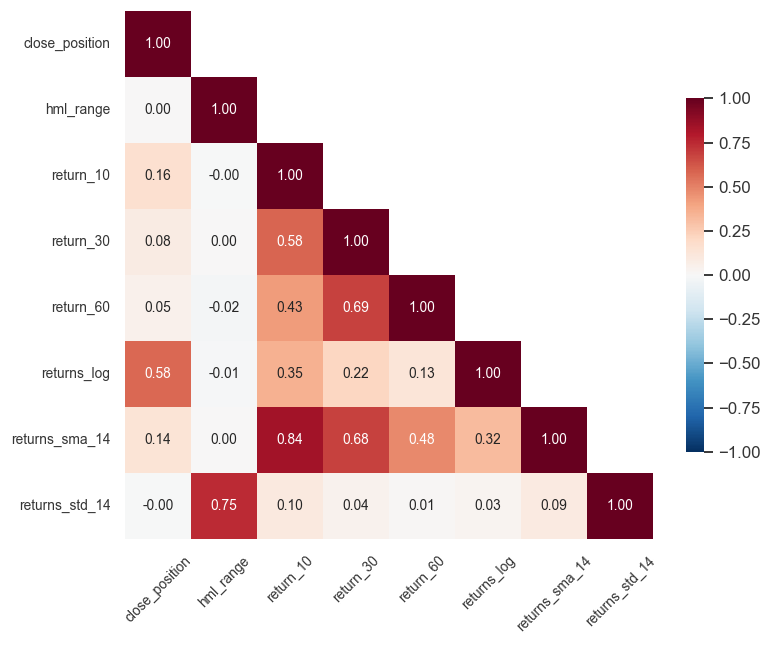




### feat_hml_range


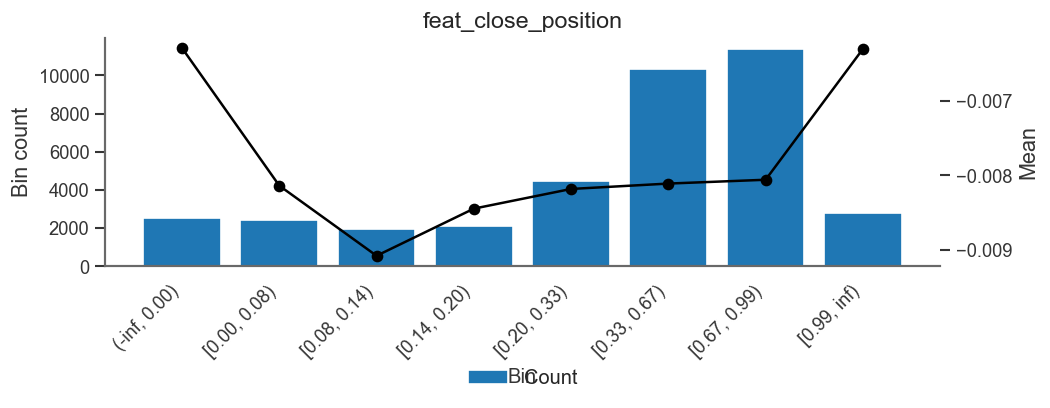




### feat_return_10


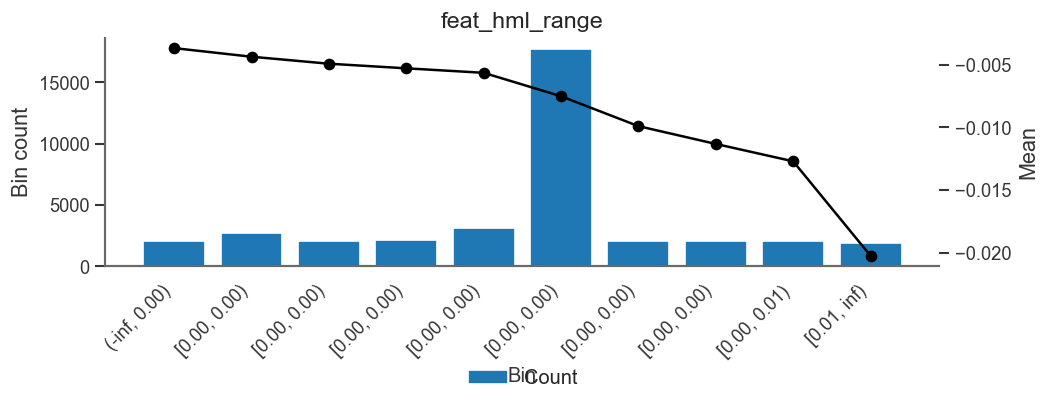




### feat_return_30


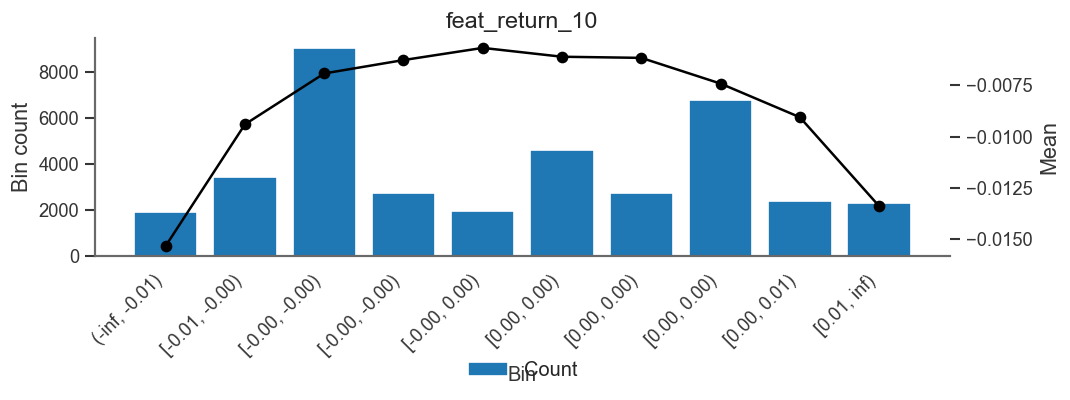




### feat_return_60


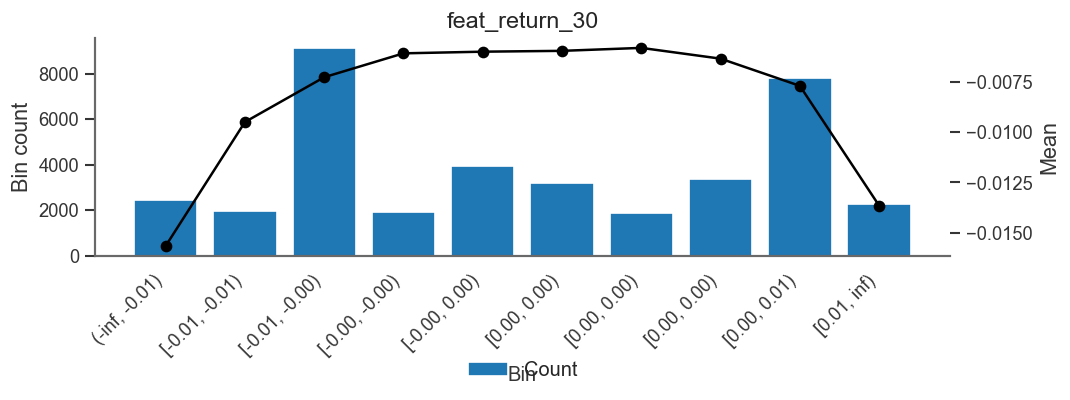




### feat_returns_log


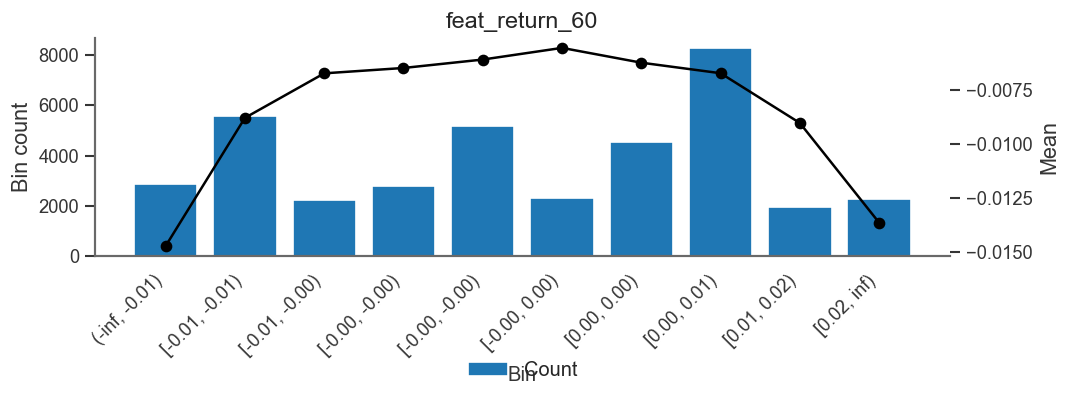




### feat_returns_sma_14


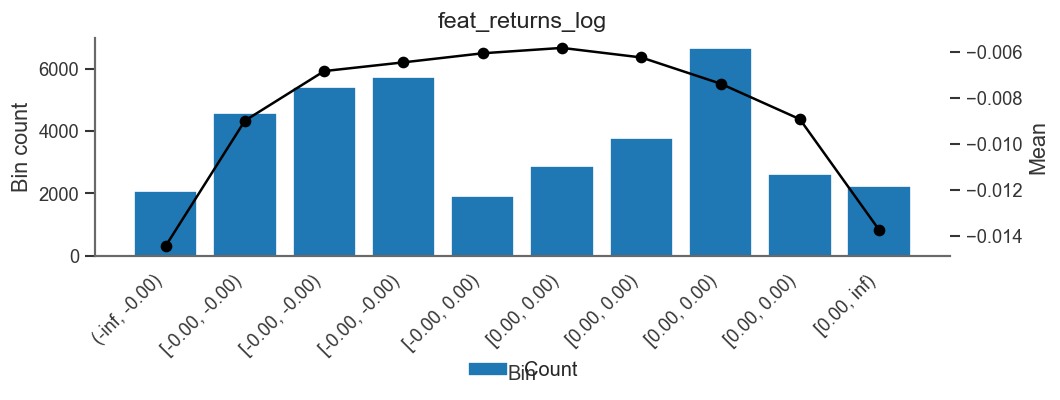




### feat_returns_std_14


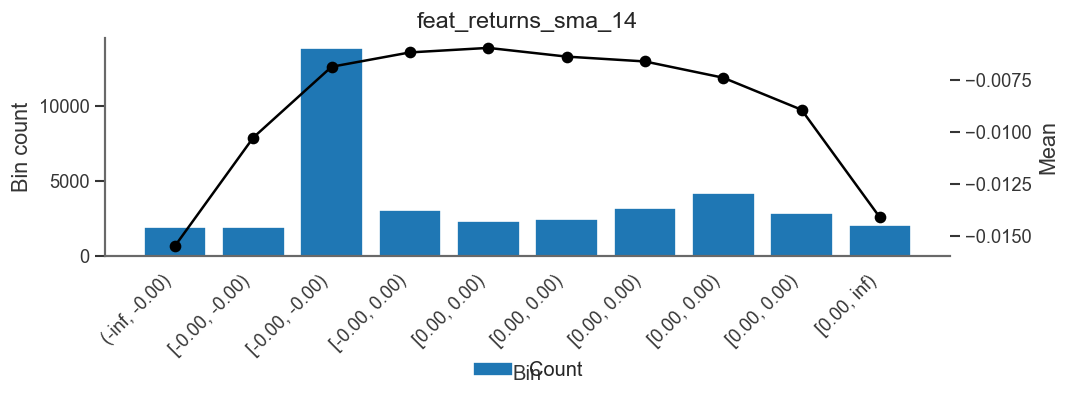



:::


## Volatility

<style type="text/css">
#T_f2ee9  {
  border-collapse: collapse;
  border: 1px solid black;
}
#T_f2ee9 th {
  border: 1px solid black;
  padding: 4px 8px;
  text-align: center;
}
#T_f2ee9 td {
  border: 1px solid black;
  padding: 4px 8px;
}
#T_f2ee9 thead th {
  border-bottom: 2px solid black;
}
#T_f2ee9_row0_col0, #T_f2ee9_row0_col4, #T_f2ee9_row1_col0, #T_f2ee9_row1_col4, #T_f2ee9_row2_col0, #T_f2ee9_row2_col4, #T_f2ee9_row3_col0, #T_f2ee9_row3_col4, #T_f2ee9_row4_col0, #T_f2ee9_row4_col4, #T_f2ee9_row5_col0, #T_f2ee9_row5_col4, #T_f2ee9_row6_col0, #T_f2ee9_row6_col4, #T_f2ee9_row7_col0, #T_f2ee9_row7_col4, #T_f2ee9_row8_col0, #T_f2ee9_row8_col4, #T_f2ee9_row9_col0, #T_f2ee9_row9_col4, #T_f2ee9_row10_col0, #T_f2ee9_row10_col4, #T_f2ee9_row11_col0, #T_f2ee9_row11_col4, #T_f2ee9_row12_col0, #T_f2ee9_row12_col4, #T_f2ee9_row13_col0, #T_f2ee9_row13_col4, #T_f2ee9_row14_col0, #T_f2ee9_row14_col4, #T_f2ee9_row15_col0, #T_f2ee9_row15_col4, #T_f2ee9_row16_col0, #T_f2e
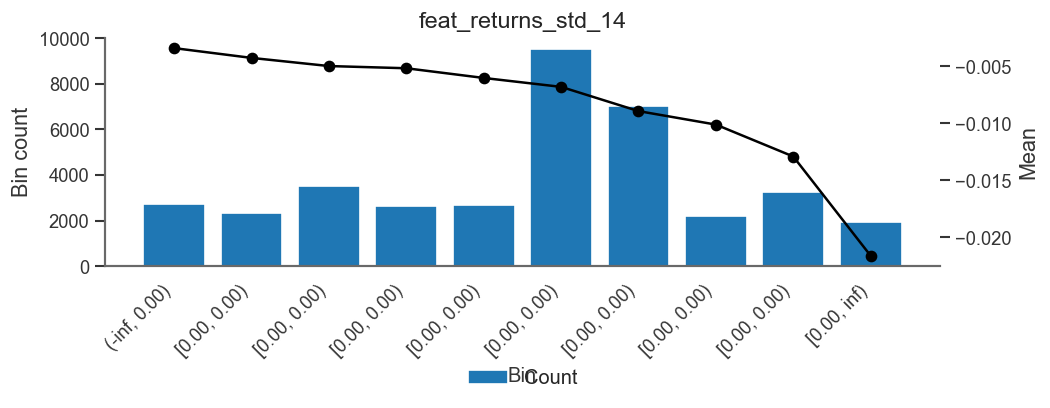



::: {.panel-tabset}


### feat_atr_14


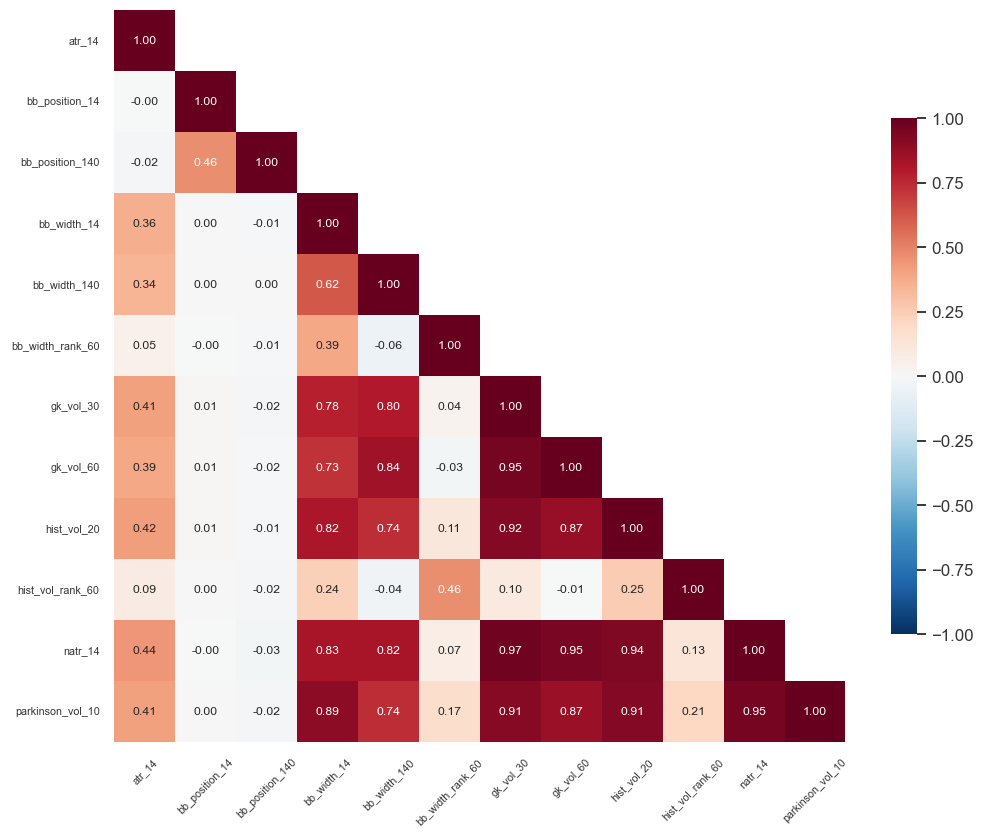




### feat_bb_position_14


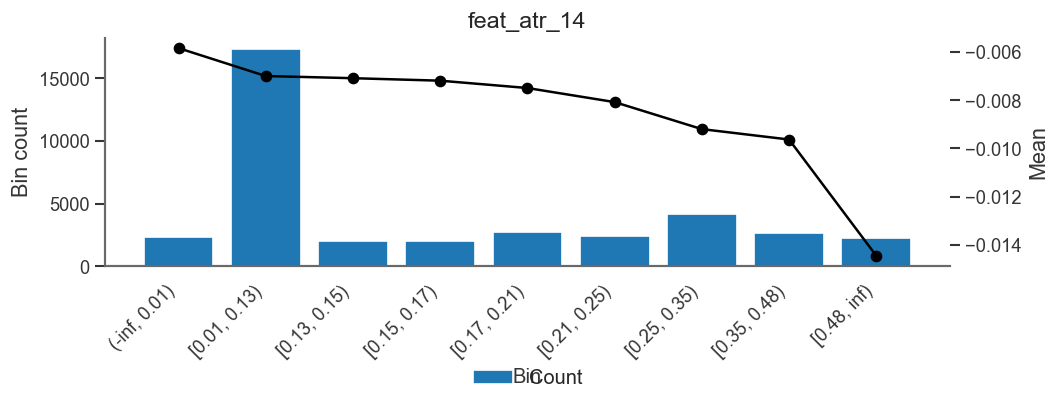




### feat_bb_position_140


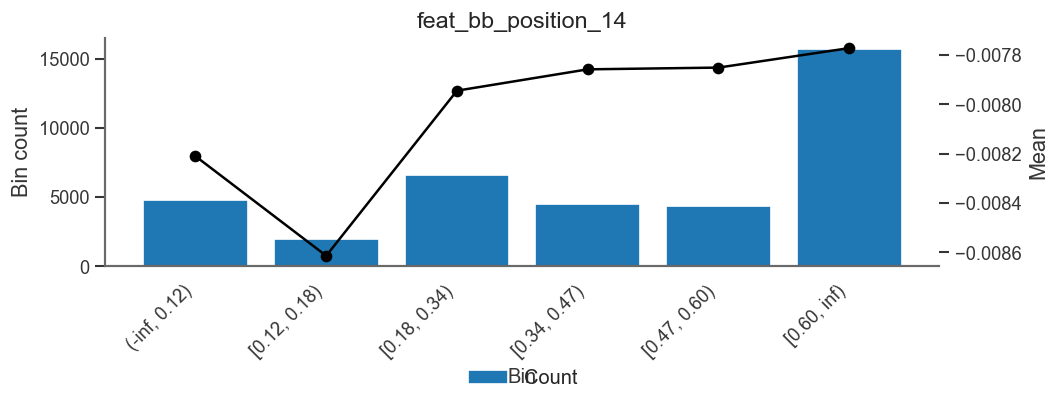




### feat_bb_width_14


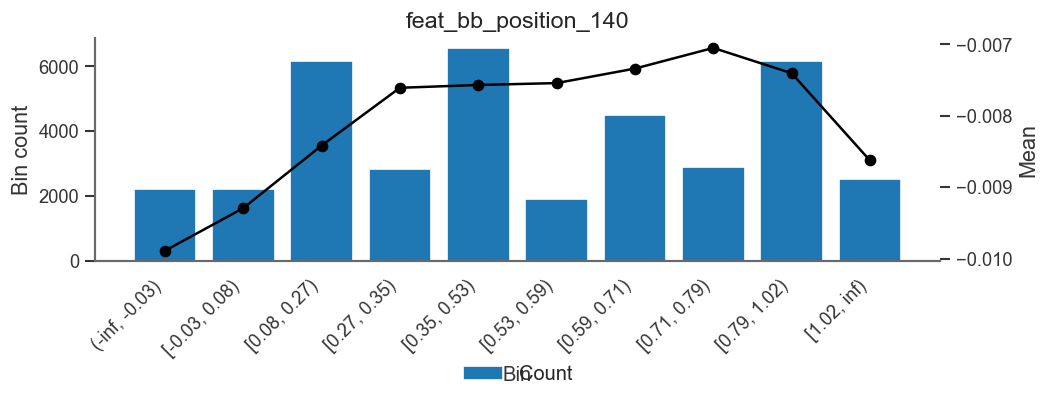




### feat_bb_width_140


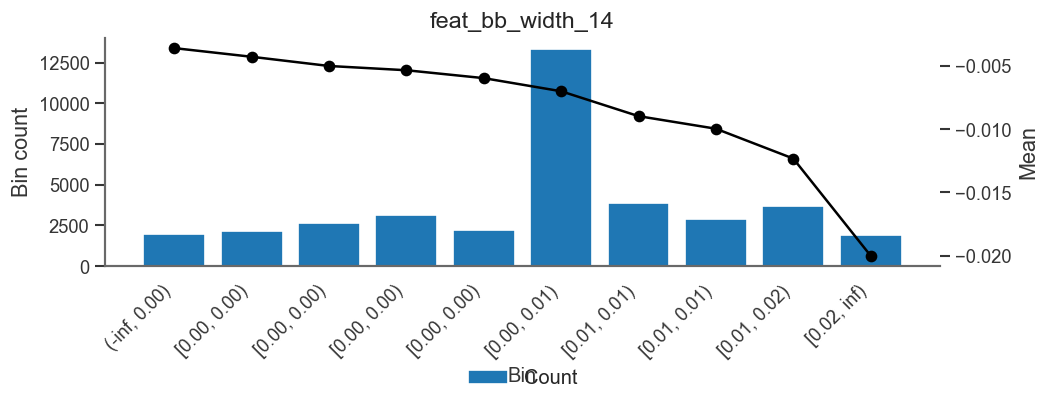




### feat_bb_width_rank_60


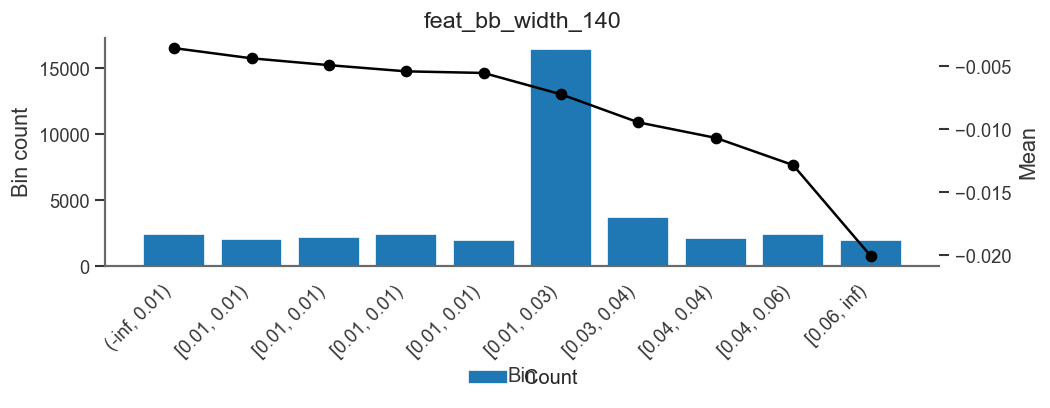




### feat_gk_vol_30


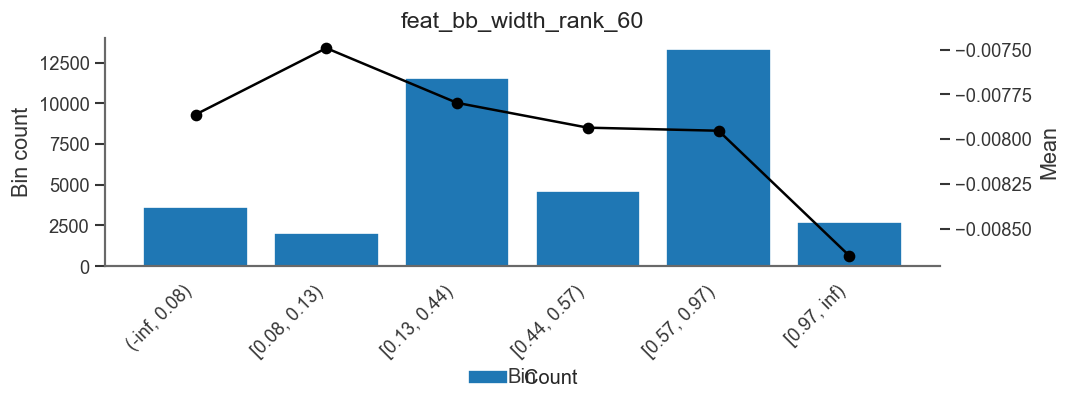




### feat_gk_vol_60


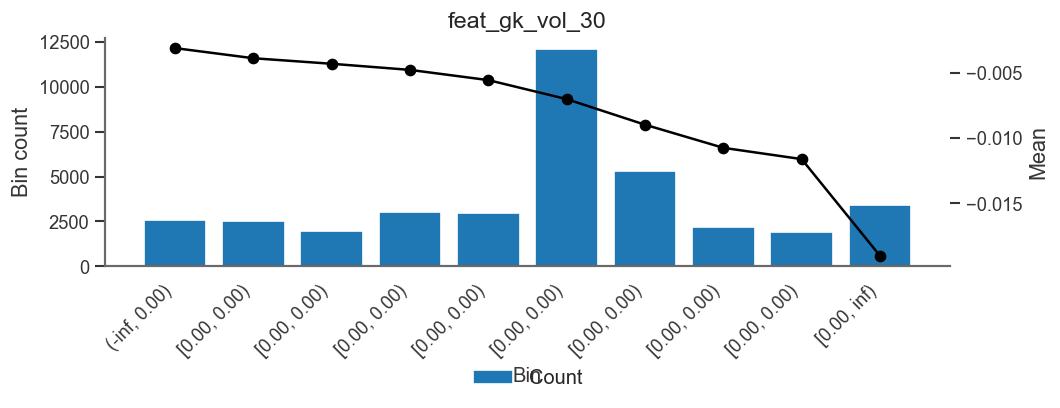




### feat_hist_vol_20


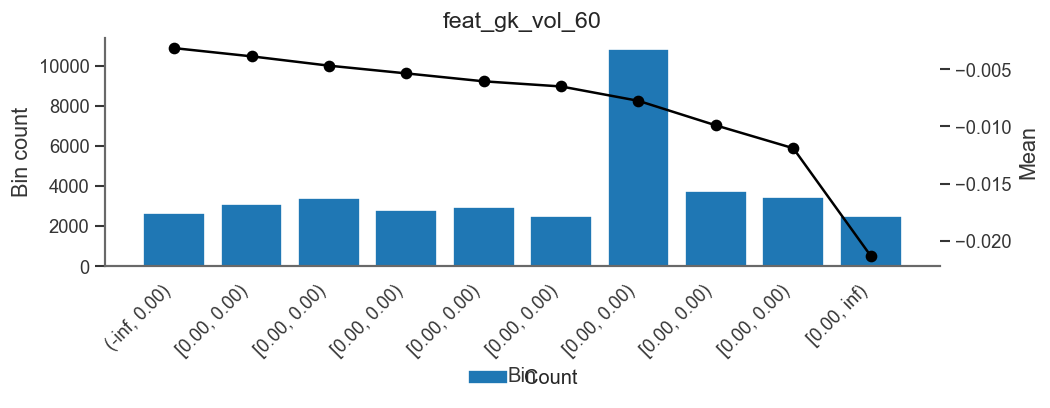




### feat_hist_vol_rank_60


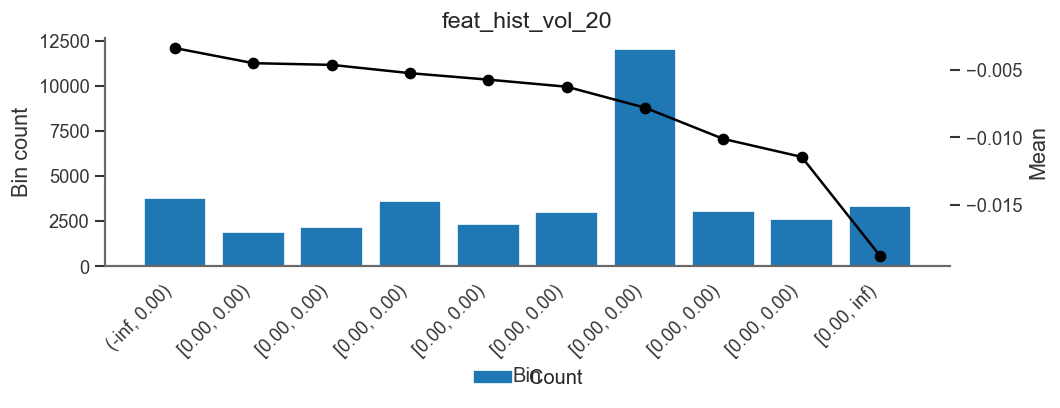




### feat_natr_14


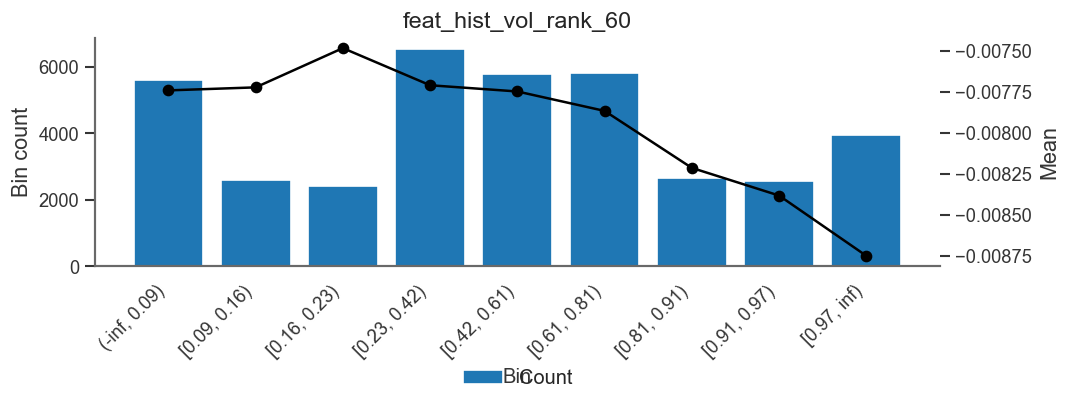




### feat_parkinson_vol_10


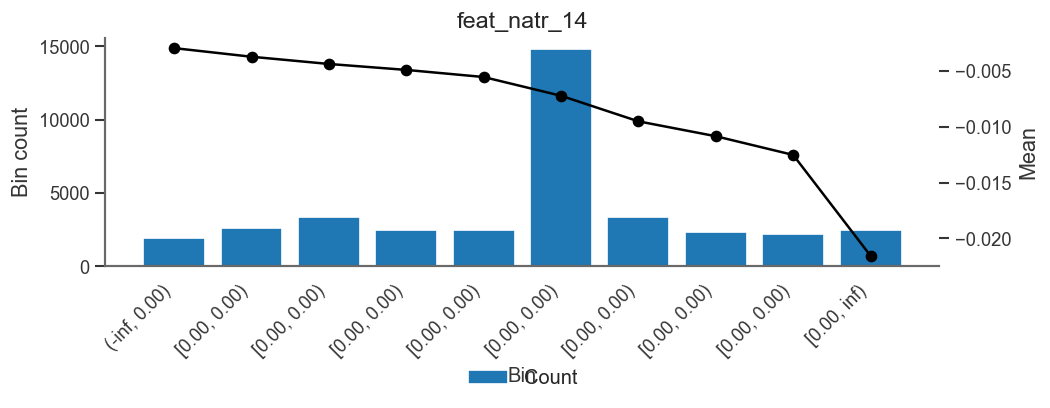



:::


## Volume

<style type="text/css">
#T_99089  {
  border-collapse: collapse;
  border: 1px solid black;
}
#T_99089 th {
  border: 1px solid black;
  padding: 4px 8px;
  text-align: center;
}
#T_99089 td {
  border: 1px solid black;
  padding: 4px 8px;
}
#T_99089 thead th {
  border-bottom: 2px solid black;
}
#T_99089_row0_col0, #T_99089_row0_col4, #T_99089_row1_col0, #T_99089_row1_col4, #T_99089_row2_col0, #T_99089_row2_col4, #T_99089_row3_col0, #T_99089_row3_col4, #T_99089_row4_col0, #T_99089_row4_col4, #T_99089_row5_col0, #T_99089_row5_col4, #T_99089_row6_col0, #T_99089_row6_col4, #T_99089_row7_col0, #T_99089_row7_col4, #T_99089_row8_col0, #T_99089_row8_col4, #T_99089_row9_col0, #T_99089_row9_col4, #T_99089_row10_col0, #T_99089_row10_col4, #T_99089_row11_col0, #T_99089_row11_col4 {
  text-align: left;
}
#T_99089_row0_col1, #T_99089_row0_col2, #T_99089_row0_col3, #T_99089_row1_col1, #T_99089_row1_col2, #T_99089_row1_col3, #T_99089_row2_col1, #T_99089_row2_col2, #T_99089_row2_co
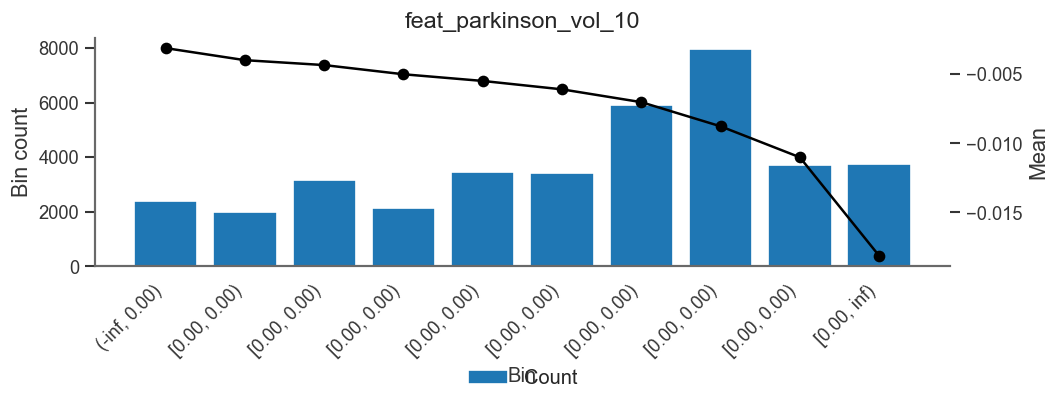



::: {.panel-tabset}


### feat_ad_line


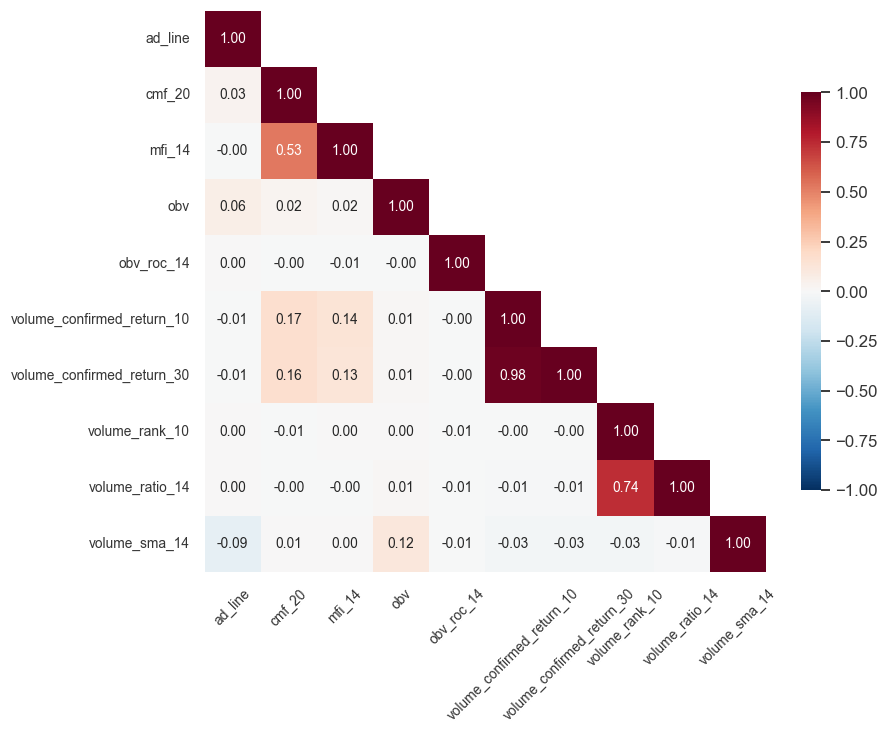




### feat_cmf_20


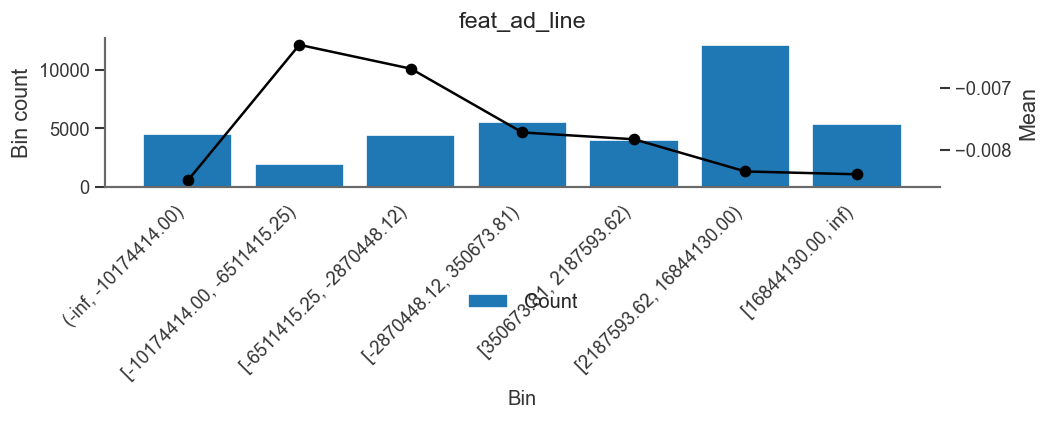




### feat_mfi_14


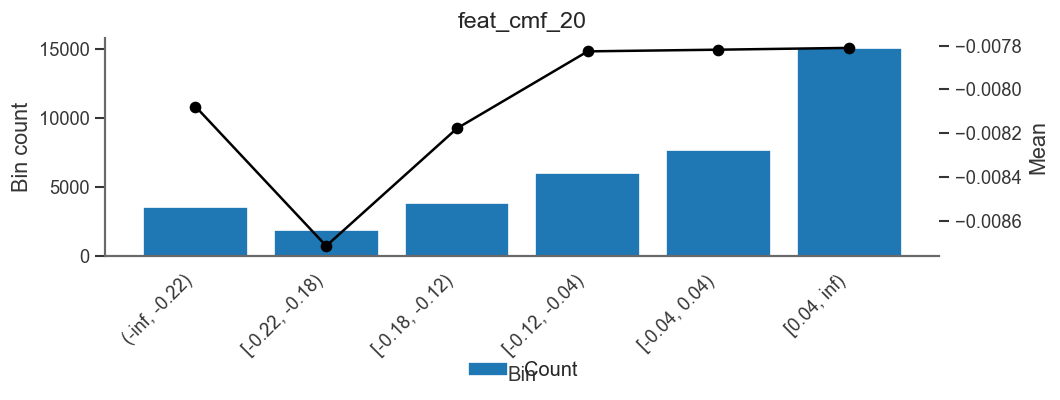




### feat_obv


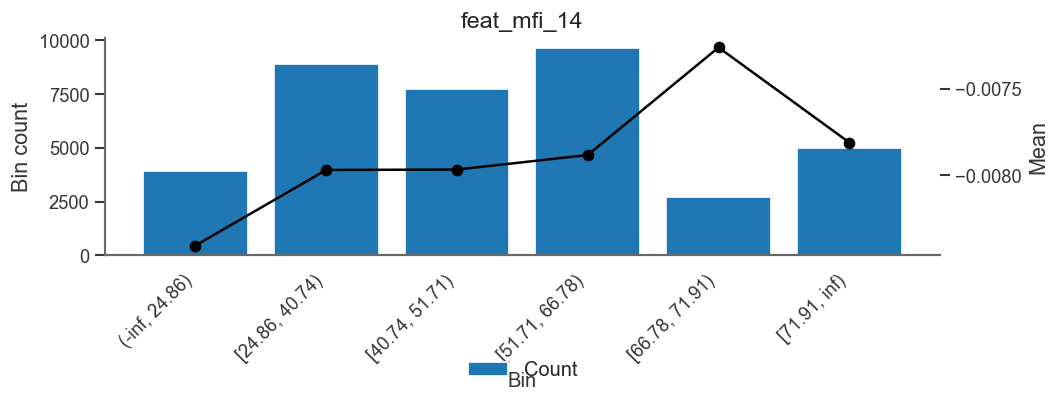




### feat_obv_roc_14


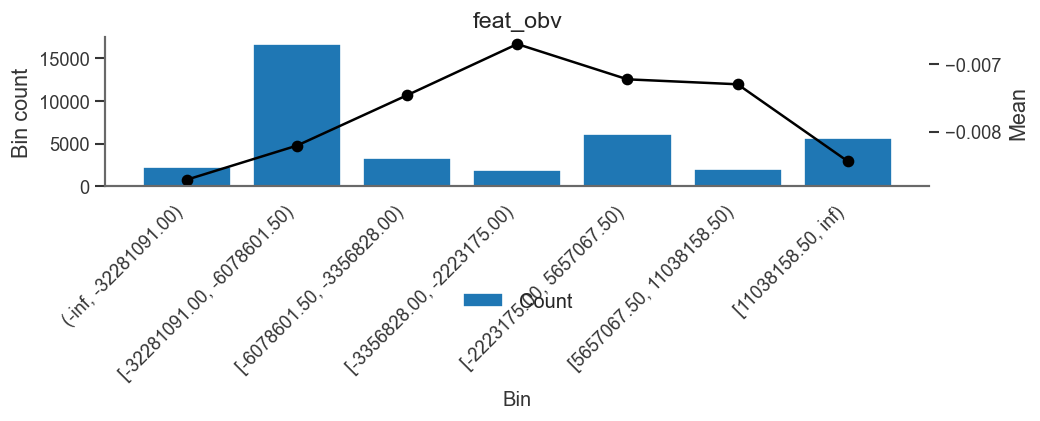




### feat_volume_confirmed_return_10


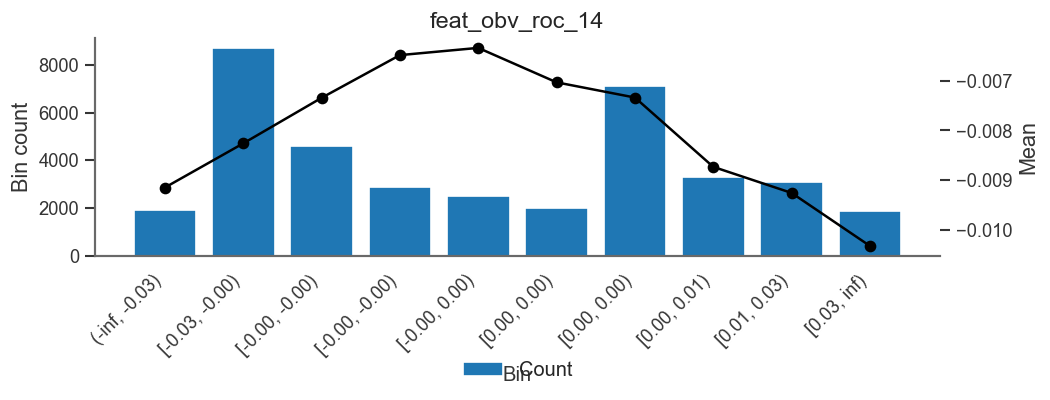




### feat_volume_confirmed_return_30


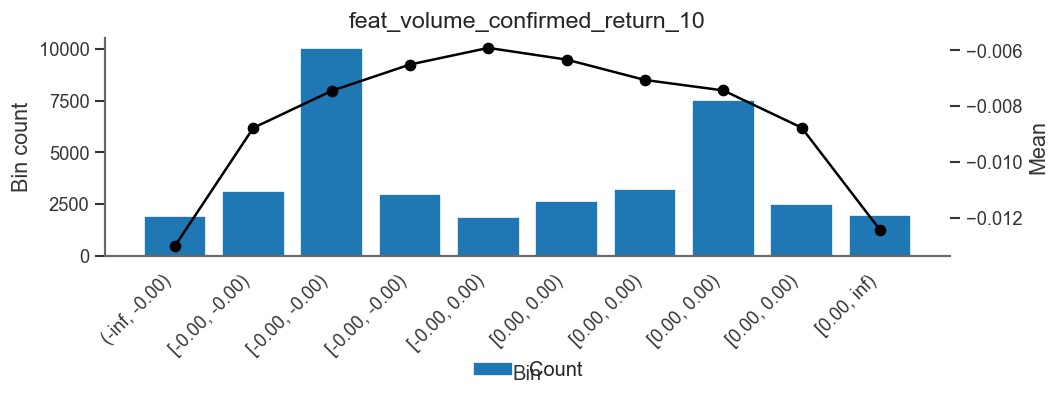




### feat_volume_rank_10


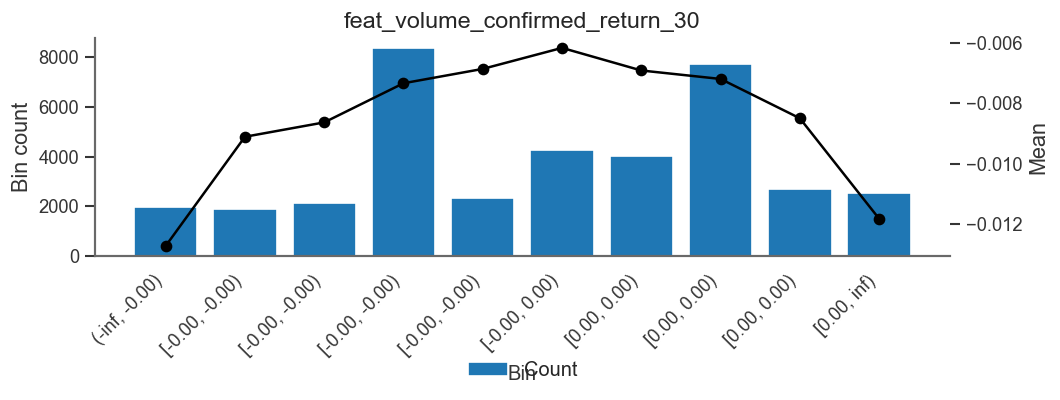




### feat_volume_ratio_14


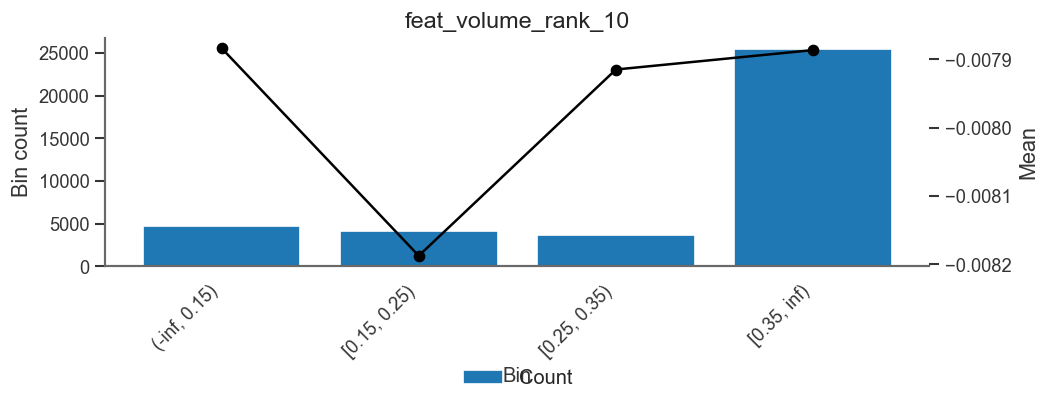




### feat_volume_sma_14


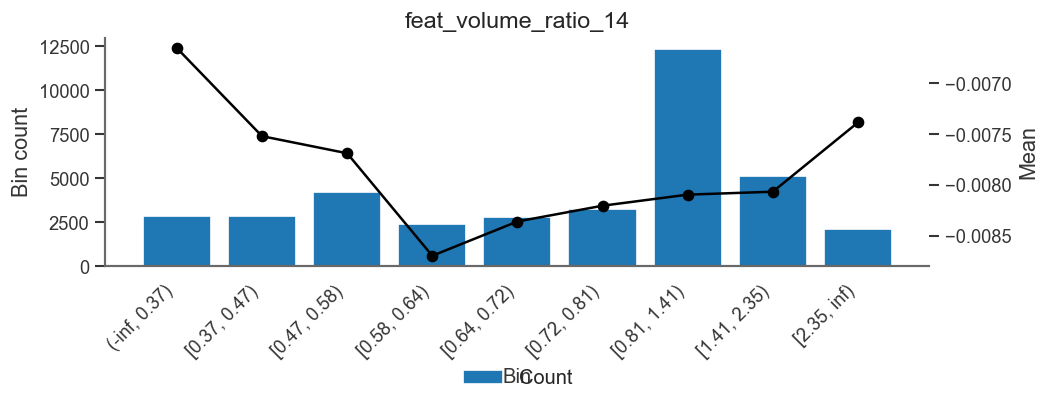



:::


## Gap

<style type="text/css">
#T_16af4  {
  border-collapse: collapse;
  border: 1px solid black;
}
#T_16af4 th {
  border: 1px solid black;
  padding: 4px 8px;
  text-align: center;
}
#T_16af4 td {
  border: 1px solid black;
  padding: 4px 8px;
}
#T_16af4 thead th {
  border-bottom: 2px solid black;
}
#T_16af4_row0_col0, #T_16af4_row0_col4, #T_16af4_row1_col0, #T_16af4_row1_col4, #T_16af4_row2_col0, #T_16af4_row2_col4 {
  text-align: left;
}
#T_16af4_row0_col1, #T_16af4_row0_col2, #T_16af4_row0_col3, #T_16af4_row1_col1, #T_16af4_row1_col2, #T_16af4_row1_col3, #T_16af4_row2_col1, #T_16af4_row2_col2, #T_16af4_row2_col3 {
  text-align: right;
}
</style>
<table id="T_16af4">
  <thead>
    <tr>
      <th id="T_16af4_level0_col0" class="col_heading level0 col0" >Feature</th>
      <th id="T_16af4_level0_col1" class="col_heading level0 col1" >IV</th>
      <th id="T_16af4_level0_col2" class="col_heading level0 col2" >MI</th>
      <th id="T_16af4_level0_col3" class="col_heading lev
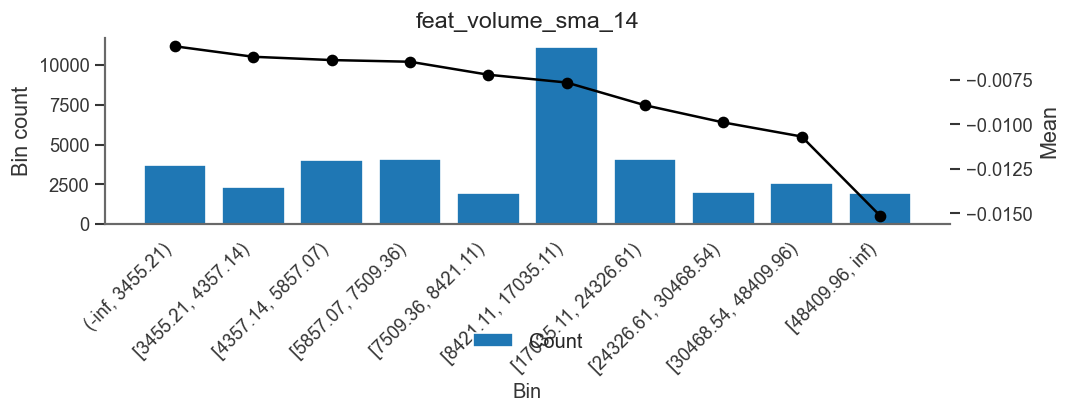



:::


## Candle Pattern

<style type="text/css">
#T_683fc  {
  border-collapse: collapse;
  border: 1px solid black;
}
#T_683fc th {
  border: 1px solid black;
  padding: 4px 8px;
  text-align: center;
}
#T_683fc td {
  border: 1px solid black;
  padding: 4px 8px;
}
#T_683fc thead th {
  border-bottom: 2px solid black;
}
#T_683fc_row0_col0, #T_683fc_row0_col4, #T_683fc_row1_col0, #T_683fc_row1_col4, #T_683fc_row2_col0, #T_683fc_row2_col4, #T_683fc_row3_col0, #T_683fc_row3_col4, #T_683fc_row4_col0, #T_683fc_row4_col4, #T_683fc_row5_col0, #T_683fc_row5_col4, #T_683fc_row6_col0, #T_683fc_row6_col4, #T_683fc_row7_col0, #T_683fc_row7_col4, #T_683fc_row8_col0, #T_683fc_row8_col4, #T_683fc_row9_col0, #T_683fc_row9_col4, #T_683fc_row10_col0, #T_683fc_row10_col4, #T_683fc_row11_col0, #T_683fc_row11_col4, #T_683fc_row12_col0, #T_683fc_row12_col4, #T_683fc_row13_col0, #T_683fc_row13_col4, #T_683fc_row14_col0, #T_683fc_row14_col4, #T_683fc_row15_col0, #T_683fc_row15_col4, #T_683fc_row16_col0, #T
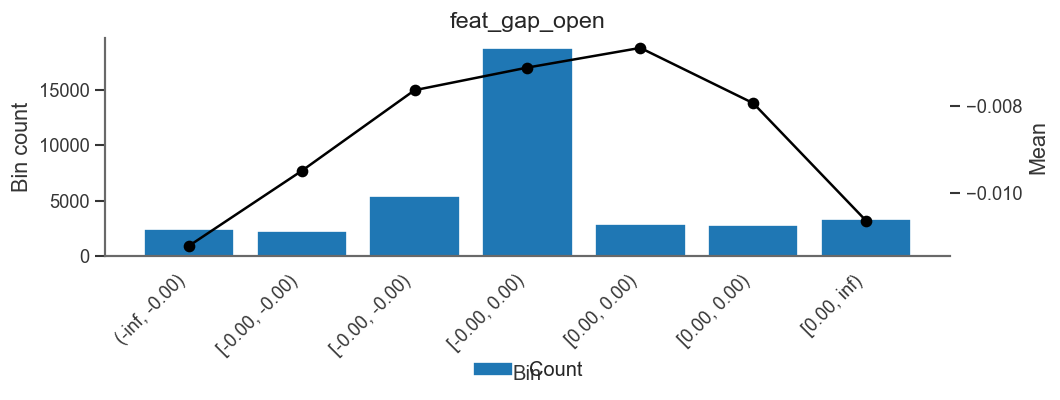



::: {.panel-tabset}


### feat_body_ratio


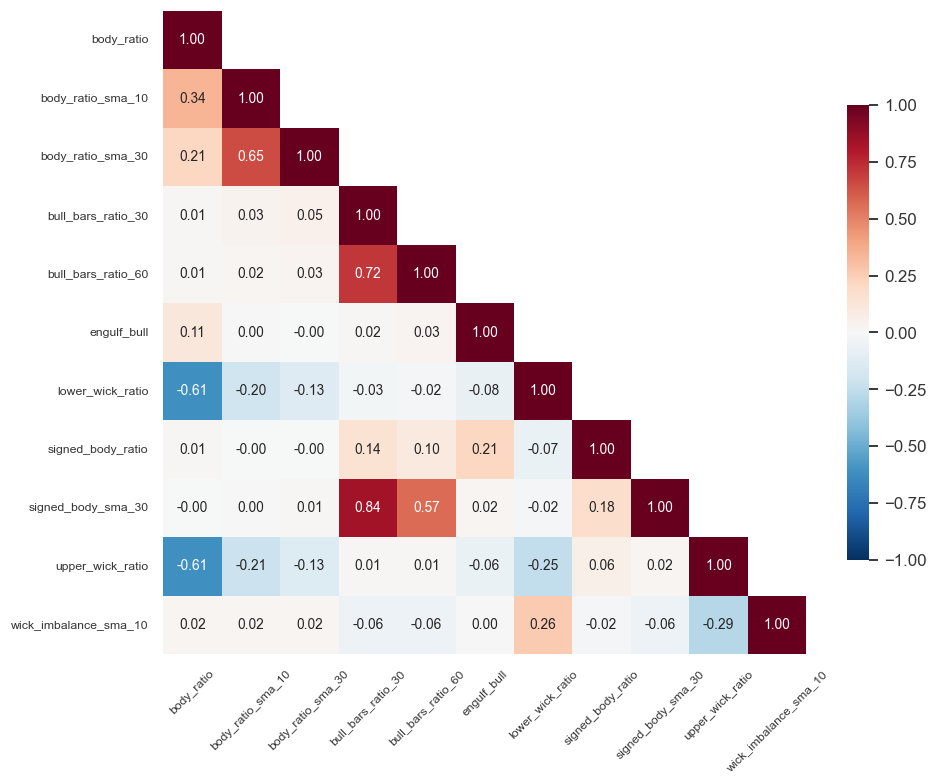




### feat_body_ratio_sma_10


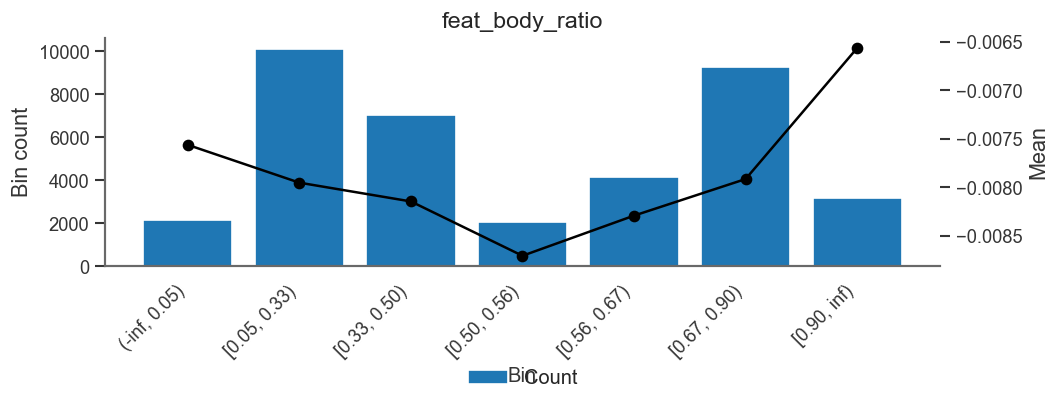




### feat_body_ratio_sma_30


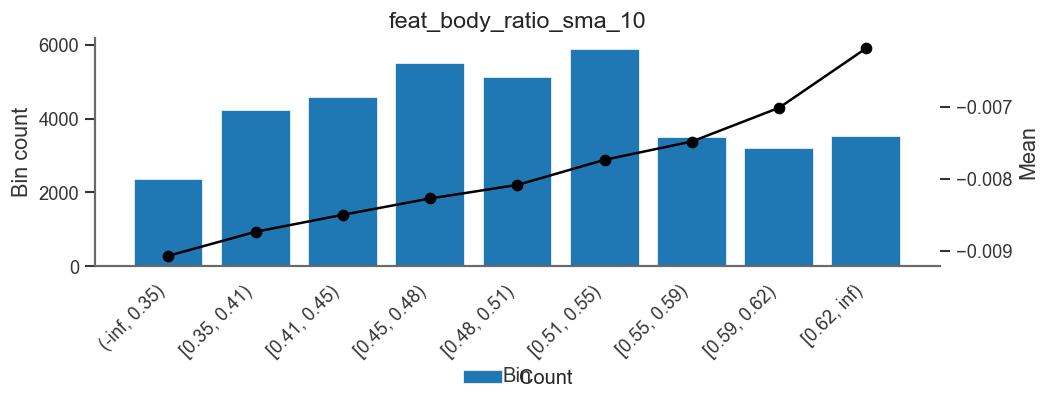




### feat_bull_bars_ratio_30


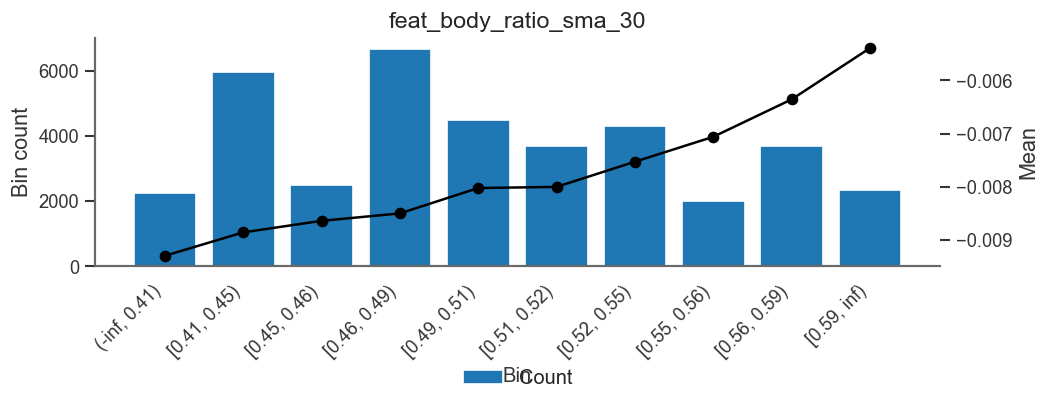




### feat_bull_bars_ratio_60


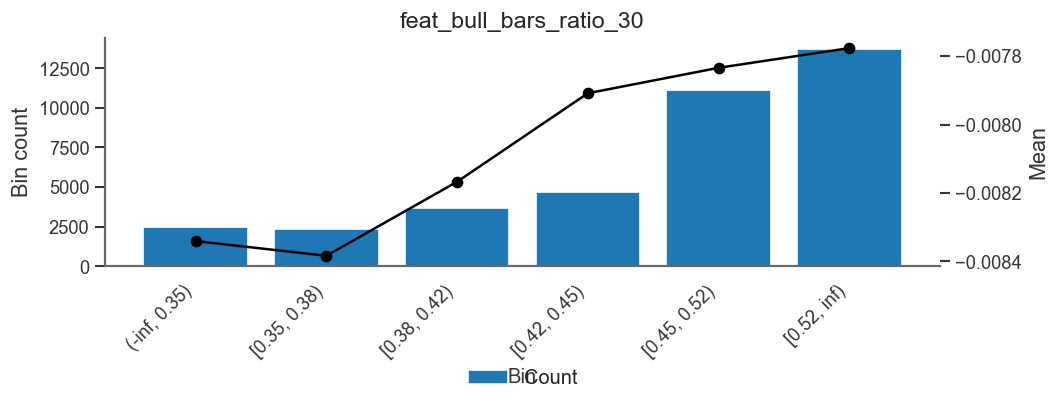




### feat_engulf_bull


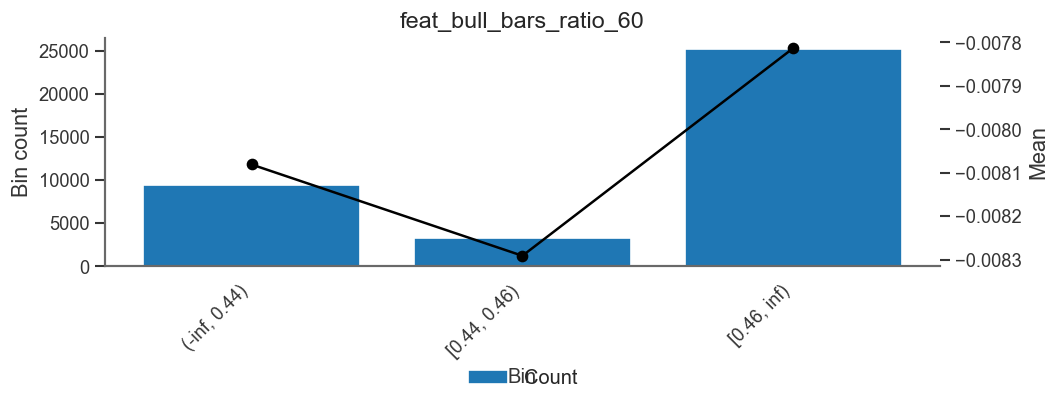




### feat_lower_wick_ratio


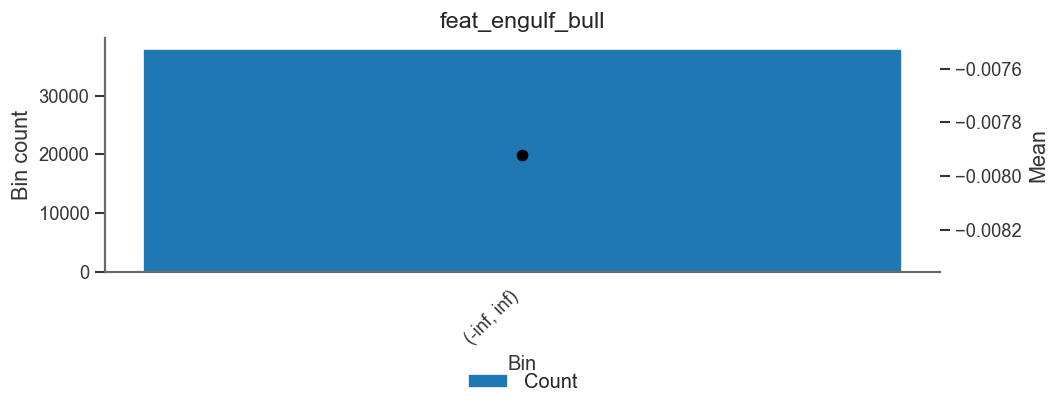




### feat_signed_body_ratio


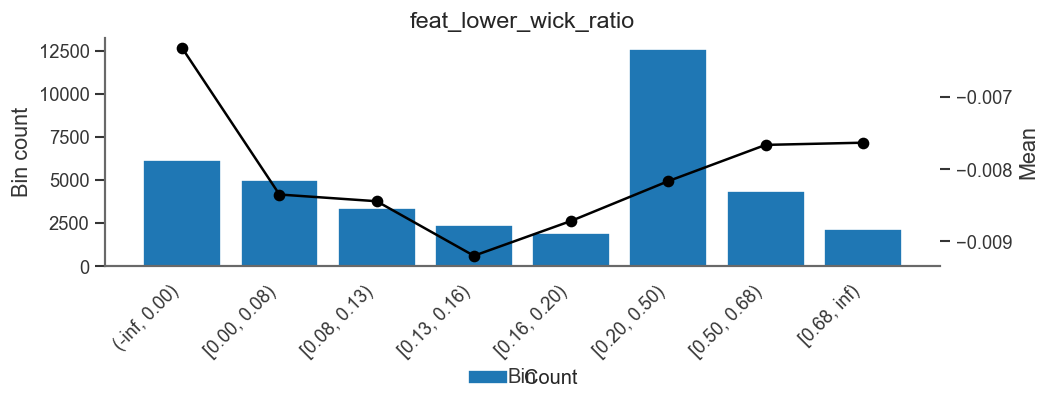




### feat_signed_body_sma_30


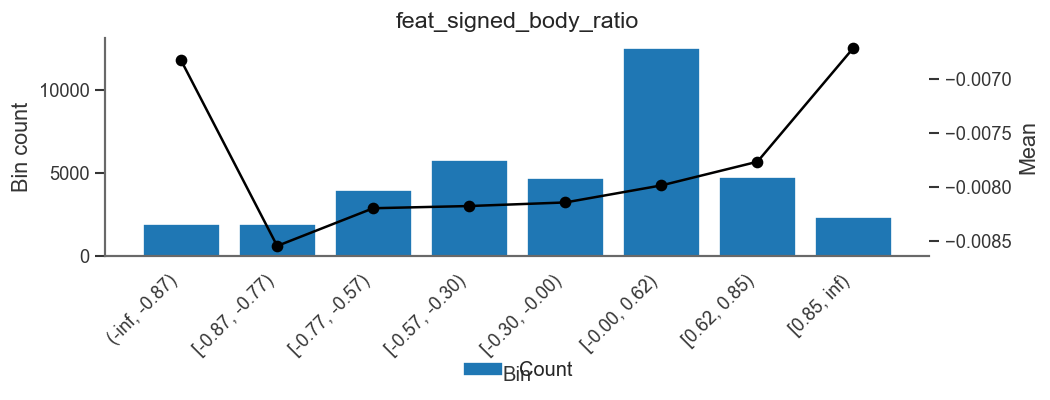




### feat_upper_wick_ratio


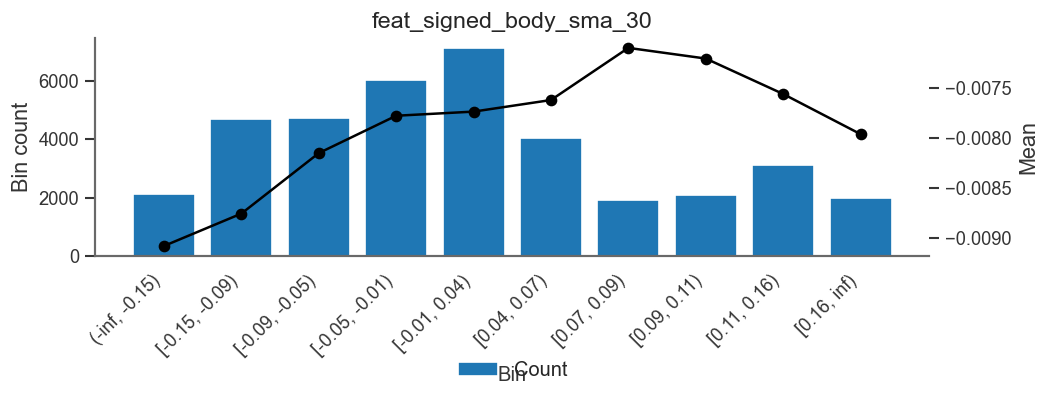




### feat_wick_imbalance_sma_10


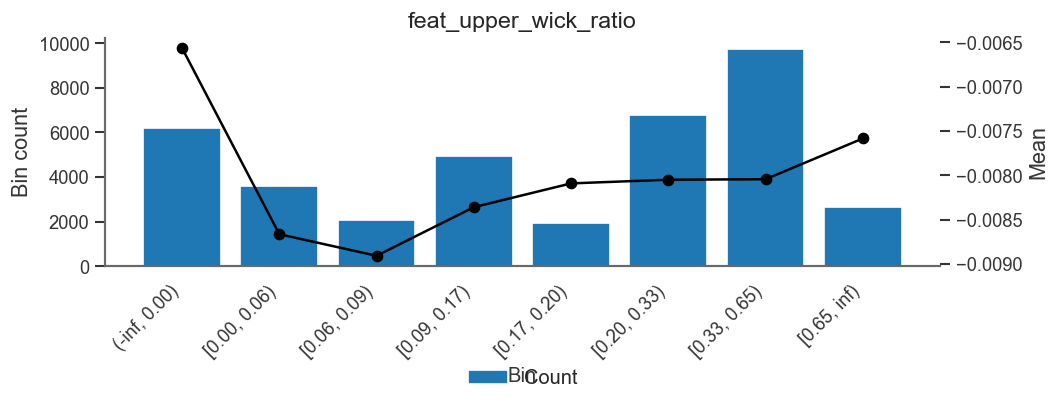



:::


## Time/Session

<style type="text/css">
#T_d2bc2  {
  border-collapse: collapse;
  border: 1px solid black;
}
#T_d2bc2 th {
  border: 1px solid black;
  padding: 4px 8px;
  text-align: center;
}
#T_d2bc2 td {
  border: 1px solid black;
  padding: 4px 8px;
}
#T_d2bc2 thead th {
  border-bottom: 2px solid black;
}
#T_d2bc2_row0_col0, #T_d2bc2_row0_col4, #T_d2bc2_row1_col0, #T_d2bc2_row1_col4, #T_d2bc2_row2_col0, #T_d2bc2_row2_col4, #T_d2bc2_row3_col0, #T_d2bc2_row3_col4, #T_d2bc2_row4_col0, #T_d2bc2_row4_col4, #T_d2bc2_row5_col0, #T_d2bc2_row5_col4, #T_d2bc2_row6_col0, #T_d2bc2_row6_col4, #T_d2bc2_row7_col0, #T_d2bc2_row7_col4, #T_d2bc2_row8_col0, #T_d2bc2_row8_col4, #T_d2bc2_row9_col0, #T_d2bc2_row9_col4, #T_d2bc2_row10_col0, #T_d2bc2_row10_col4, #T_d2bc2_row11_col0, #T_d2bc2_row11_col4 {
  text-align: left;
}
#T_d2bc2_row0_col1, #T_d2bc2_row0_col2, #T_d2bc2_row0_col3, #T_d2bc2_row1_col1, #T_d2bc2_row1_col2, #T_d2bc2_row1_col3, #T_d2bc2_row2_col1, #T_d2bc2_row2_col2, #T_d2bc2_r
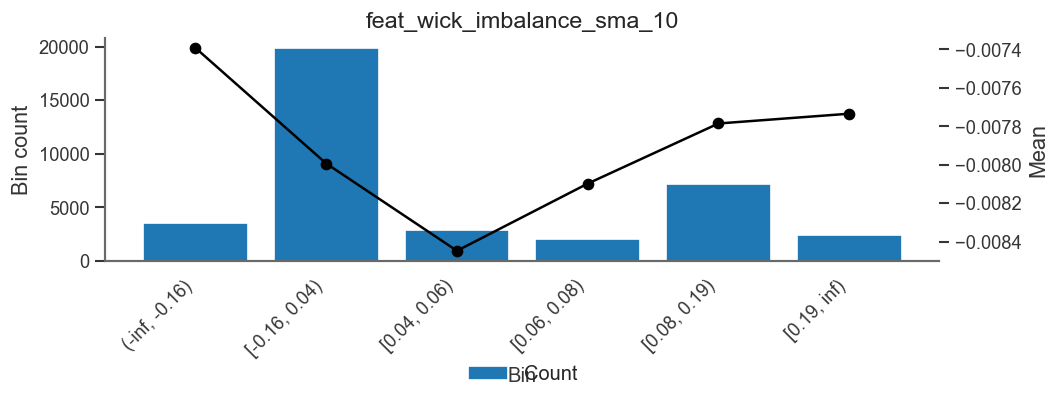



::: {.panel-tabset}


### feat_bars_into_session_norm


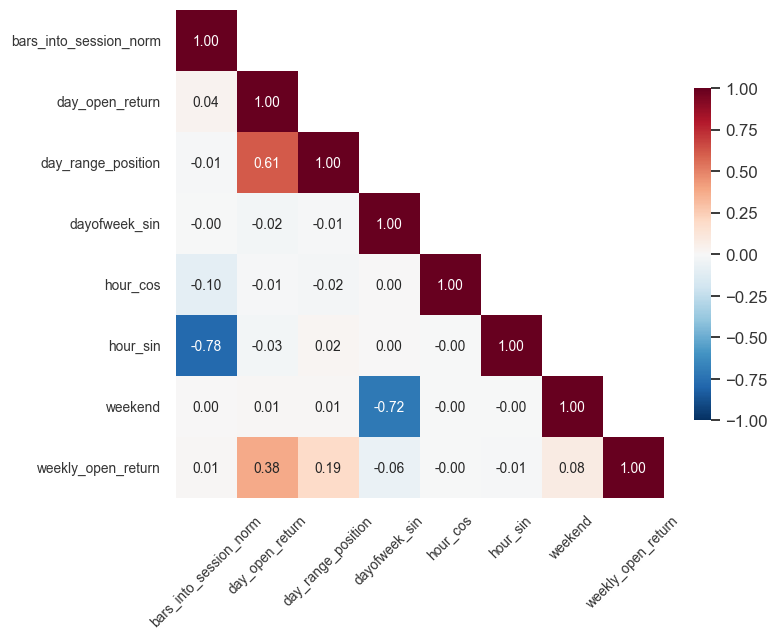




### feat_day_open_return


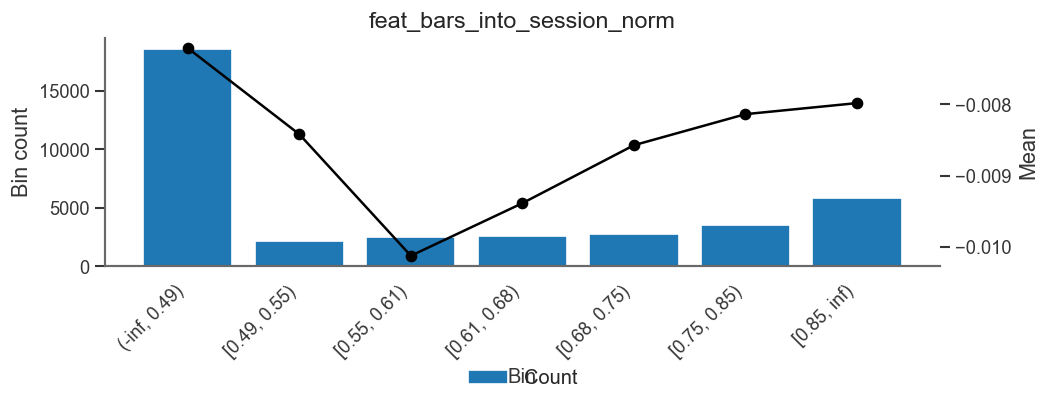




### feat_day_range_position


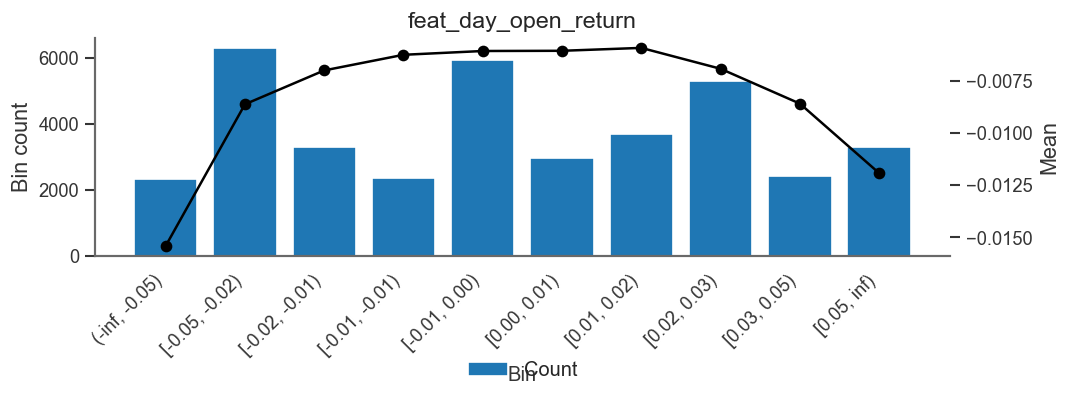




### feat_dayofweek_sin


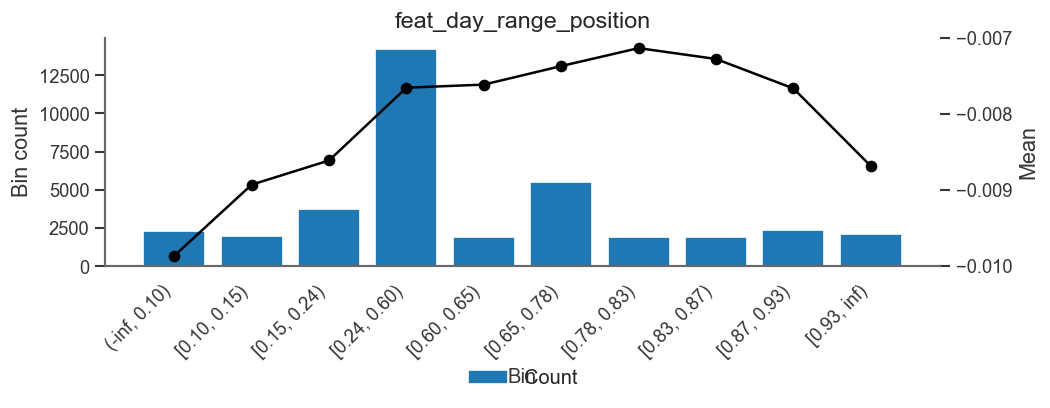




### feat_hour_cos


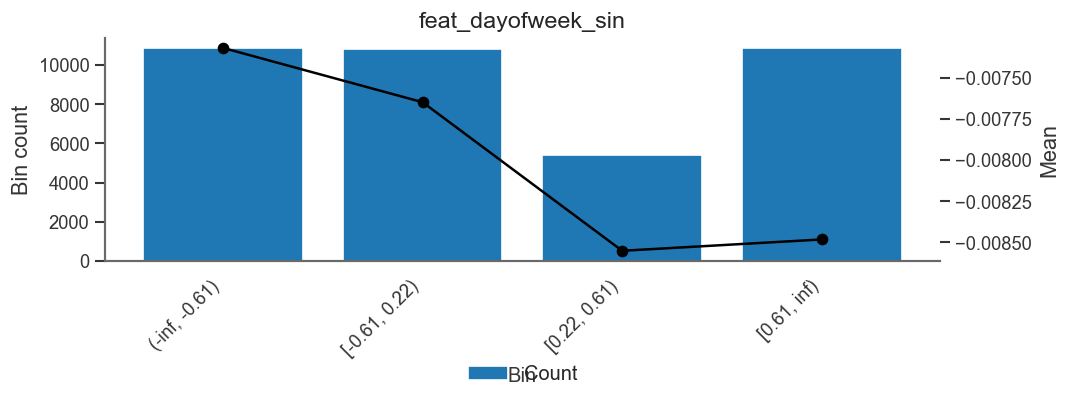




### feat_hour_sin


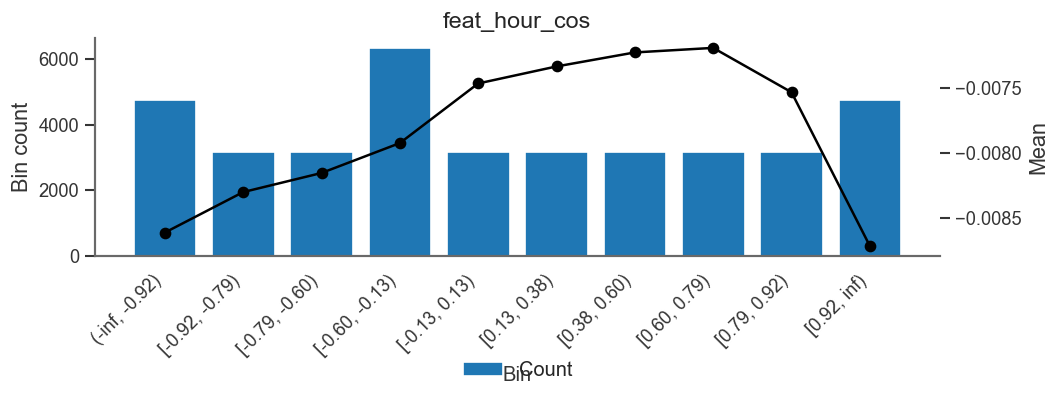




### feat_weekend


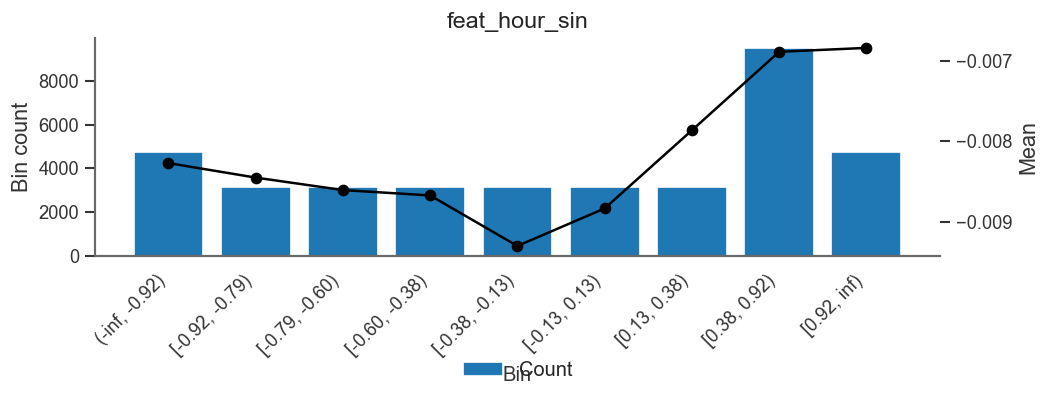




### feat_weekly_open_return


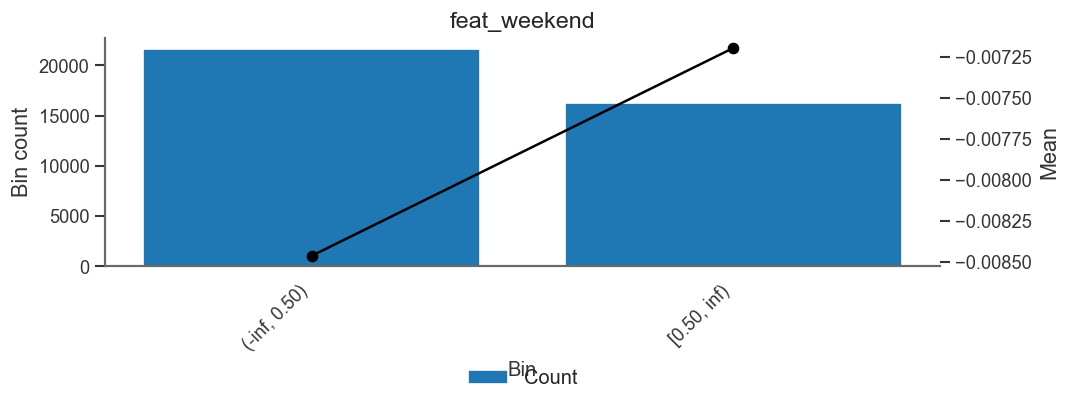



:::


## Taker Flow

<style type="text/css">
#T_a6793  {
  border-collapse: collapse;
  border: 1px solid black;
}
#T_a6793 th {
  border: 1px solid black;
  padding: 4px 8px;
  text-align: center;
}
#T_a6793 td {
  border: 1px solid black;
  padding: 4px 8px;
}
#T_a6793 thead th {
  border-bottom: 2px solid black;
}
#T_a6793_row0_col0, #T_a6793_row0_col4, #T_a6793_row1_col0, #T_a6793_row1_col4, #T_a6793_row2_col0, #T_a6793_row2_col4, #T_a6793_row3_col0, #T_a6793_row3_col4, #T_a6793_row4_col0, #T_a6793_row4_col4, #T_a6793_row5_col0, #T_a6793_row5_col4, #T_a6793_row6_col0, #T_a6793_row6_col4, #T_a6793_row7_col0, #T_a6793_row7_col4, #T_a6793_row8_col0, #T_a6793_row8_col4, #T_a6793_row9_col0, #T_a6793_row9_col4, #T_a6793_row10_col0, #T_a6793_row10_col4, #T_a6793_row11_col0, #T_a6793_row11_col4, #T_a6793_row12_col0, #T_a6793_row12_col4, #T_a6793_row13_col0, #T_a6793_row13_col4, #T_a6793_row14_col0, #T_a6793_row14_col4, #T_a6793_row15_col0, #T_a6793_row15_col4, #T_a6793_row16_col0, #T_a67
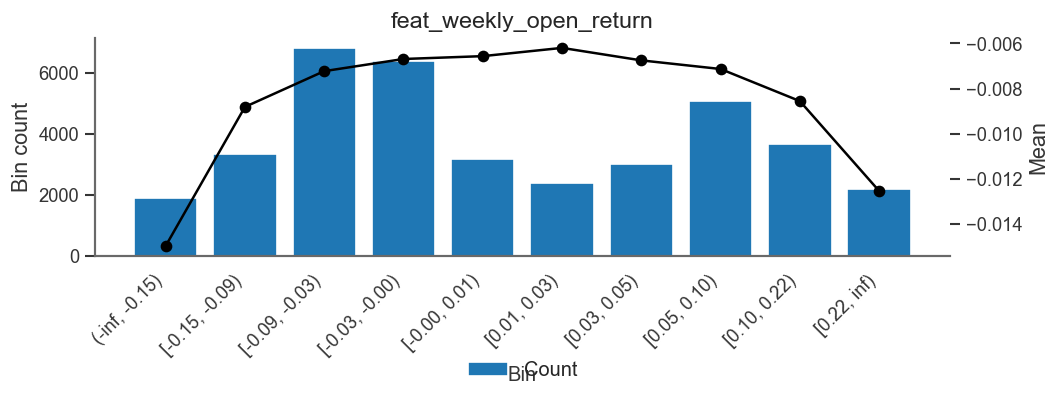



::: {.panel-tabset}


### feat_avg_trade_quote_30


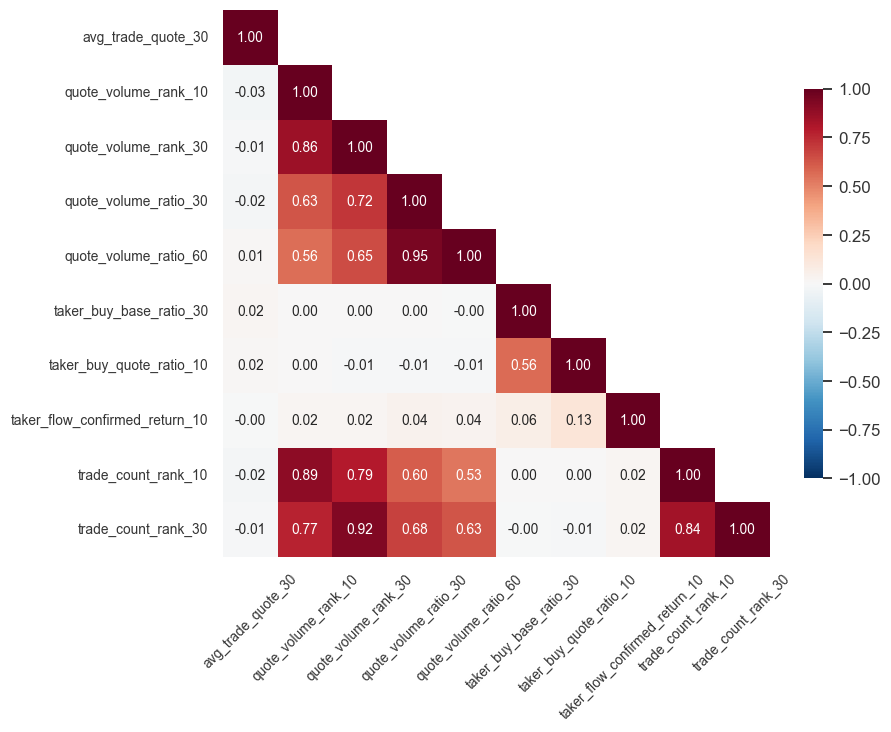




### feat_quote_volume_rank_10


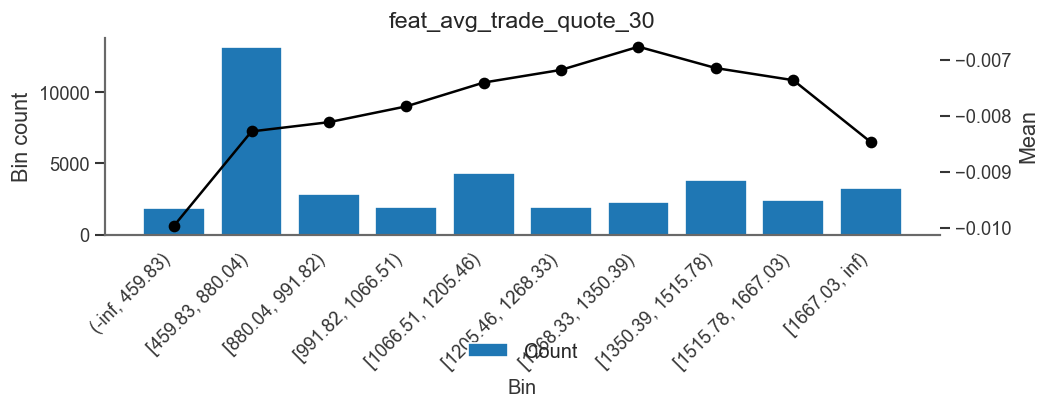




### feat_quote_volume_rank_30


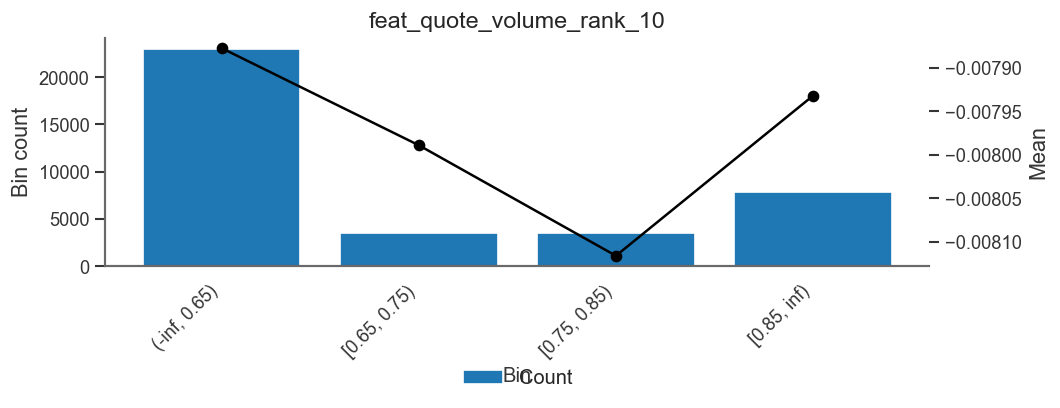




### feat_quote_volume_ratio_30


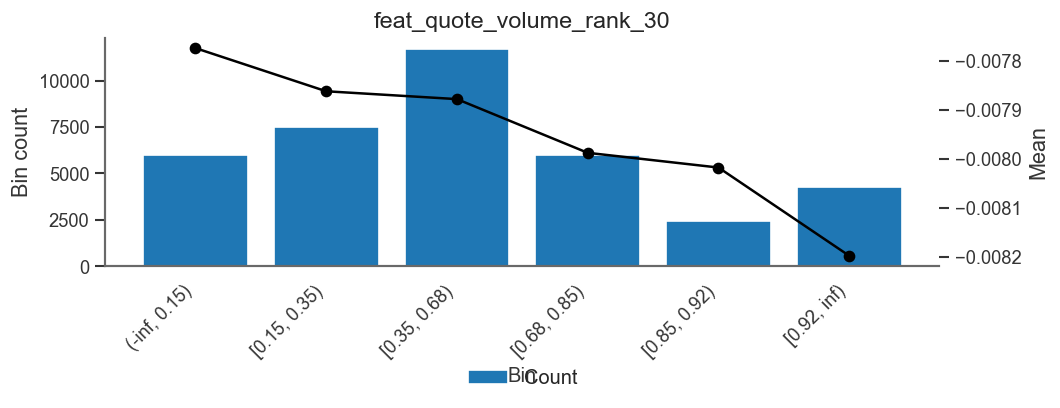




### feat_quote_volume_ratio_60


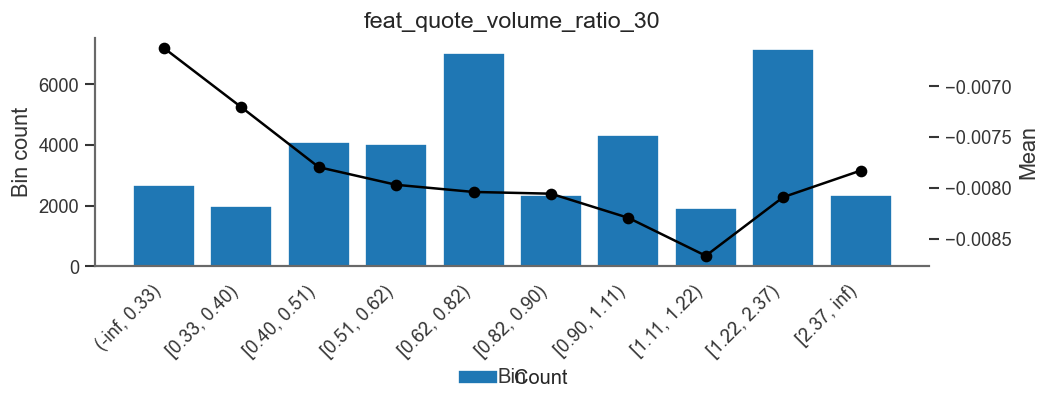




### feat_taker_buy_base_ratio_30


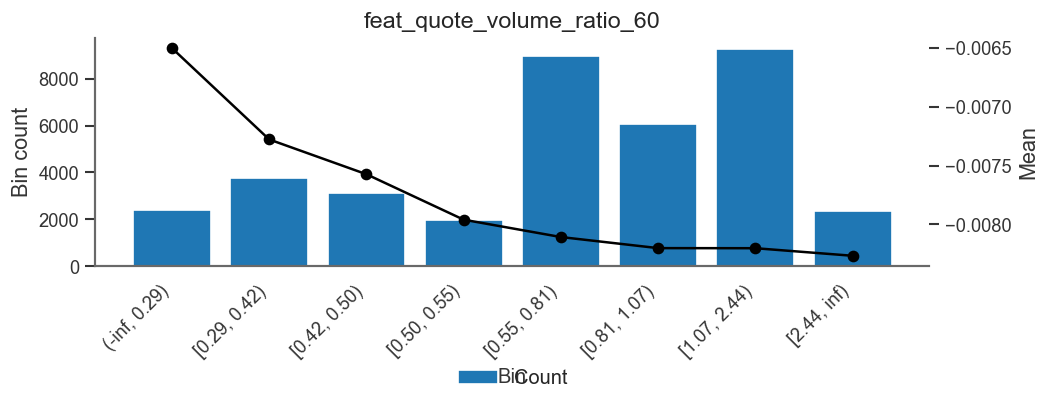




### feat_taker_buy_quote_ratio_10


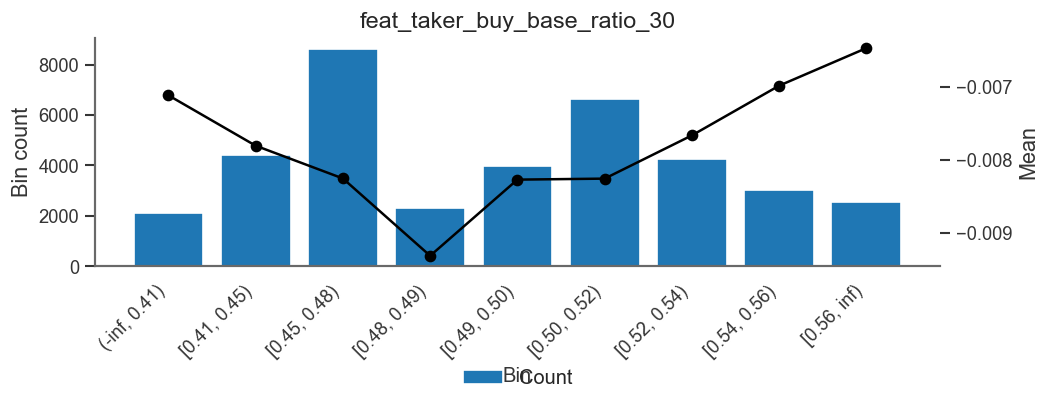




### feat_taker_flow_confirmed_return_10


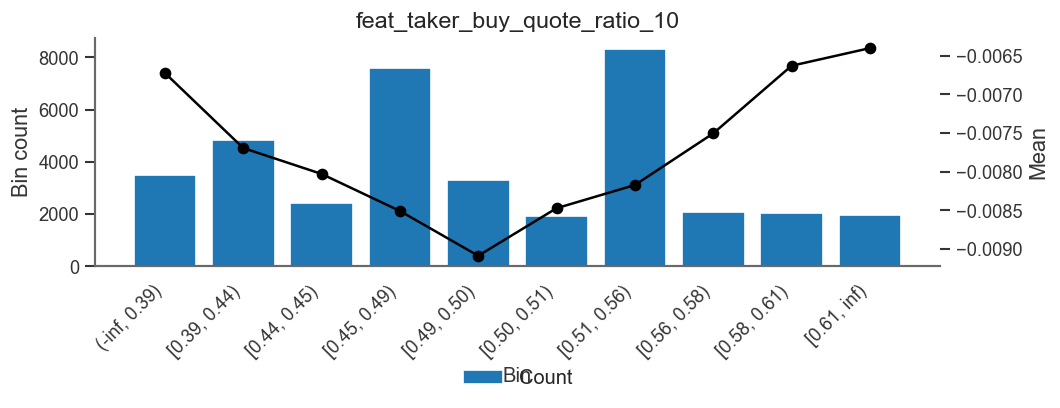




### feat_trade_count_rank_10


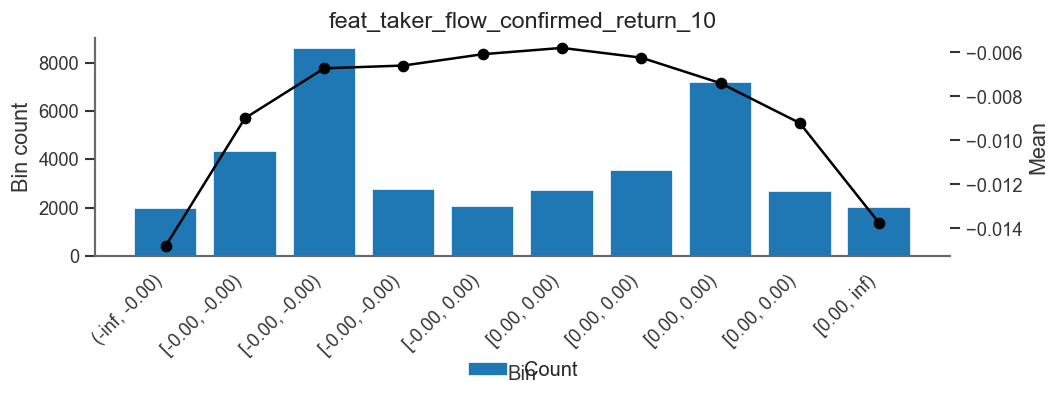




### feat_trade_count_rank_30


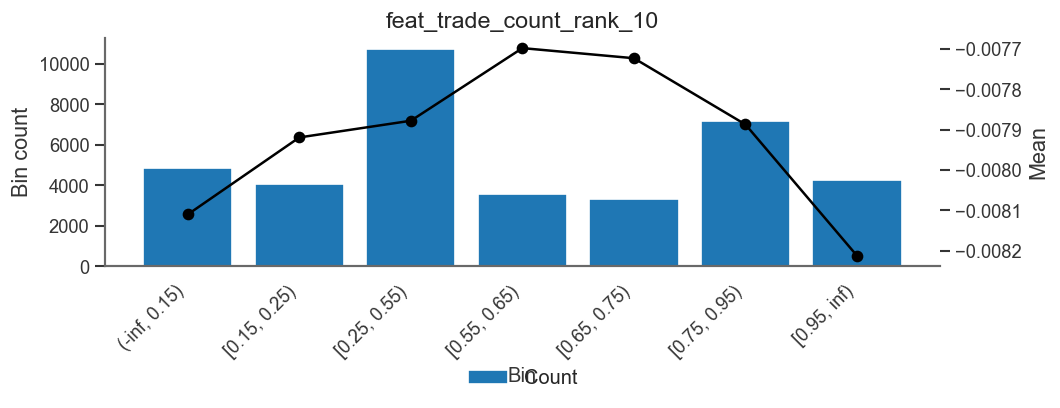



:::


## Momentum

<style type="text/css">
#T_c5baa  {
  border-collapse: collapse;
  border: 1px solid black;
}
#T_c5baa th {
  border: 1px solid black;
  padding: 4px 8px;
  text-align: center;
}
#T_c5baa td {
  border: 1px solid black;
  padding: 4px 8px;
}
#T_c5baa thead th {
  border-bottom: 2px solid black;
}
#T_c5baa_row0_col0, #T_c5baa_row0_col4, #T_c5baa_row1_col0, #T_c5baa_row1_col4, #T_c5baa_row2_col0, #T_c5baa_row2_col4, #T_c5baa_row3_col0, #T_c5baa_row3_col4, #T_c5baa_row4_col0, #T_c5baa_row4_col4, #T_c5baa_row5_col0, #T_c5baa_row5_col4, #T_c5baa_row6_col0, #T_c5baa_row6_col4 {
  text-align: left;
}
#T_c5baa_row0_col1, #T_c5baa_row0_col2, #T_c5baa_row0_col3, #T_c5baa_row1_col1, #T_c5baa_row1_col2, #T_c5baa_row1_col3, #T_c5baa_row2_col1, #T_c5baa_row2_col2, #T_c5baa_row2_col3, #T_c5baa_row3_col1, #T_c5baa_row3_col2, #T_c5baa_row3_col3, #T_c5baa_row4_col1, #T_c5baa_row4_col2, #T_c5baa_row4_col3, #T_c5baa_row5_col1, #T_c5baa_row5_col2, #T_c5baa_row5_col3, #T_c5baa_row6_col1
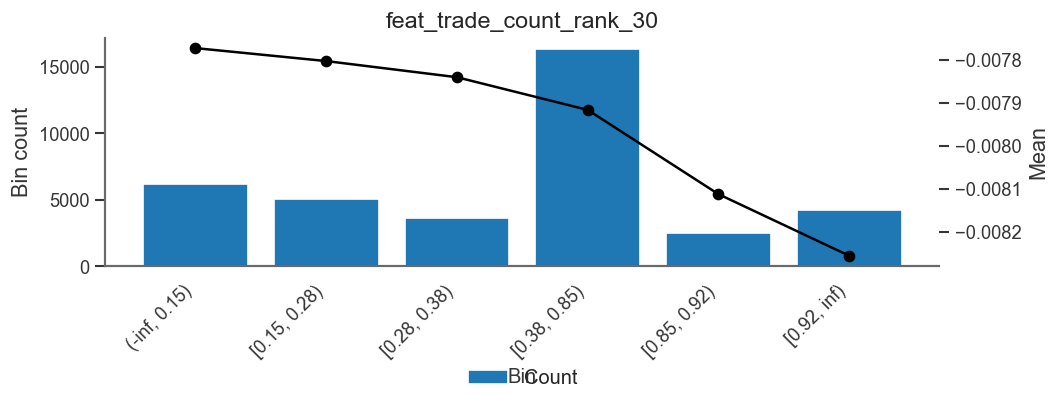



::: {.panel-tabset}


### feat_cci_20


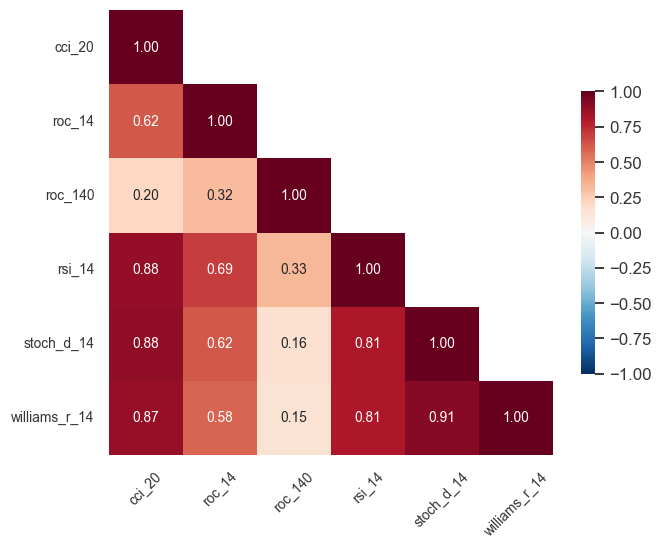




### feat_roc_14


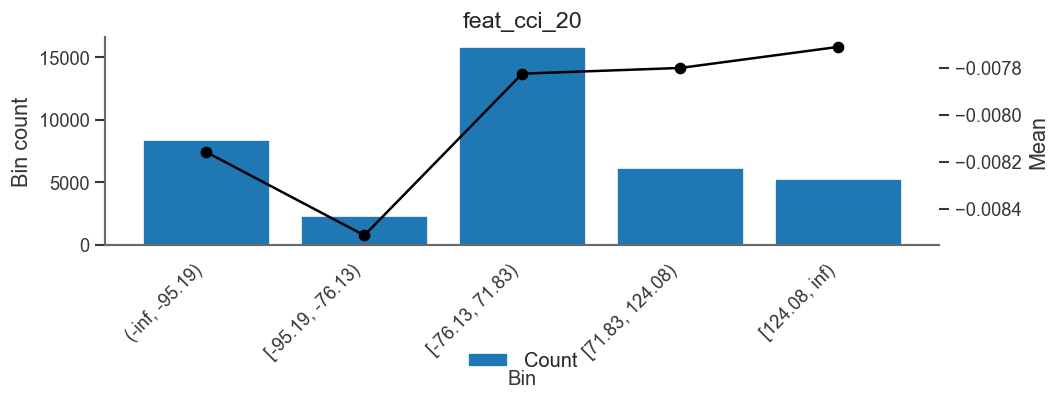




### feat_roc_140


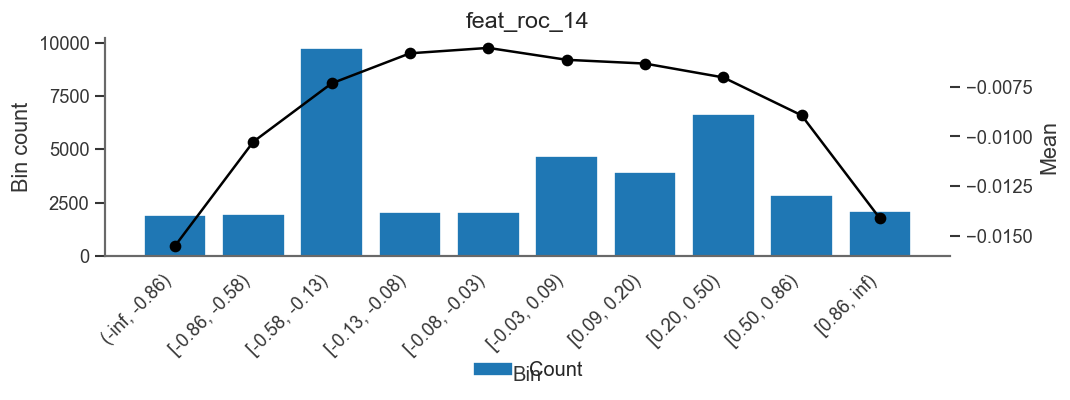




### feat_rsi_14


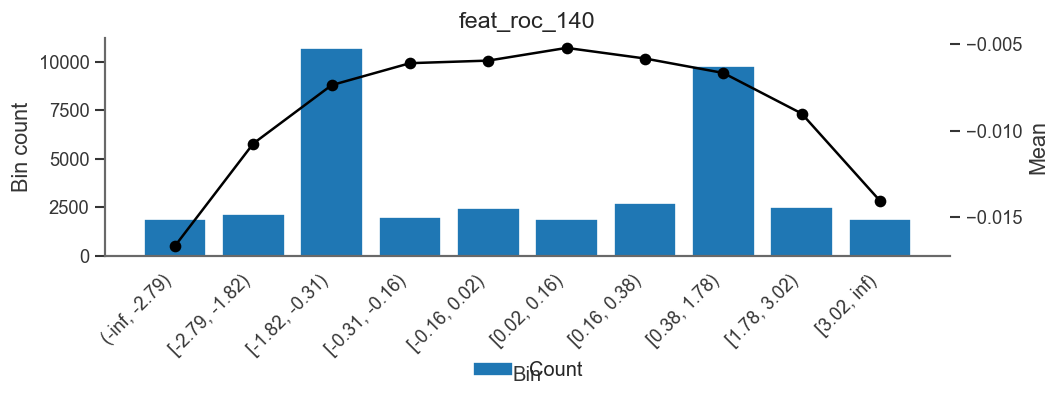




### feat_stoch_d_14


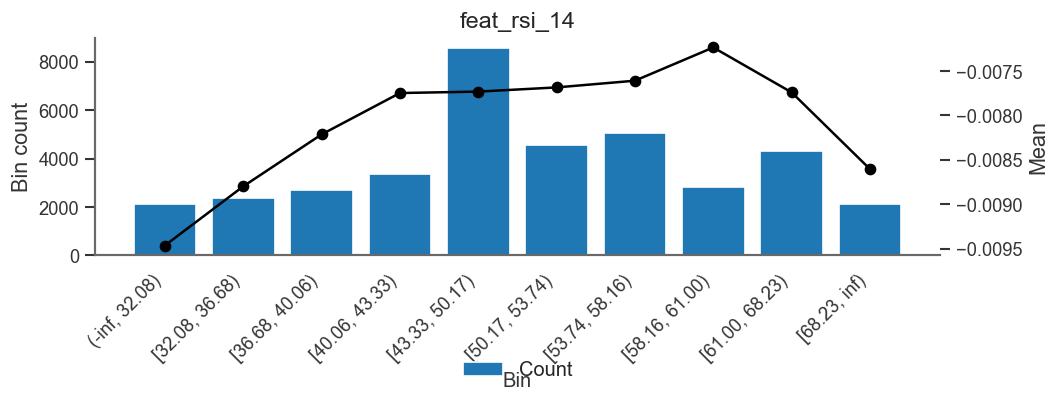




### feat_williams_r_14


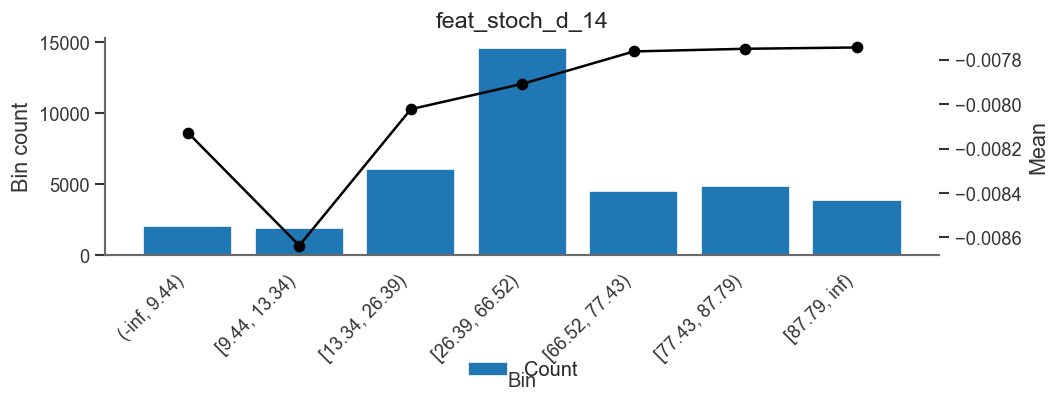



:::


## Trend

<style type="text/css">
#T_a0cf9  {
  border-collapse: collapse;
  border: 1px solid black;
}
#T_a0cf9 th {
  border: 1px solid black;
  padding: 4px 8px;
  text-align: center;
}
#T_a0cf9 td {
  border: 1px solid black;
  padding: 4px 8px;
}
#T_a0cf9 thead th {
  border-bottom: 2px solid black;
}
#T_a0cf9_row0_col0, #T_a0cf9_row0_col4, #T_a0cf9_row1_col0, #T_a0cf9_row1_col4, #T_a0cf9_row2_col0, #T_a0cf9_row2_col4, #T_a0cf9_row3_col0, #T_a0cf9_row3_col4, #T_a0cf9_row4_col0, #T_a0cf9_row4_col4, #T_a0cf9_row5_col0, #T_a0cf9_row5_col4, #T_a0cf9_row6_col0, #T_a0cf9_row6_col4, #T_a0cf9_row7_col0, #T_a0cf9_row7_col4, #T_a0cf9_row8_col0, #T_a0cf9_row8_col4, #T_a0cf9_row9_col0, #T_a0cf9_row9_col4, #T_a0cf9_row10_col0, #T_a0cf9_row10_col4, #T_a0cf9_row11_col0, #T_a0cf9_row11_col4 {
  text-align: left;
}
#T_a0cf9_row0_col1, #T_a0cf9_row0_col2, #T_a0cf9_row0_col3, #T_a0cf9_row1_col1, #T_a0cf9_row1_col2, #T_a0cf9_row1_col3, #T_a0cf9_row2_col1, #T_a0cf9_row2_col2, #T_a0cf9_row2_col
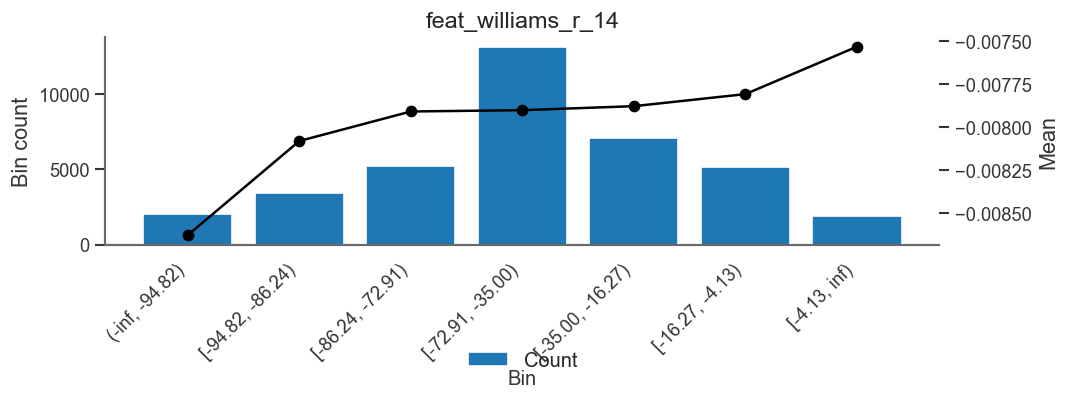



::: {.panel-tabset}


### feat_adx_14


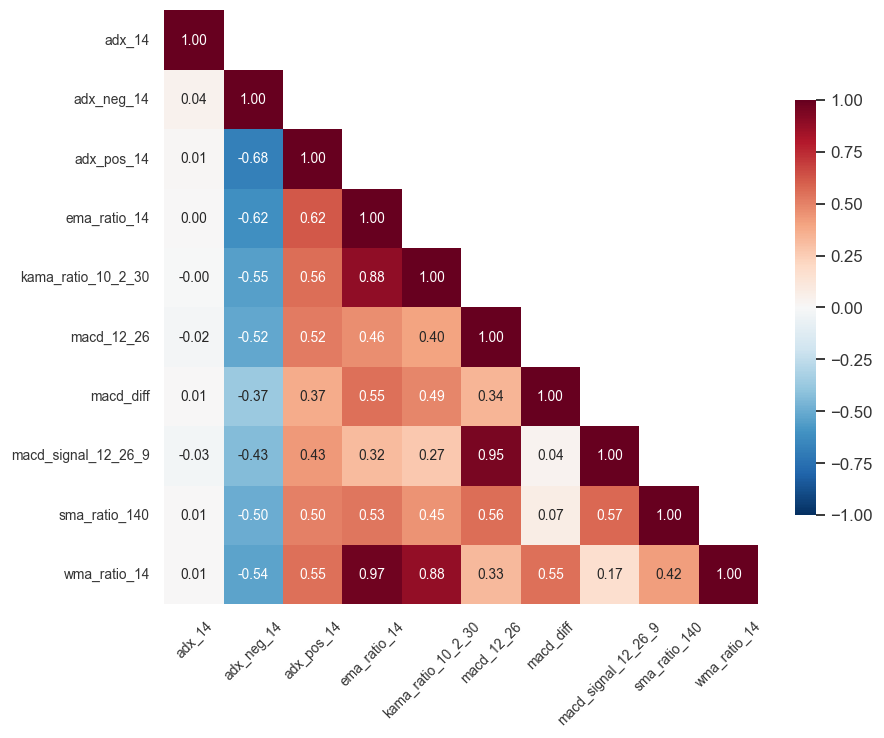




### feat_adx_neg_14


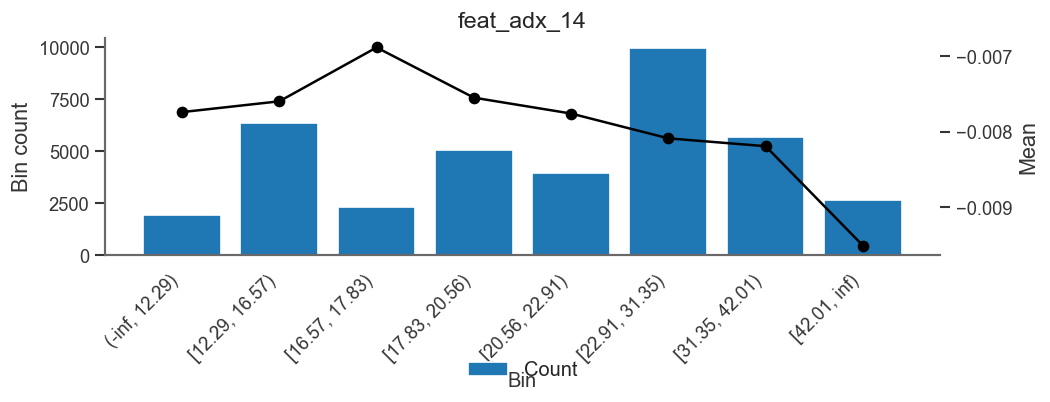




### feat_adx_pos_14


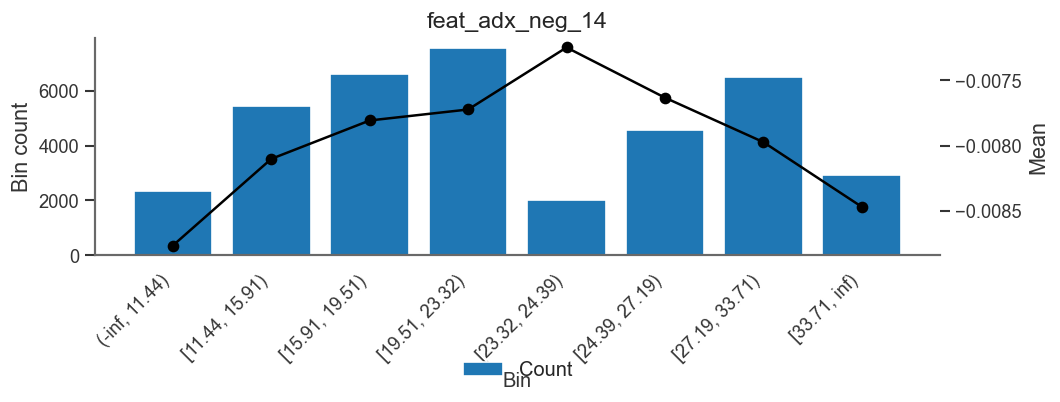




### feat_ema_ratio_14


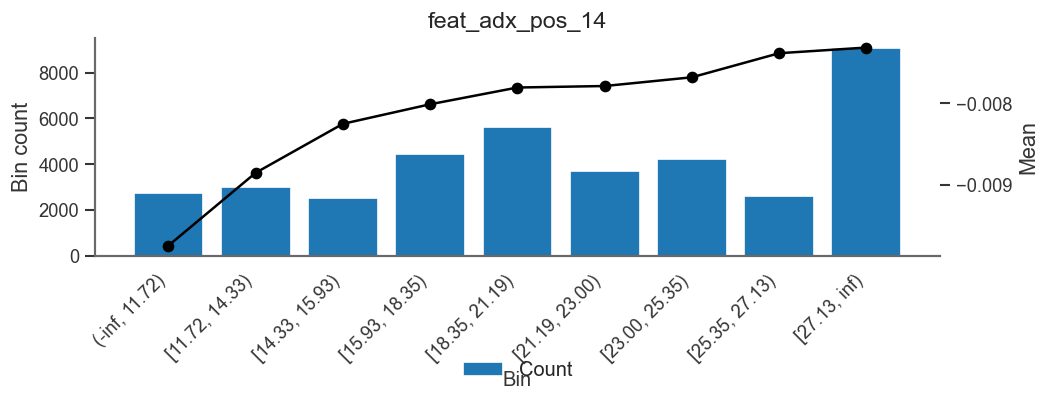




### feat_kama_ratio_10_2_30


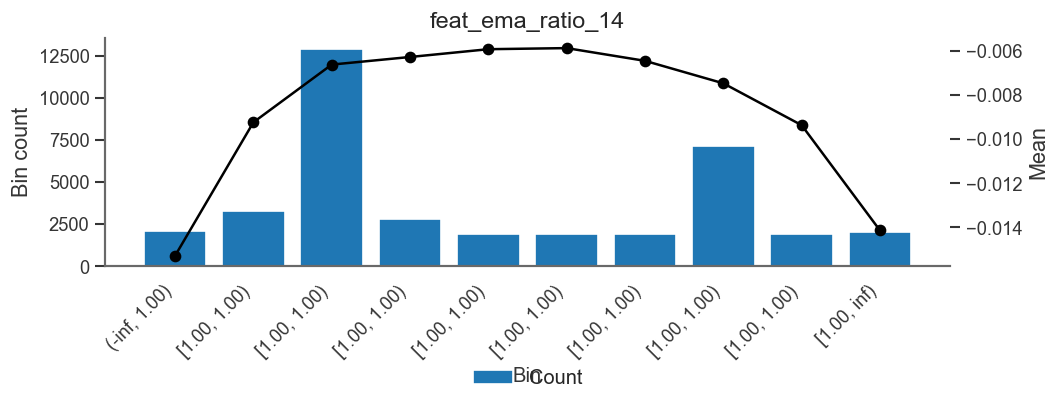




### feat_macd_12_26


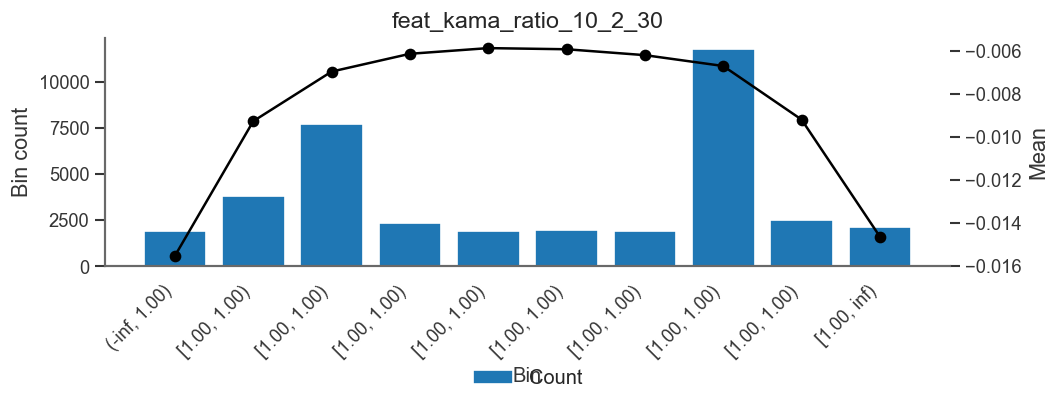




### feat_macd_diff


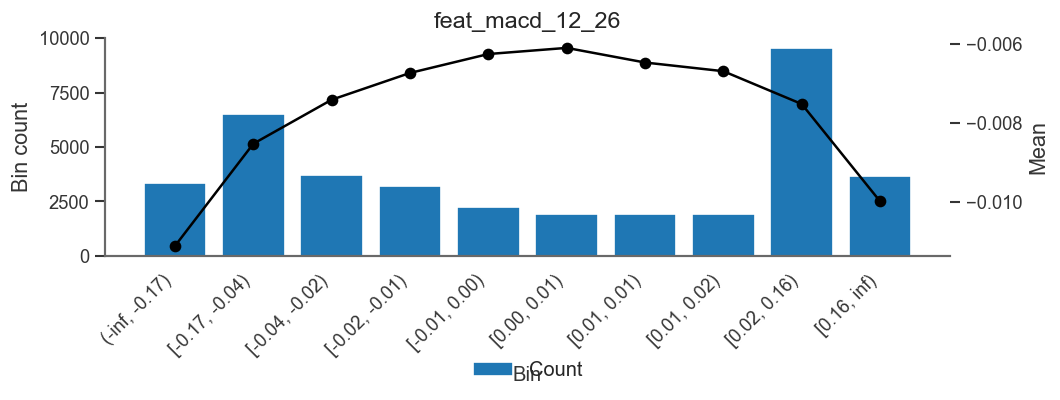




### feat_macd_signal_12_26_9


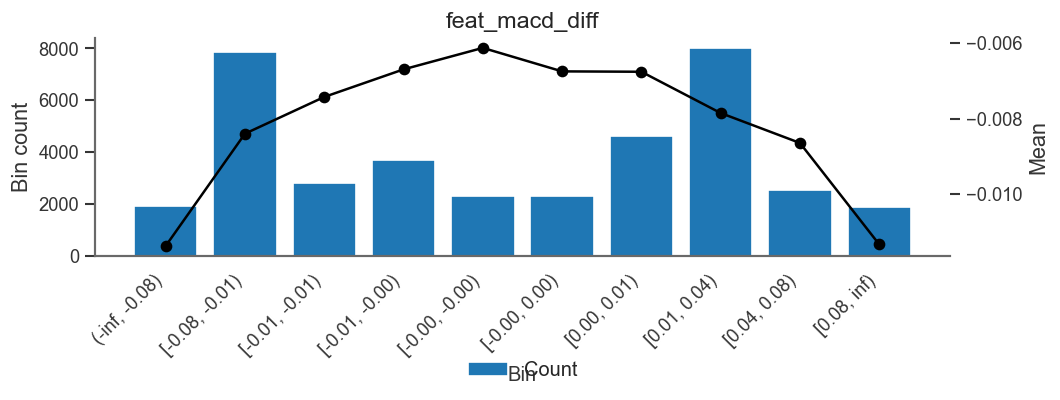




### feat_sma_ratio_140


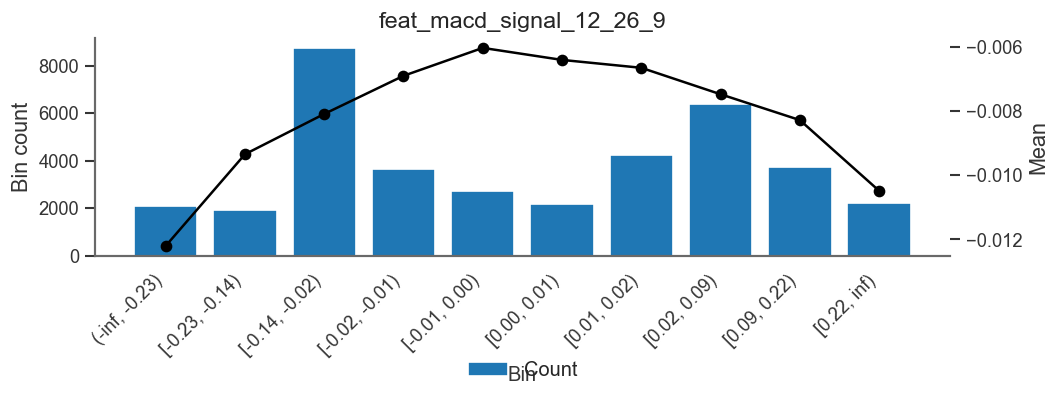




### feat_wma_ratio_14


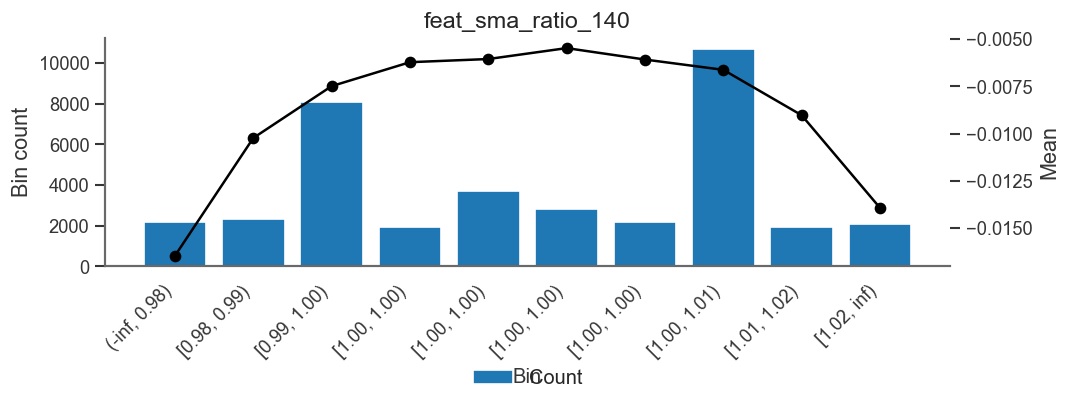



:::


## Autocorrelation

<style type="text/css">
#T_d55f8  {
  border-collapse: collapse;
  border: 1px solid black;
}
#T_d55f8 th {
  border: 1px solid black;
  padding: 4px 8px;
  text-align: center;
}
#T_d55f8 td {
  border: 1px solid black;
  padding: 4px 8px;
}
#T_d55f8 thead th {
  border-bottom: 2px solid black;
}
#T_d55f8_row0_col0, #T_d55f8_row0_col4, #T_d55f8_row1_col0, #T_d55f8_row1_col4, #T_d55f8_row2_col0, #T_d55f8_row2_col4, #T_d55f8_row3_col0, #T_d55f8_row3_col4, #T_d55f8_row4_col0, #T_d55f8_row4_col4 {
  text-align: left;
}
#T_d55f8_row0_col1, #T_d55f8_row0_col2, #T_d55f8_row0_col3, #T_d55f8_row1_col1, #T_d55f8_row1_col2, #T_d55f8_row1_col3, #T_d55f8_row2_col1, #T_d55f8_row2_col2, #T_d55f8_row2_col3, #T_d55f8_row3_col1, #T_d55f8_row3_col2, #T_d55f8_row3_col3, #T_d55f8_row4_col1, #T_d55f8_row4_col2, #T_d55f8_row4_col3 {
  text-align: right;
}
</style>
<table id="T_d55f8">
  <thead>
    <tr>
      <th id="T_d55f8_level0_col0" class="col_heading level0 col0" >Feature</t
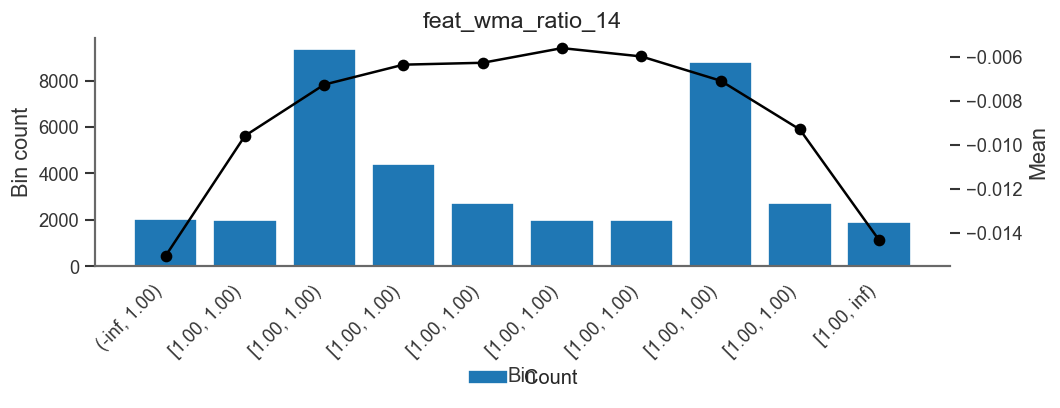



::: {.panel-tabset}


### feat_return_autocorr_lag1_30


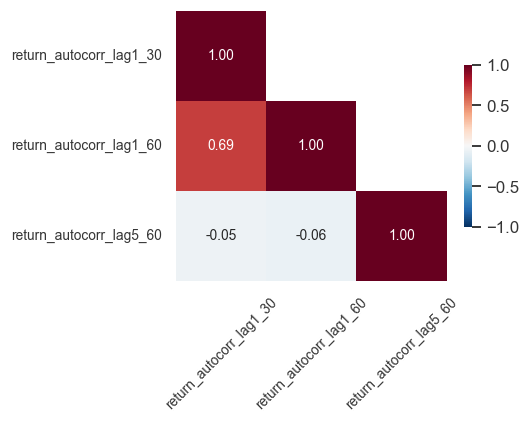




### feat_return_autocorr_lag1_60


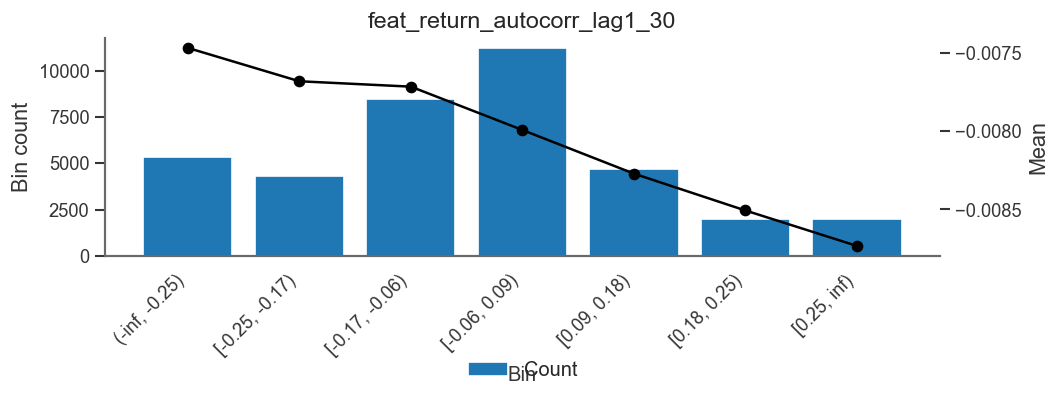




### feat_return_autocorr_lag5_60


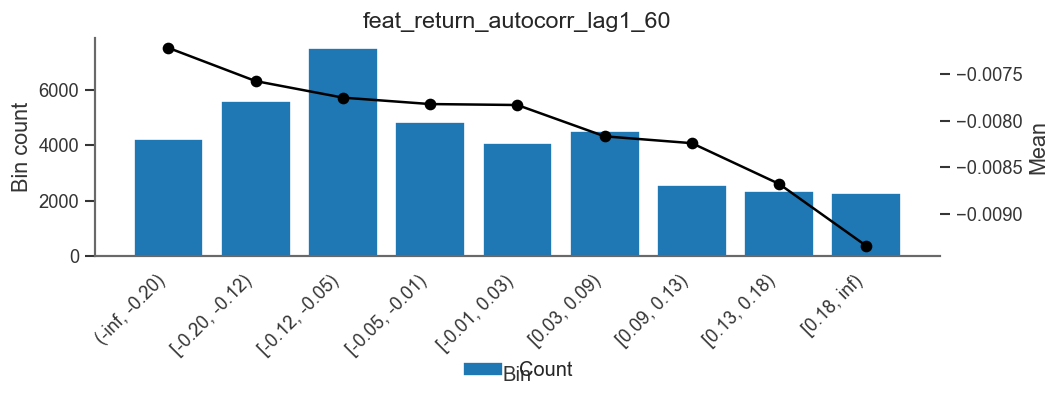



:::


## Market Structure

<style type="text/css">
#T_19b98  {
  border-collapse: collapse;
  border: 1px solid black;
}
#T_19b98 th {
  border: 1px solid black;
  padding: 4px 8px;
  text-align: center;
}
#T_19b98 td {
  border: 1px solid black;
  padding: 4px 8px;
}
#T_19b98 thead th {
  border-bottom: 2px solid black;
}
#T_19b98_row0_col0, #T_19b98_row0_col4, #T_19b98_row1_col0, #T_19b98_row1_col4, #T_19b98_row2_col0, #T_19b98_row2_col4, #T_19b98_row3_col0, #T_19b98_row3_col4, #T_19b98_row4_col0, #T_19b98_row4_col4, #T_19b98_row5_col0, #T_19b98_row5_col4, #T_19b98_row6_col0, #T_19b98_row6_col4, #T_19b98_row7_col0, #T_19b98_row7_col4, #T_19b98_row8_col0, #T_19b98_row8_col4, #T_19b98_row9_col0, #T_19b98_row9_col4, #T_19b98_row10_col0, #T_19b98_row10_col4, #T_19b98_row11_col0, #T_19b98_row11_col4, #T_19b98_row12_col0, #T_19b98_row12_col4, #T_19b98_row13_col0, #T_19b98_row13_col4, #T_19b98_row14_col0, #T_19b98_row14_col4, #T_19b98_row15_col0, #T_19b98_row15_col4, #T_19b98_row16_col0, 
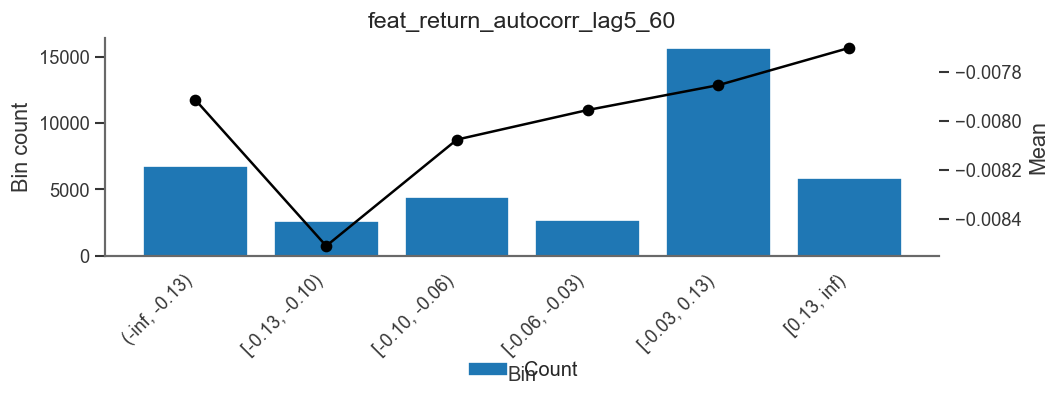



::: {.panel-tabset}


### feat_atr_dist_low_30


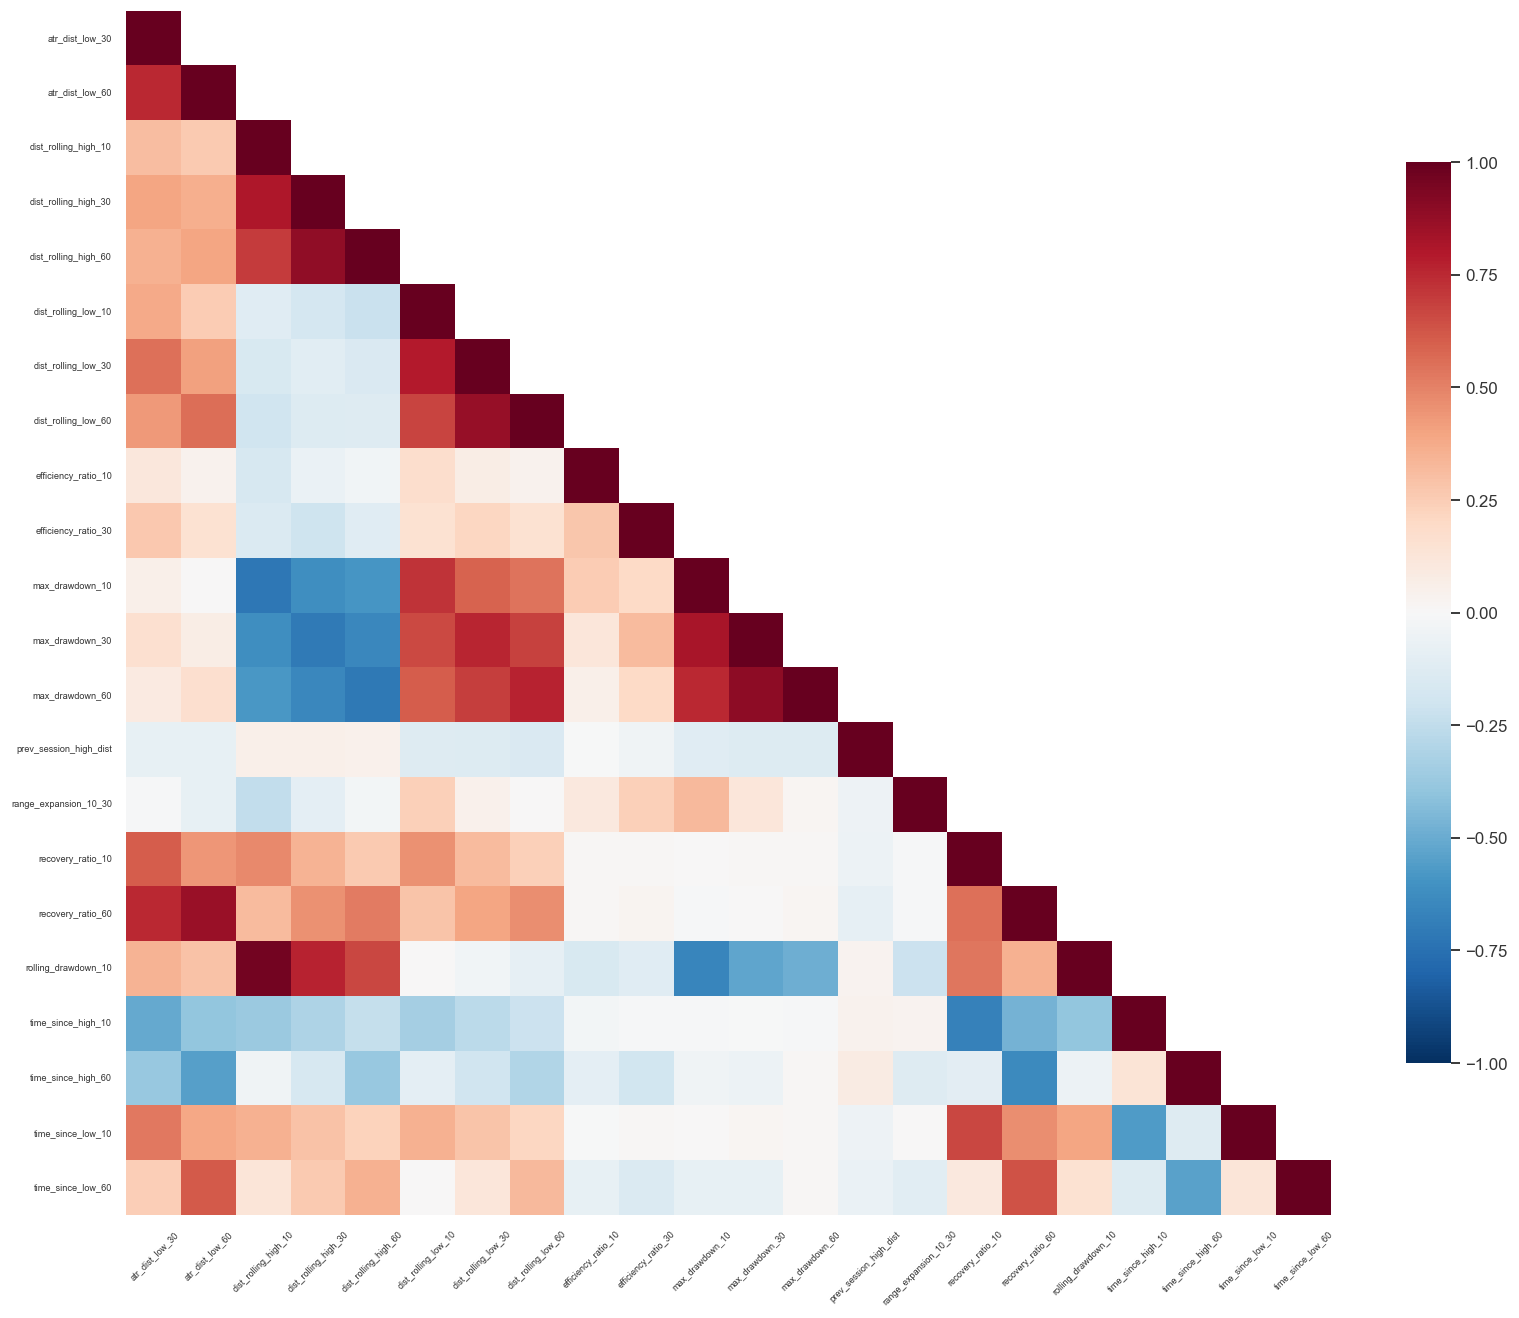




### feat_atr_dist_low_60


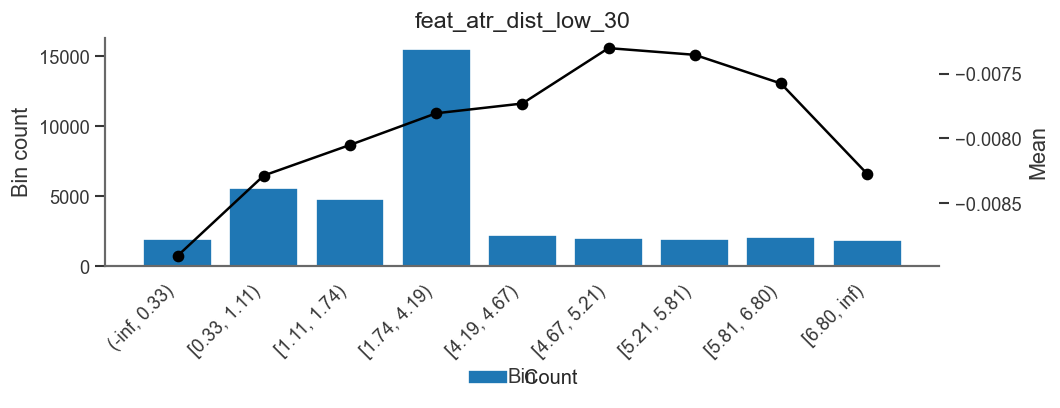




### feat_dist_rolling_high_10


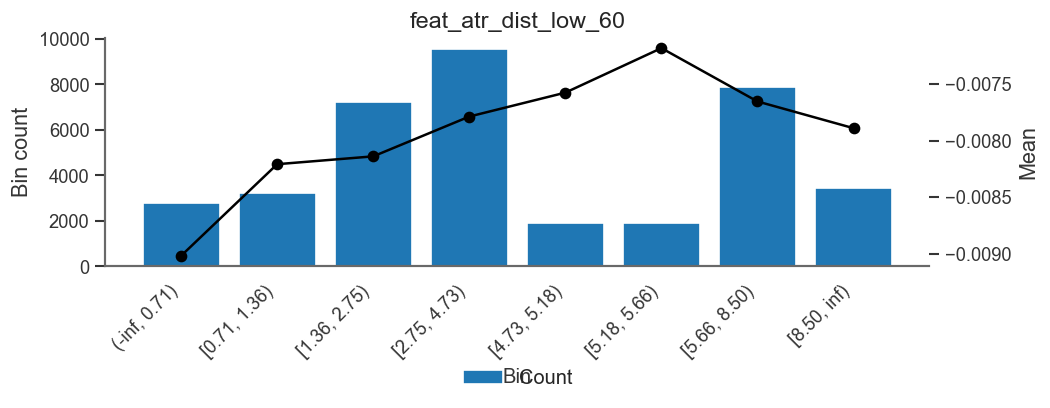




### feat_dist_rolling_high_30


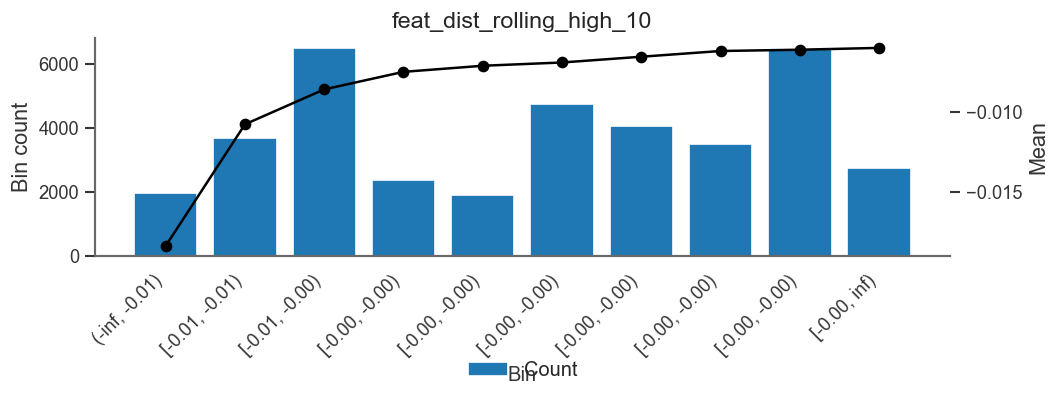




### feat_dist_rolling_high_60


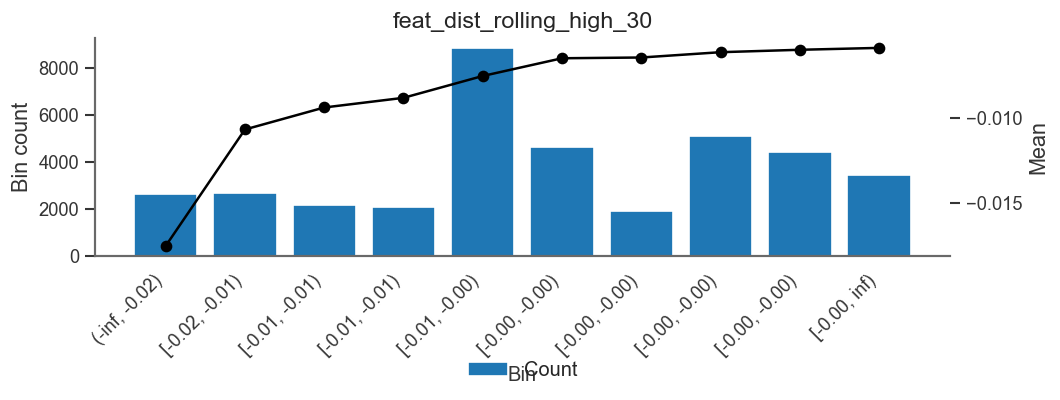




### feat_dist_rolling_low_10


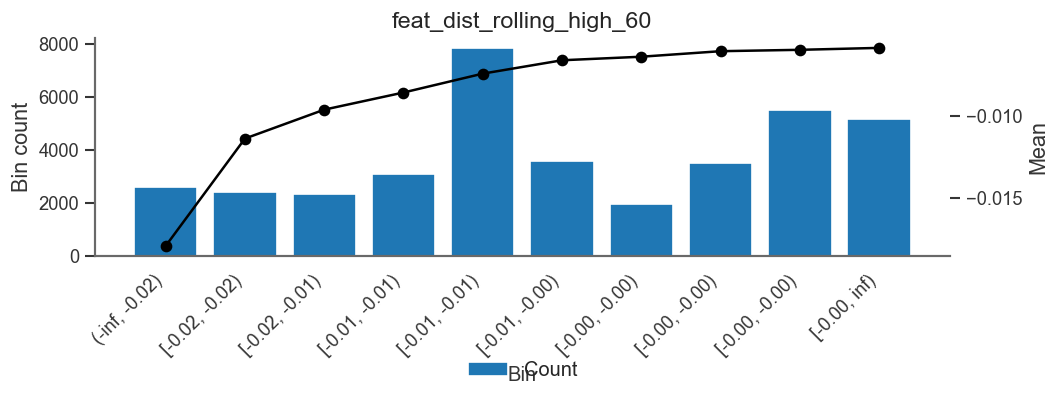




### feat_dist_rolling_low_30


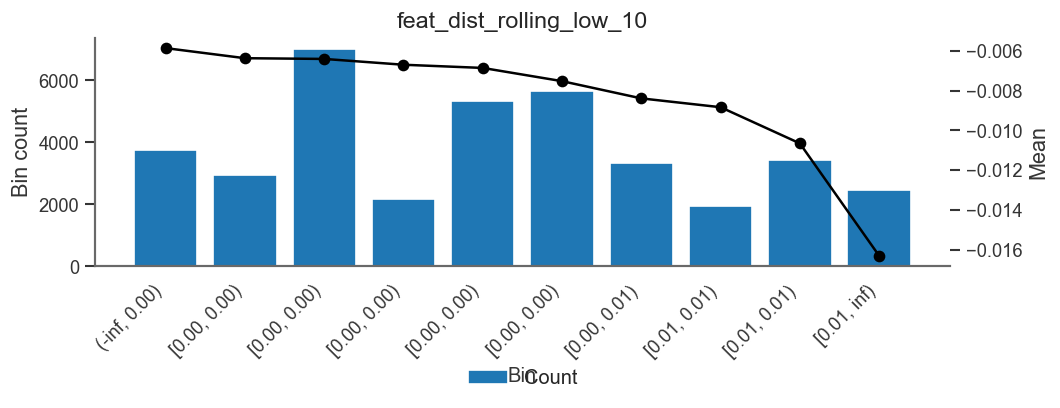




### feat_dist_rolling_low_60


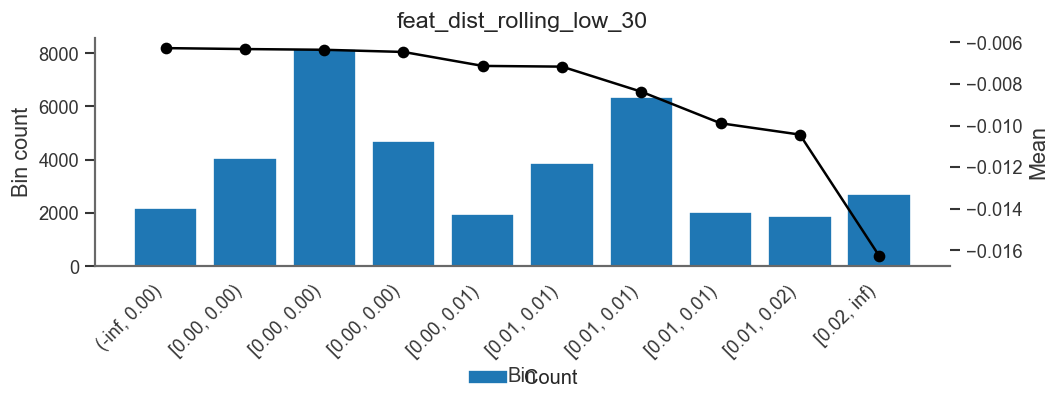




### feat_efficiency_ratio_10


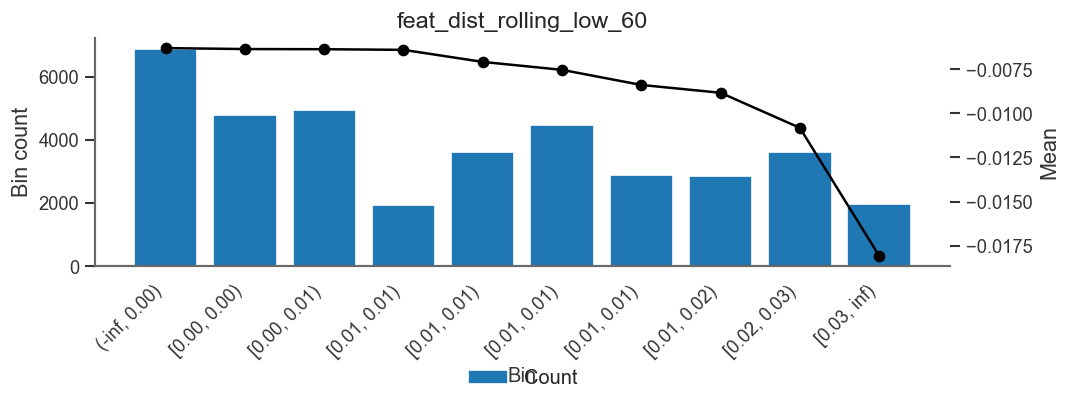




### feat_efficiency_ratio_30


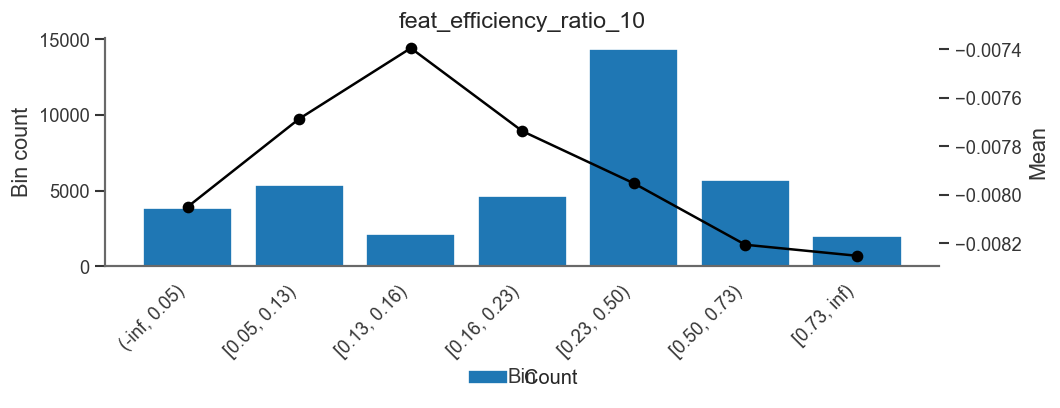




### feat_max_drawdown_10


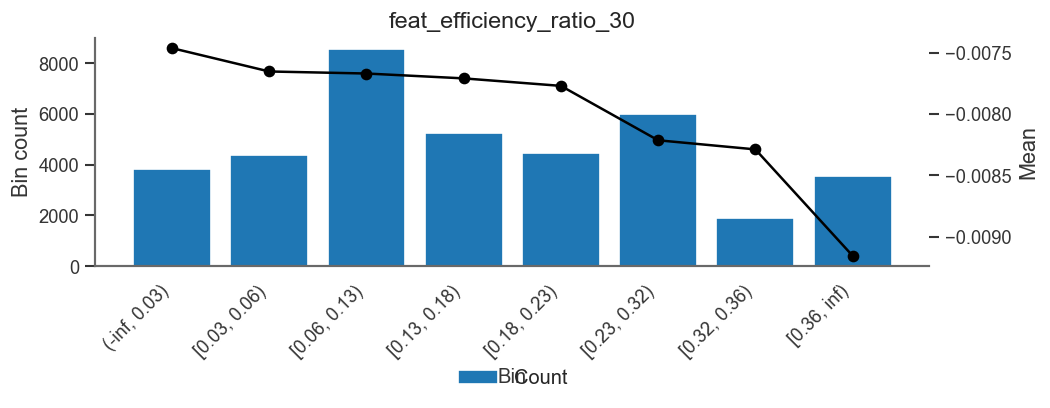




### feat_max_drawdown_30


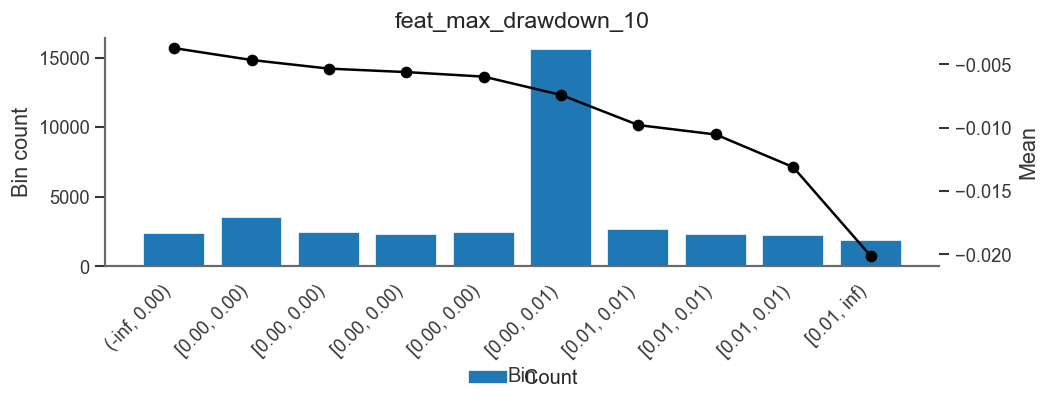




### feat_max_drawdown_60


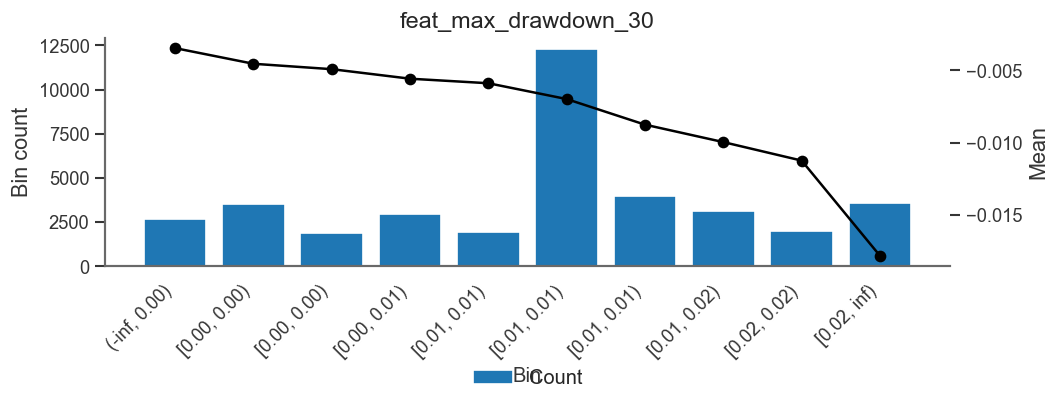




### feat_prev_session_high_dist


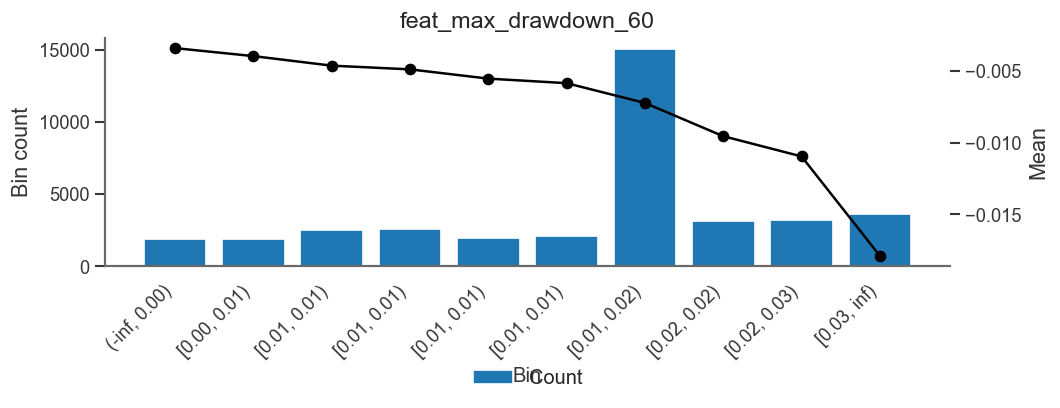




### feat_range_expansion_10_30


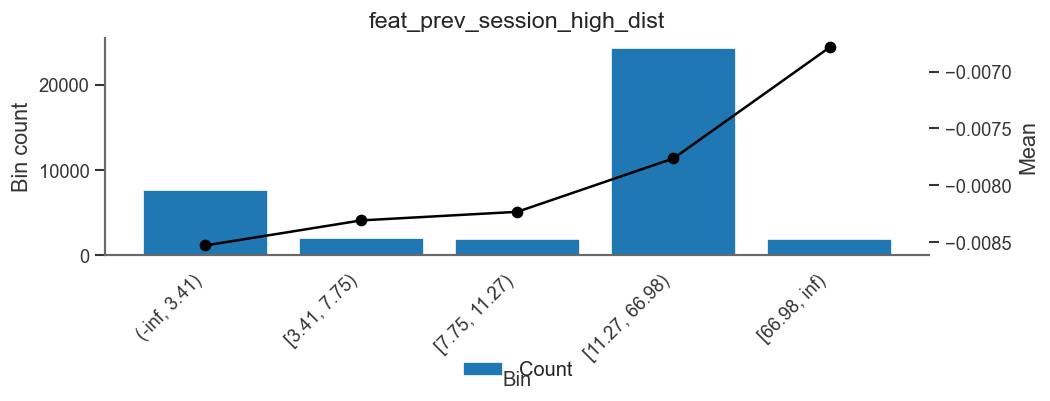




### feat_recovery_ratio_10


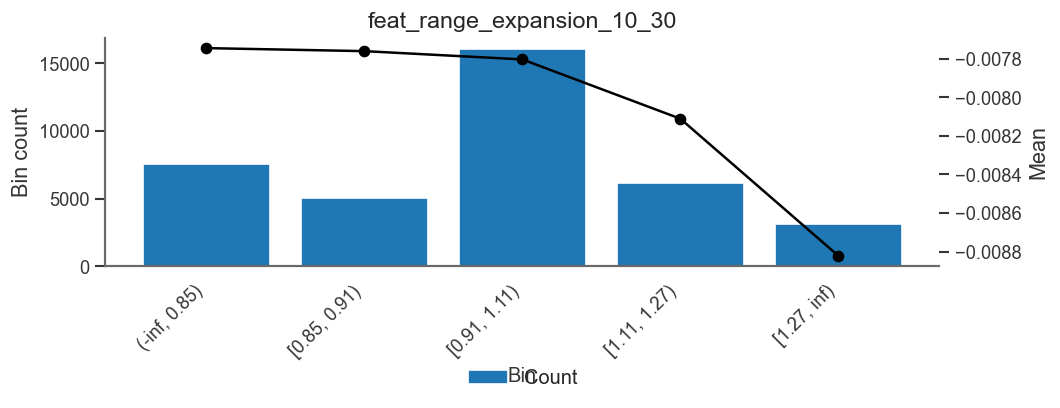




### feat_recovery_ratio_60


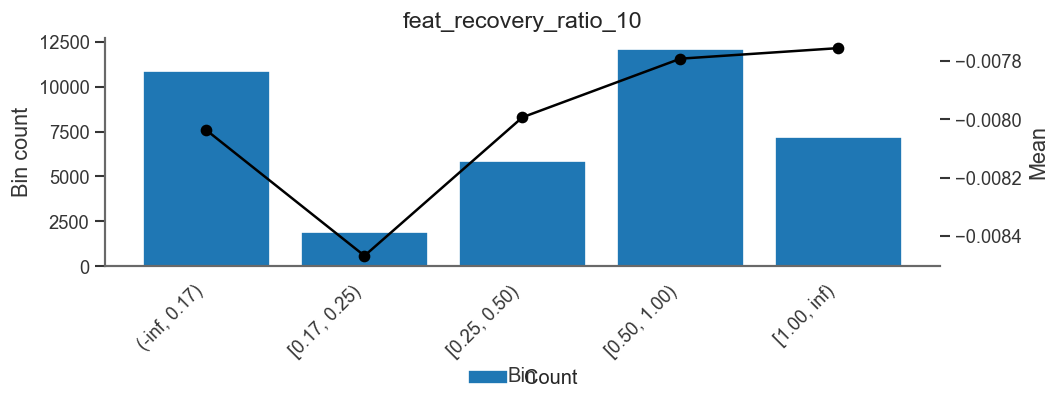




### feat_rolling_drawdown_10


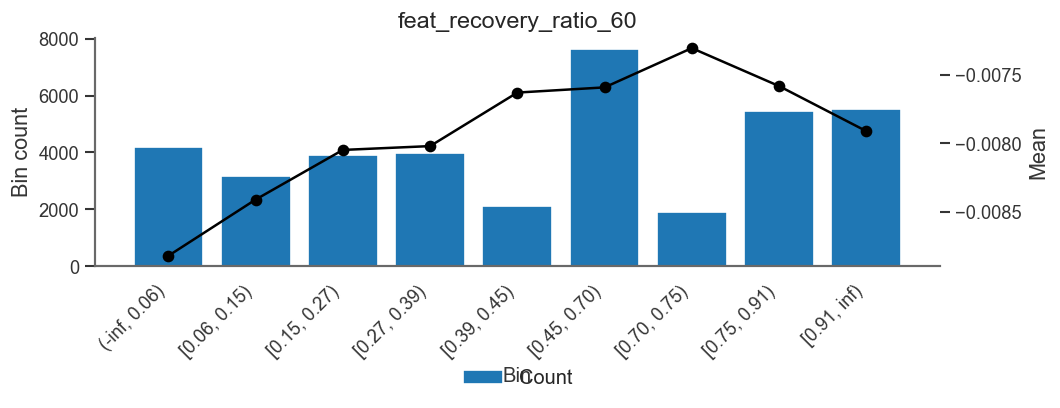




### feat_time_since_high_10


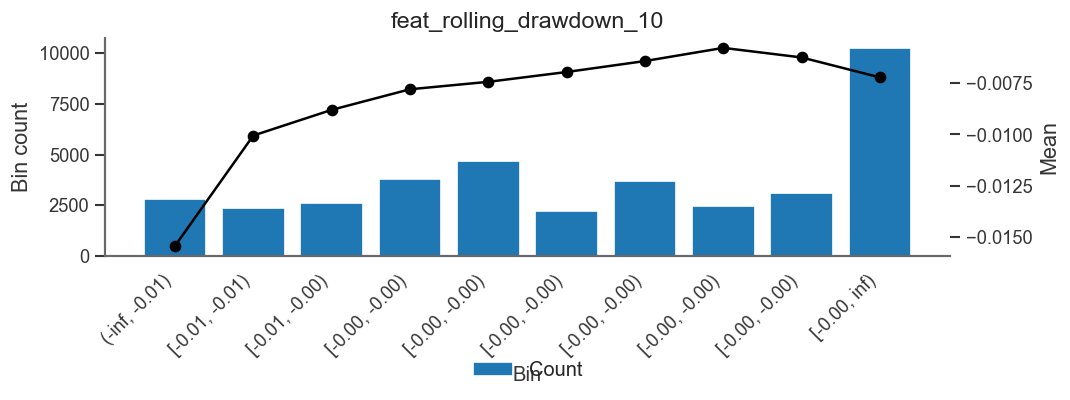




### feat_time_since_high_60


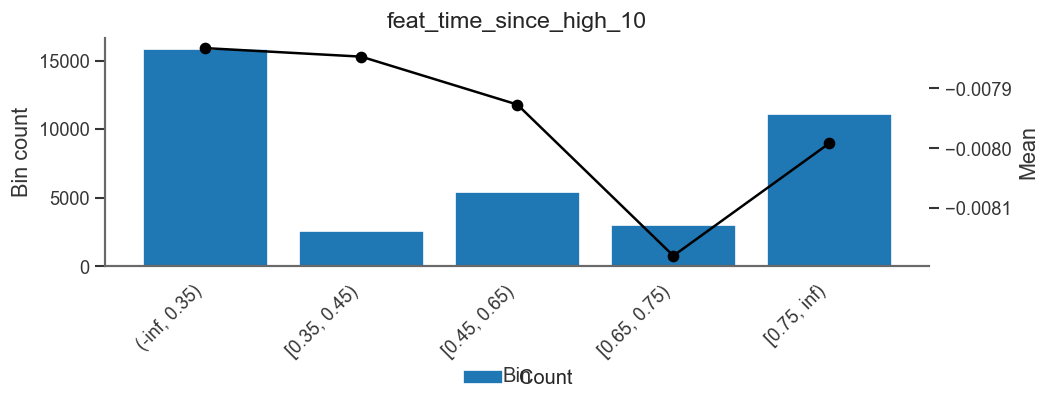




### feat_time_since_low_10


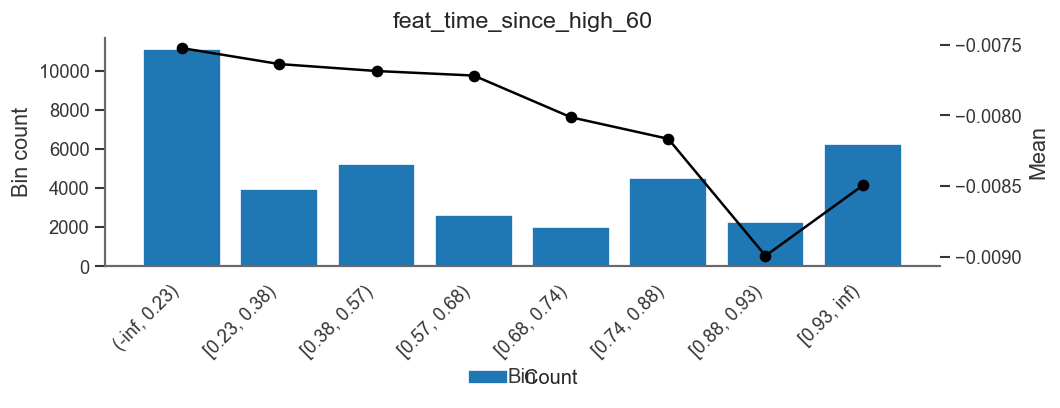




### feat_time_since_low_60


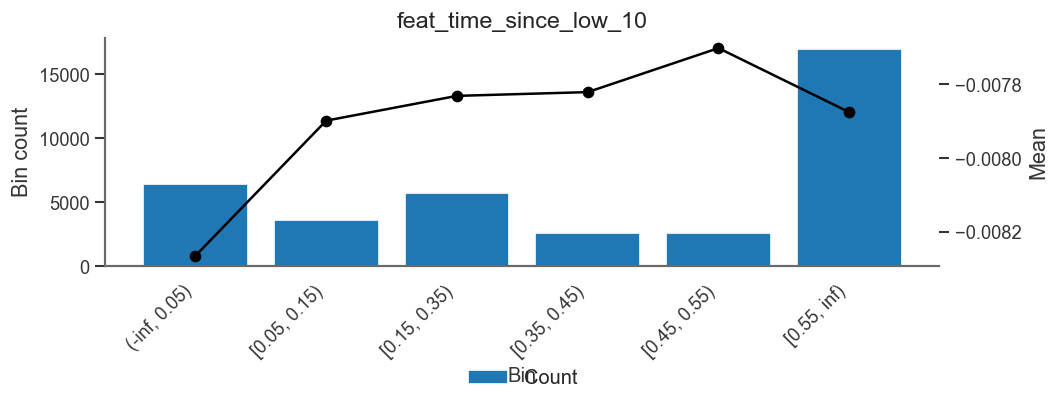



:::


## Swing

<style type="text/css">
#T_2dd1e  {
  border-collapse: collapse;
  border: 1px solid black;
}
#T_2dd1e th {
  border: 1px solid black;
  padding: 4px 8px;
  text-align: center;
}
#T_2dd1e td {
  border: 1px solid black;
  padding: 4px 8px;
}
#T_2dd1e thead th {
  border-bottom: 2px solid black;
}
#T_2dd1e_row0_col0, #T_2dd1e_row0_col4, #T_2dd1e_row1_col0, #T_2dd1e_row1_col4, #T_2dd1e_row2_col0, #T_2dd1e_row2_col4, #T_2dd1e_row3_col0, #T_2dd1e_row3_col4, #T_2dd1e_row4_col0, #T_2dd1e_row4_col4, #T_2dd1e_row5_col0, #T_2dd1e_row5_col4, #T_2dd1e_row6_col0, #T_2dd1e_row6_col4 {
  text-align: left;
}
#T_2dd1e_row0_col1, #T_2dd1e_row0_col2, #T_2dd1e_row0_col3, #T_2dd1e_row1_col1, #T_2dd1e_row1_col2, #T_2dd1e_row1_col3, #T_2dd1e_row2_col1, #T_2dd1e_row2_col2, #T_2dd1e_row2_col3, #T_2dd1e_row3_col1, #T_2dd1e_row3_col2, #T_2dd1e_row3_col3, #T_2dd1e_row4_col1, #T_2dd1e_row4_col2, #T_2dd1e_row4_col3, #T_2dd1e_row5_col1, #T_2dd1e_row5_col2, #T_2dd1e_row5_col3, #T_2dd1e_row6_col1, #
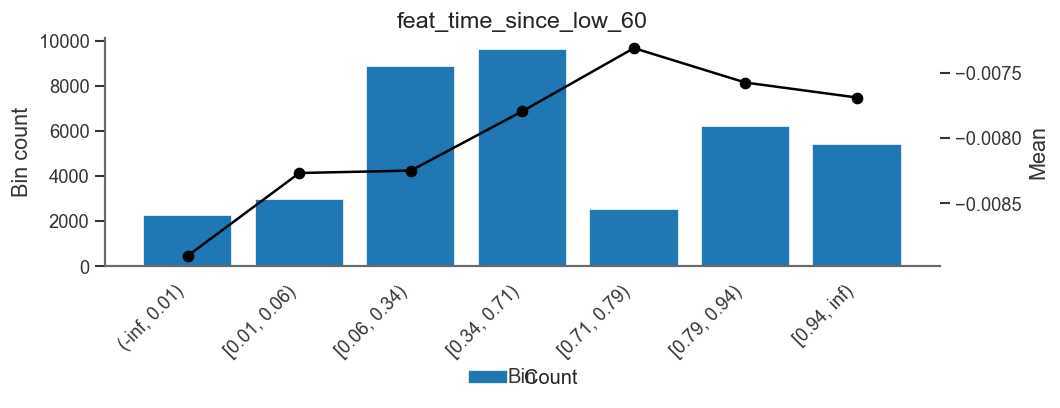



::: {.panel-tabset}


### feat_higher_high_count_5


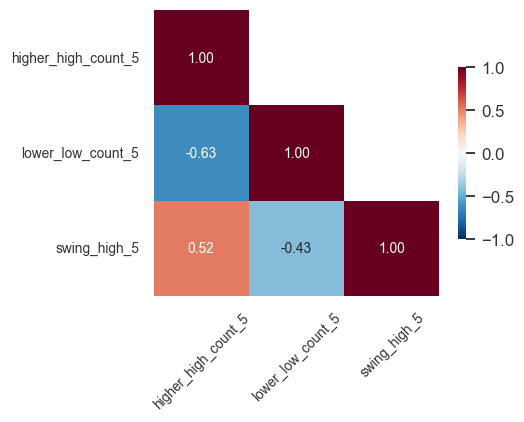




### feat_lower_low_count_5


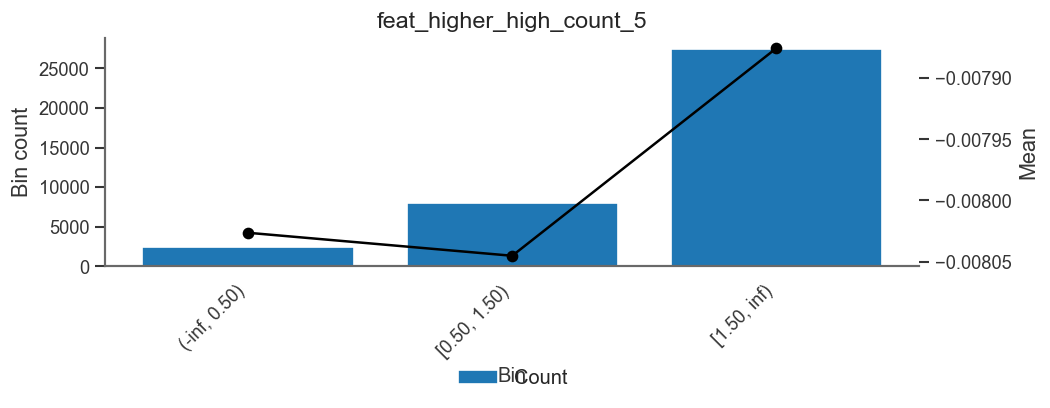




### feat_swing_high_5


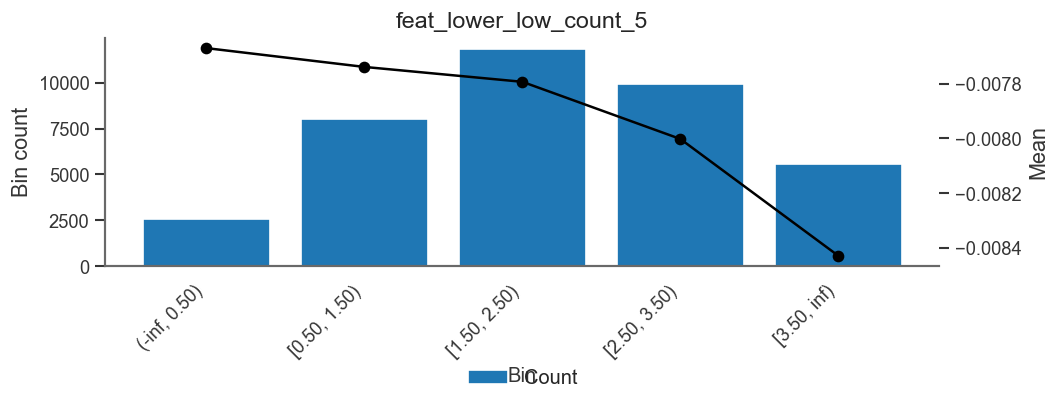



:::


## Tail Risk

<style type="text/css">
#T_807a8  {
  border-collapse: collapse;
  border: 1px solid black;
}
#T_807a8 th {
  border: 1px solid black;
  padding: 4px 8px;
  text-align: center;
}
#T_807a8 td {
  border: 1px solid black;
  padding: 4px 8px;
}
#T_807a8 thead th {
  border-bottom: 2px solid black;
}
#T_807a8_row0_col0, #T_807a8_row0_col4, #T_807a8_row1_col0, #T_807a8_row1_col4, #T_807a8_row2_col0, #T_807a8_row2_col4, #T_807a8_row3_col0, #T_807a8_row3_col4, #T_807a8_row4_col0, #T_807a8_row4_col4, #T_807a8_row5_col0, #T_807a8_row5_col4, #T_807a8_row6_col0, #T_807a8_row6_col4, #T_807a8_row7_col0, #T_807a8_row7_col4, #T_807a8_row8_col0, #T_807a8_row8_col4 {
  text-align: left;
}
#T_807a8_row0_col1, #T_807a8_row0_col2, #T_807a8_row0_col3, #T_807a8_row1_col1, #T_807a8_row1_col2, #T_807a8_row1_col3, #T_807a8_row2_col1, #T_807a8_row2_col2, #T_807a8_row2_col3, #T_807a8_row3_col1, #T_807a8_row3_col2, #T_807a8_row3_col3, #T_807a8_row4_col1, #T_807a8_row4_col2, #T_807a8_row4_col
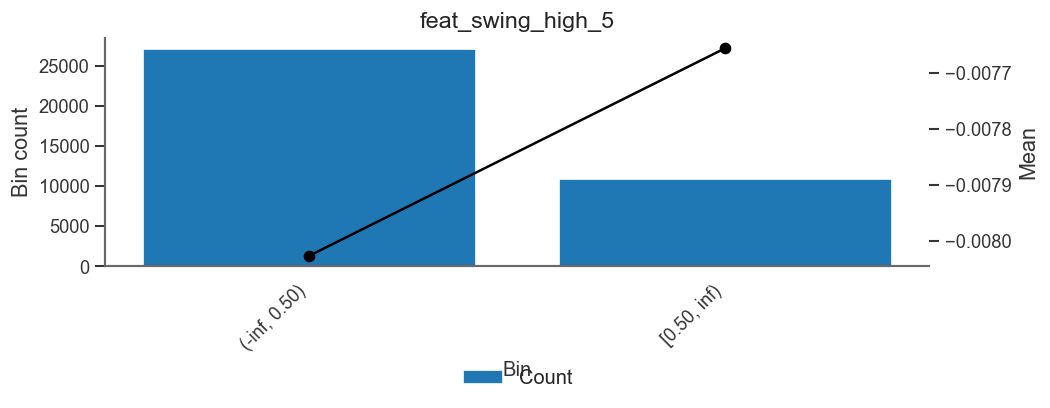



::: {.panel-tabset}


### feat_neg_return_mean_10


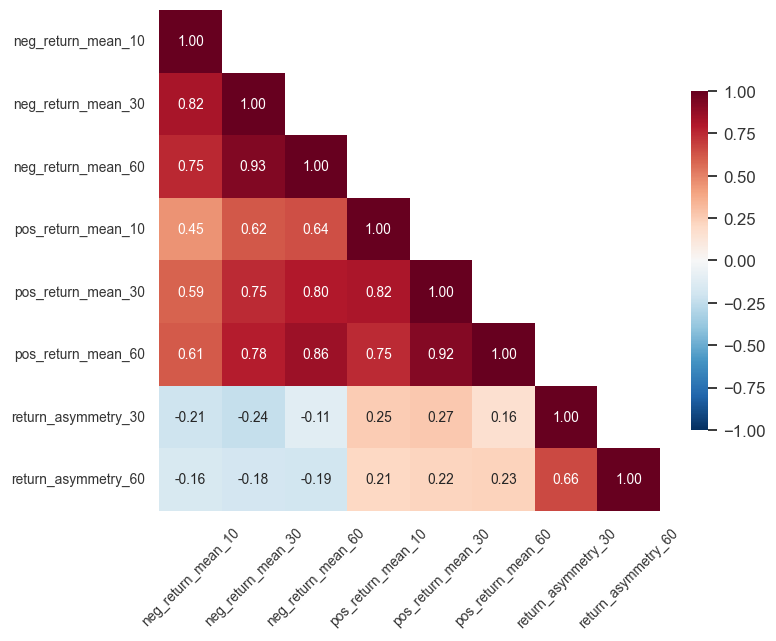




### feat_neg_return_mean_30


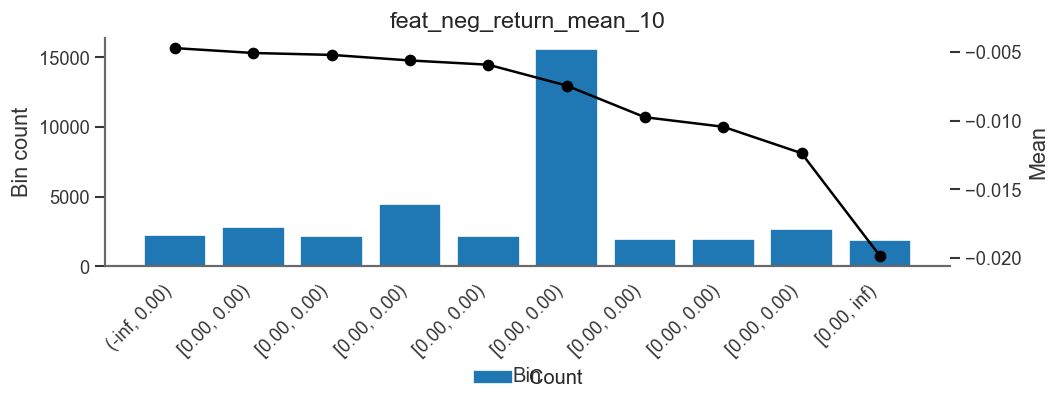




### feat_neg_return_mean_60


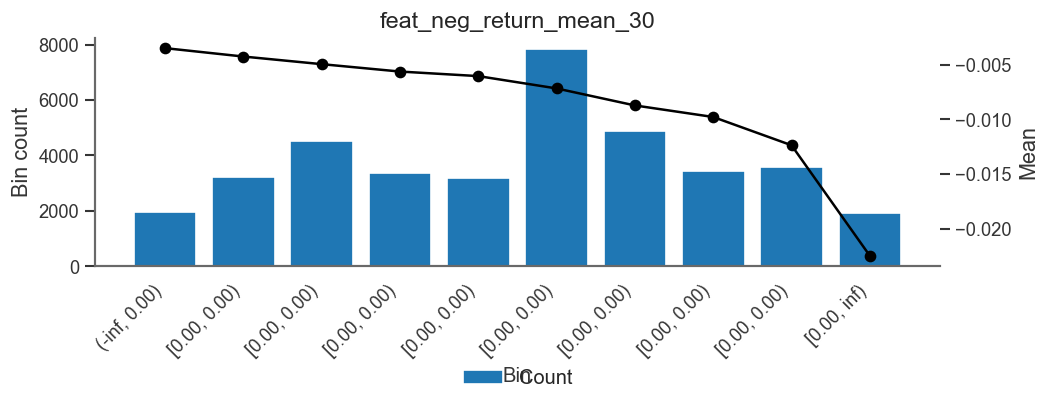




### feat_pos_return_mean_10


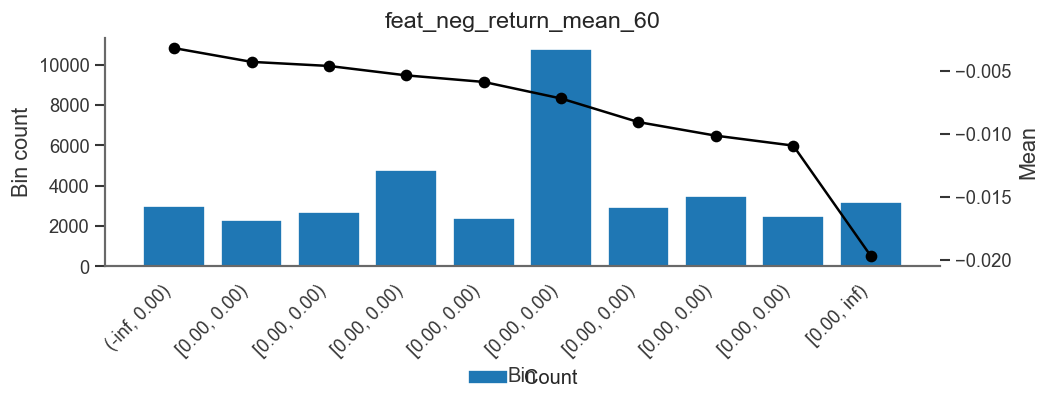




### feat_pos_return_mean_30


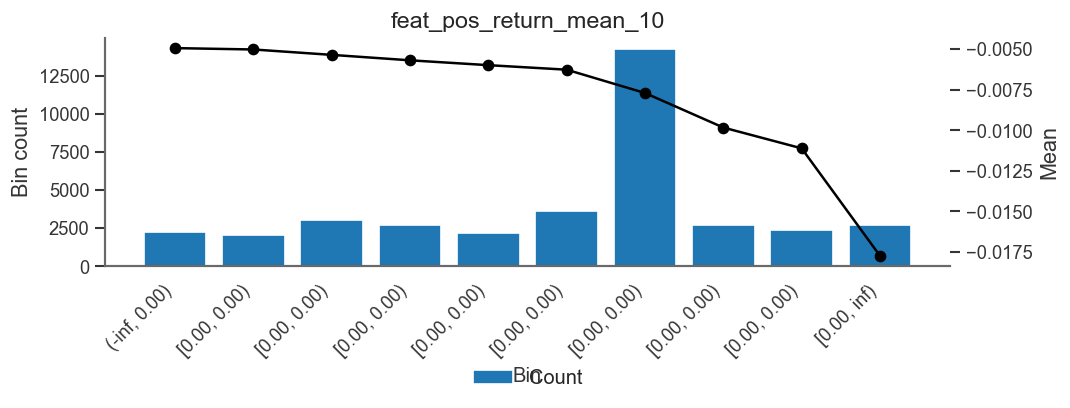




### feat_pos_return_mean_60


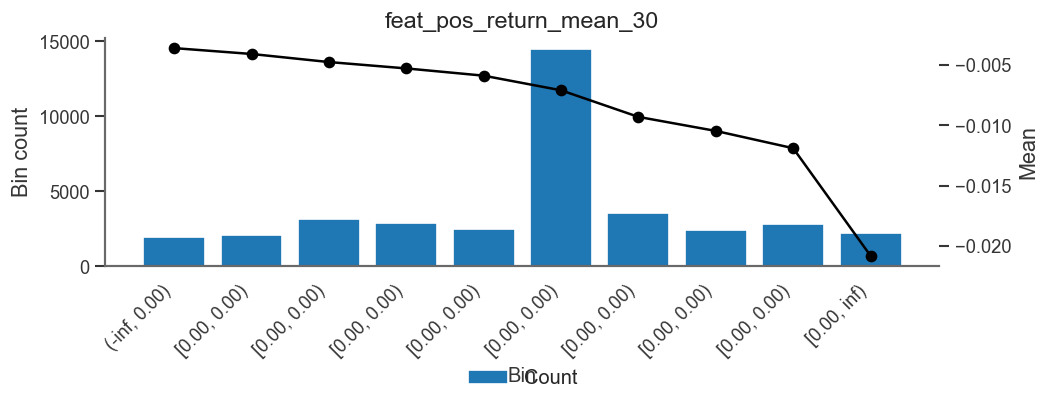




### feat_return_asymmetry_30


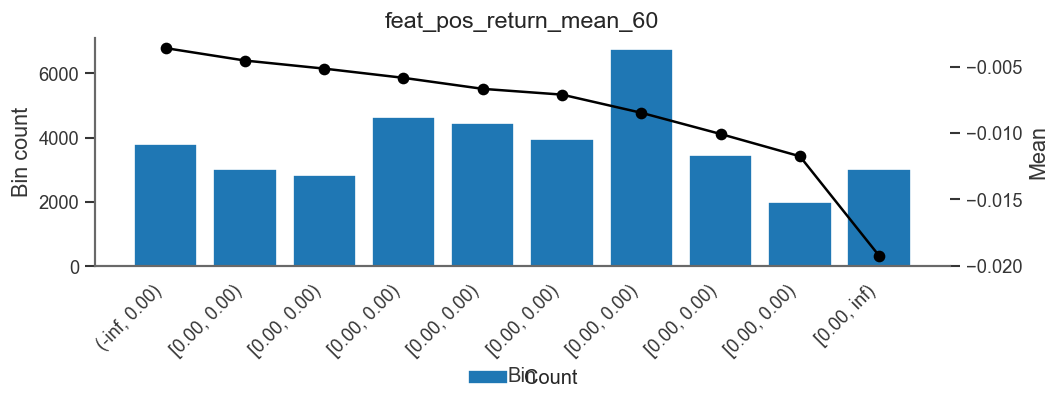




### feat_return_asymmetry_60


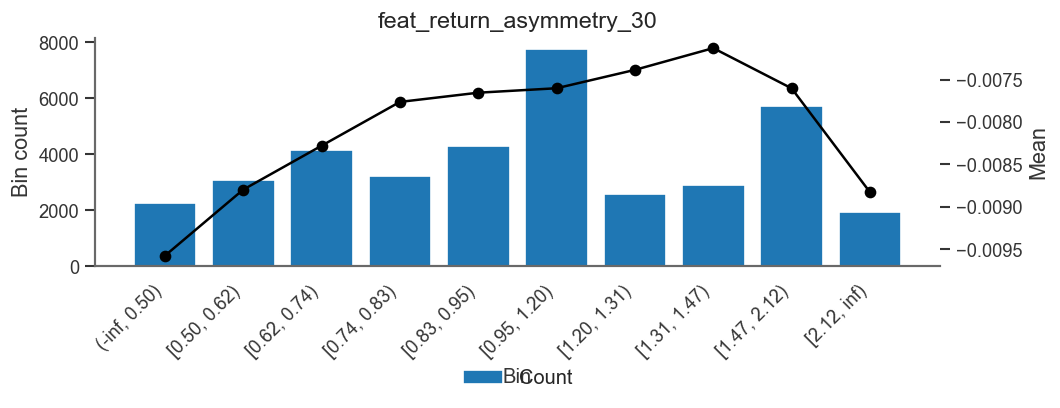



:::


## Ichimoku

<style type="text/css">
#T_02957  {
  border-collapse: collapse;
  border: 1px solid black;
}
#T_02957 th {
  border: 1px solid black;
  padding: 4px 8px;
  text-align: center;
}
#T_02957 td {
  border: 1px solid black;
  padding: 4px 8px;
}
#T_02957 thead th {
  border-bottom: 2px solid black;
}
#T_02957_row0_col0, #T_02957_row0_col4, #T_02957_row1_col0, #T_02957_row1_col4, #T_02957_row2_col0, #T_02957_row2_col4, #T_02957_row3_col0, #T_02957_row3_col4, #T_02957_row4_col0, #T_02957_row4_col4, #T_02957_row5_col0, #T_02957_row5_col4, #T_02957_row6_col0, #T_02957_row6_col4 {
  text-align: left;
}
#T_02957_row0_col1, #T_02957_row0_col2, #T_02957_row0_col3, #T_02957_row1_col1, #T_02957_row1_col2, #T_02957_row1_col3, #T_02957_row2_col1, #T_02957_row2_col2, #T_02957_row2_col3, #T_02957_row3_col1, #T_02957_row3_col2, #T_02957_row3_col3, #T_02957_row4_col1, #T_02957_row4_col2, #T_02957_row4_col3, #T_02957_row5_col1, #T_02957_row5_col2, #T_02957_row5_col3, #T_02957_row6_col1
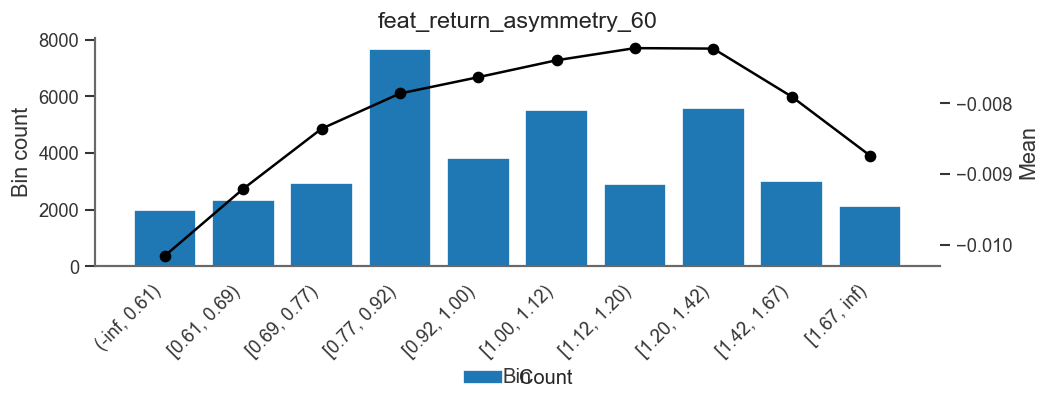



::: {.panel-tabset}


### feat_ichimoku_cloud_thickness


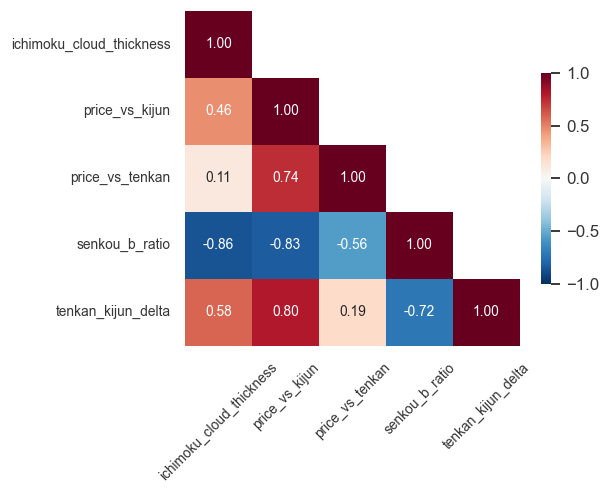




### feat_price_vs_kijun


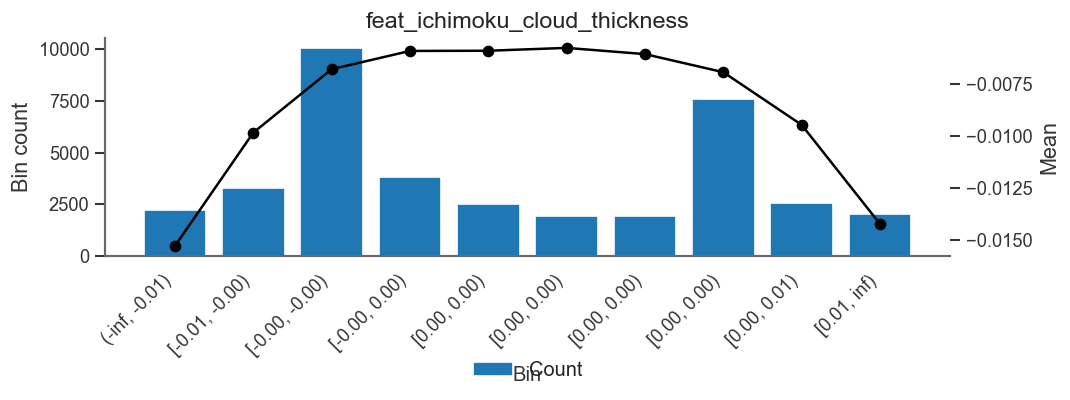




### feat_price_vs_tenkan


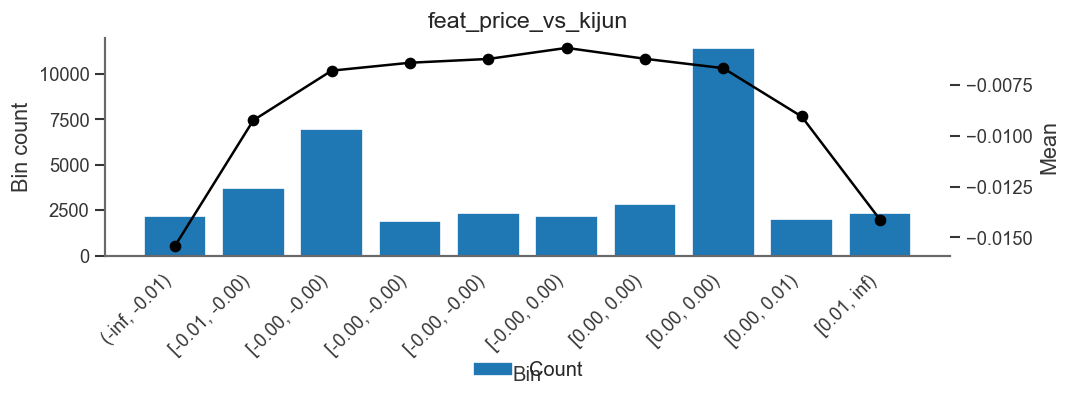




### feat_senkou_b_ratio


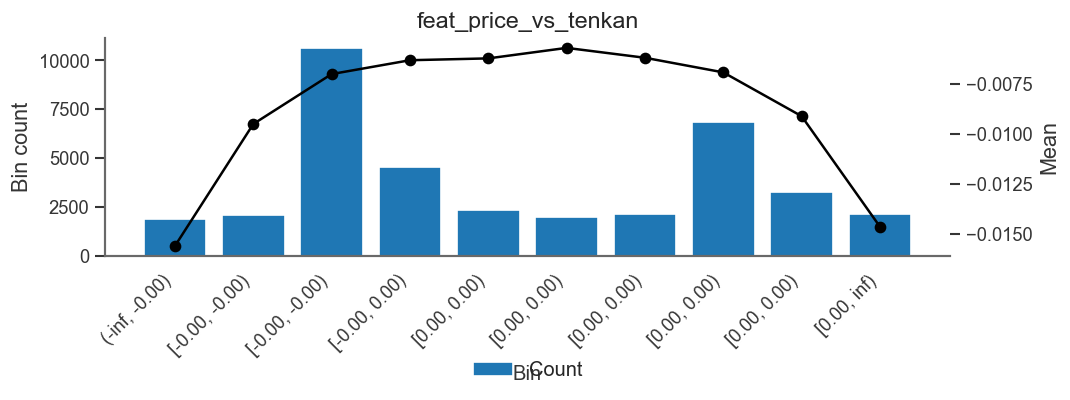




### feat_tenkan_kijun_delta


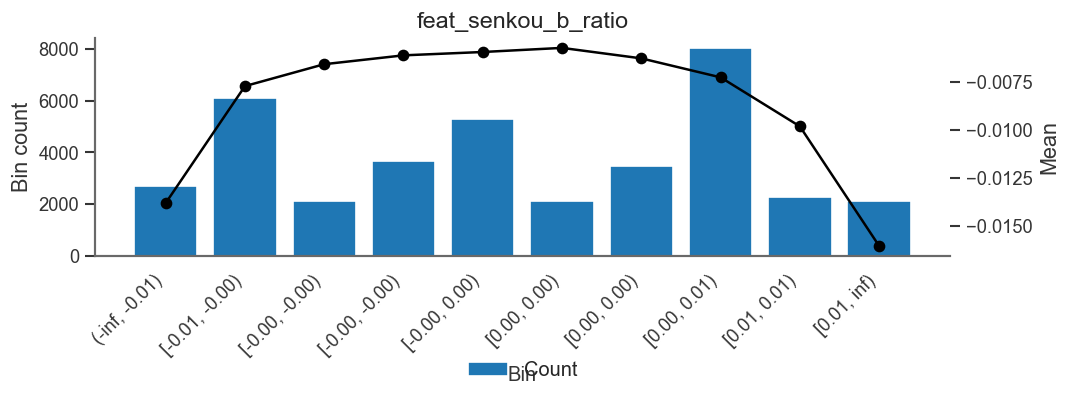



:::


## Donchian

<style type="text/css">
#T_2c497  {
  border-collapse: collapse;
  border: 1px solid black;
}
#T_2c497 th {
  border: 1px solid black;
  padding: 4px 8px;
  text-align: center;
}
#T_2c497 td {
  border: 1px solid black;
  padding: 4px 8px;
}
#T_2c497 thead th {
  border-bottom: 2px solid black;
}
#T_2c497_row0_col0, #T_2c497_row0_col4, #T_2c497_row1_col0, #T_2c497_row1_col4, #T_2c497_row2_col0, #T_2c497_row2_col4, #T_2c497_row3_col0, #T_2c497_row3_col4, #T_2c497_row4_col0, #T_2c497_row4_col4, #T_2c497_row5_col0, #T_2c497_row5_col4, #T_2c497_row6_col0, #T_2c497_row6_col4, #T_2c497_row7_col0, #T_2c497_row7_col4, #T_2c497_row8_col0, #T_2c497_row8_col4 {
  text-align: left;
}
#T_2c497_row0_col1, #T_2c497_row0_col2, #T_2c497_row0_col3, #T_2c497_row1_col1, #T_2c497_row1_col2, #T_2c497_row1_col3, #T_2c497_row2_col1, #T_2c497_row2_col2, #T_2c497_row2_col3, #T_2c497_row3_col1, #T_2c497_row3_col2, #T_2c497_row3_col3, #T_2c497_row4_col1, #T_2c497_row4_col2, #T_2c497_row4_col3
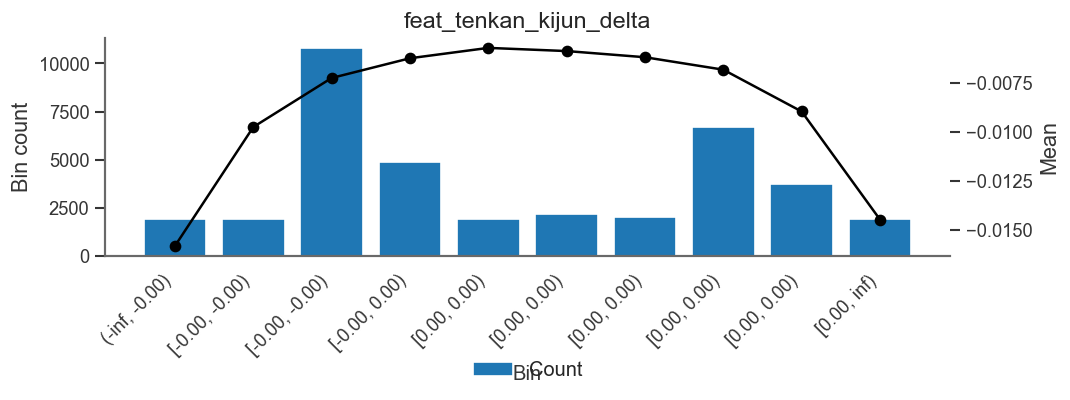



::: {.panel-tabset}


### feat_donchian_position_10


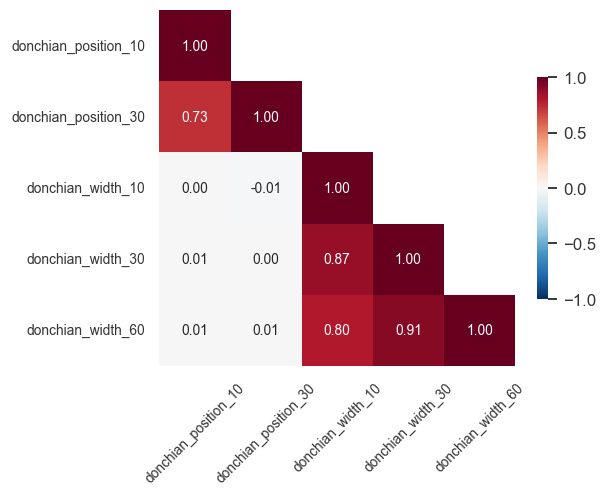




### feat_donchian_position_30


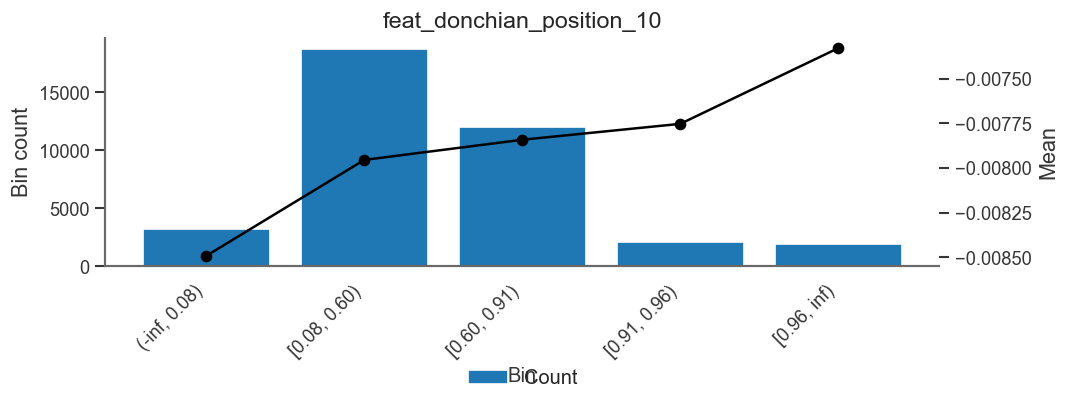




### feat_donchian_width_10


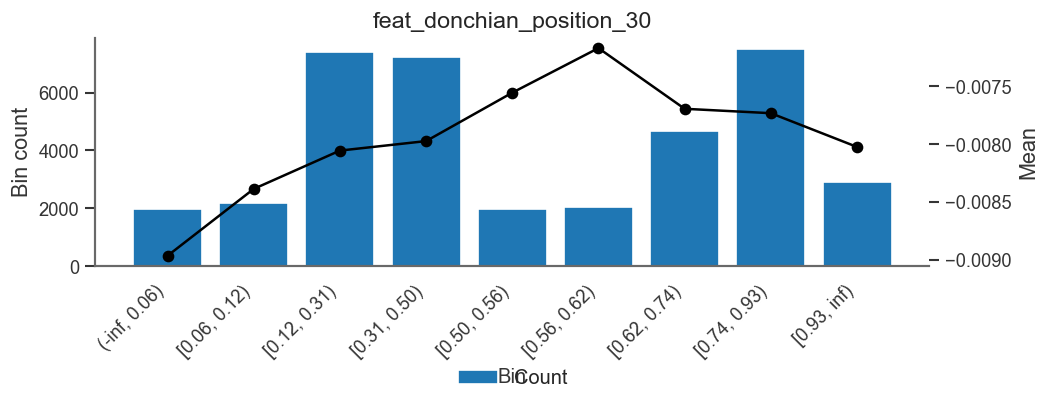




### feat_donchian_width_30


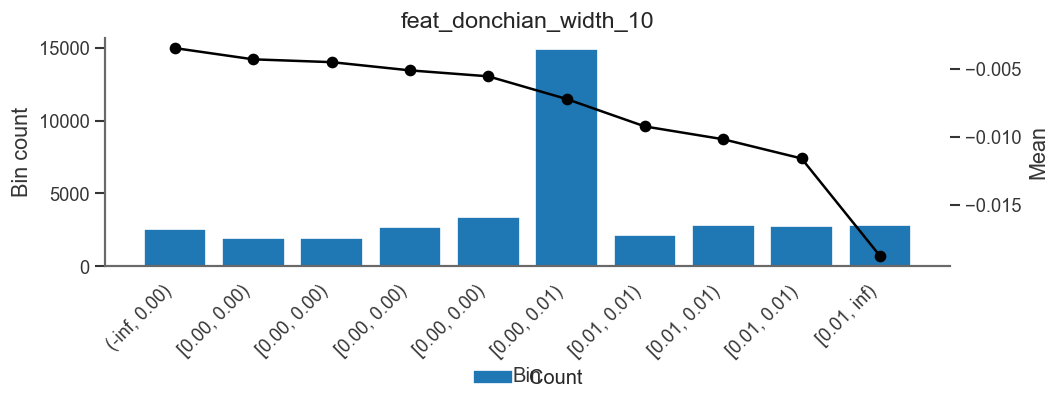




### feat_donchian_width_60


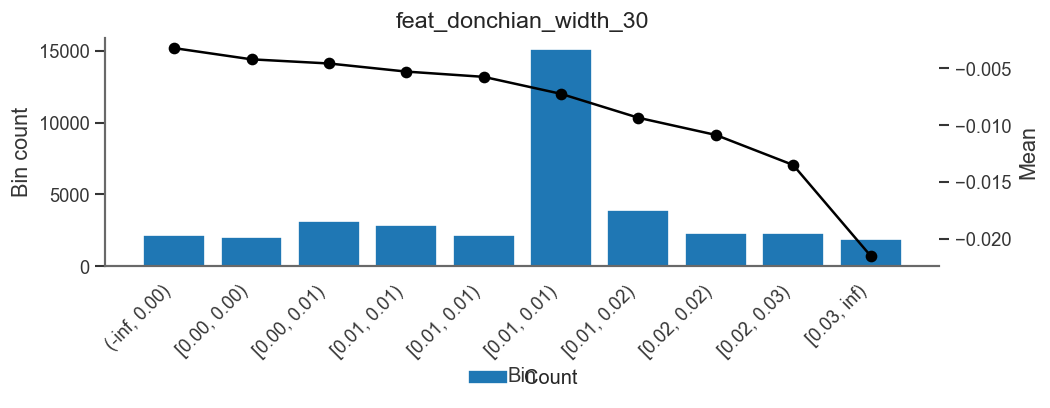



:::


## Trend Slope

<style type="text/css">
#T_c8bc3  {
  border-collapse: collapse;
  border: 1px solid black;
}
#T_c8bc3 th {
  border: 1px solid black;
  padding: 4px 8px;
  text-align: center;
}
#T_c8bc3 td {
  border: 1px solid black;
  padding: 4px 8px;
}
#T_c8bc3 thead th {
  border-bottom: 2px solid black;
}
#T_c8bc3_row0_col0, #T_c8bc3_row0_col4, #T_c8bc3_row1_col0, #T_c8bc3_row1_col4, #T_c8bc3_row2_col0, #T_c8bc3_row2_col4, #T_c8bc3_row3_col0, #T_c8bc3_row3_col4, #T_c8bc3_row4_col0, #T_c8bc3_row4_col4, #T_c8bc3_row5_col0, #T_c8bc3_row5_col4, #T_c8bc3_row6_col0, #T_c8bc3_row6_col4, #T_c8bc3_row7_col0, #T_c8bc3_row7_col4, #T_c8bc3_row8_col0, #T_c8bc3_row8_col4, #T_c8bc3_row9_col0, #T_c8bc3_row9_col4, #T_c8bc3_row10_col0, #T_c8bc3_row10_col4 {
  text-align: left;
}
#T_c8bc3_row0_col1, #T_c8bc3_row0_col2, #T_c8bc3_row0_col3, #T_c8bc3_row1_col1, #T_c8bc3_row1_col2, #T_c8bc3_row1_col3, #T_c8bc3_row2_col1, #T_c8bc3_row2_col2, #T_c8bc3_row2_col3, #T_c8bc3_row3_col1, #T_c8bc3_row3
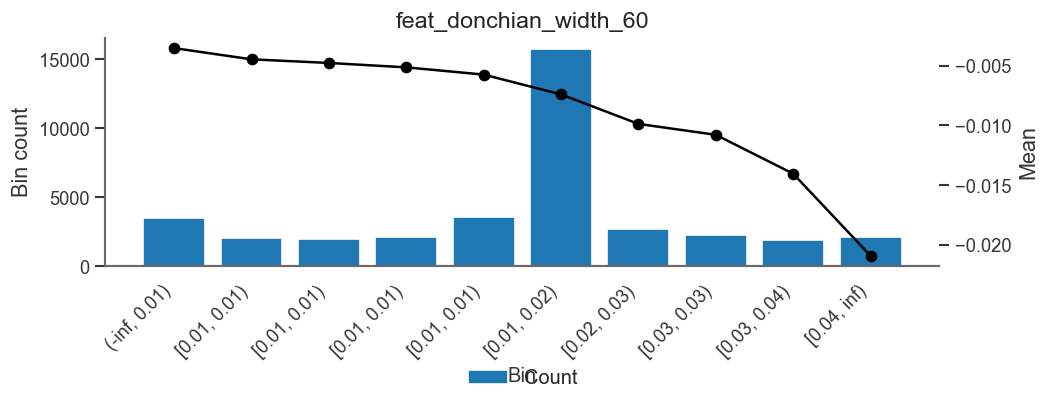



::: {.panel-tabset}


### feat_ema_slope_10


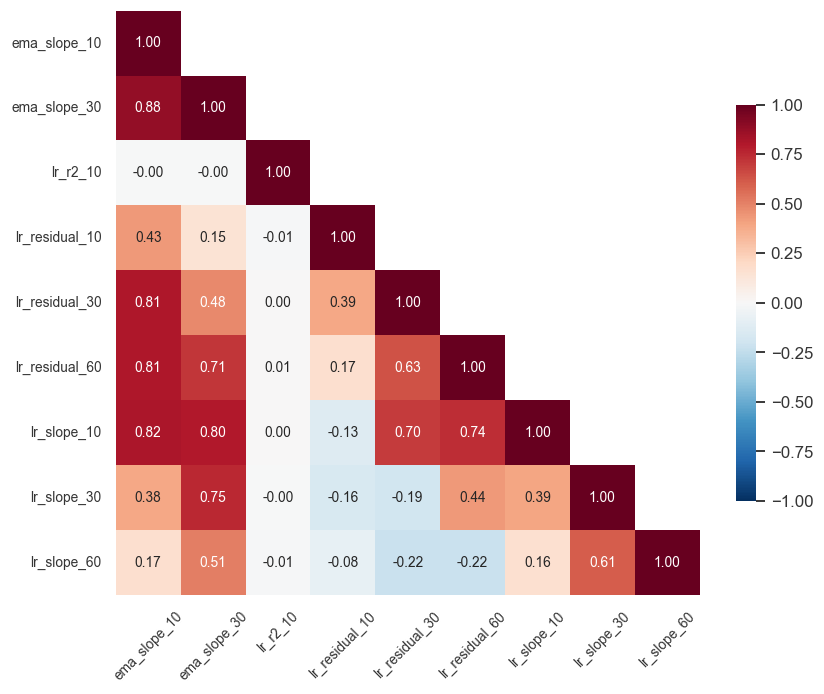




### feat_ema_slope_30


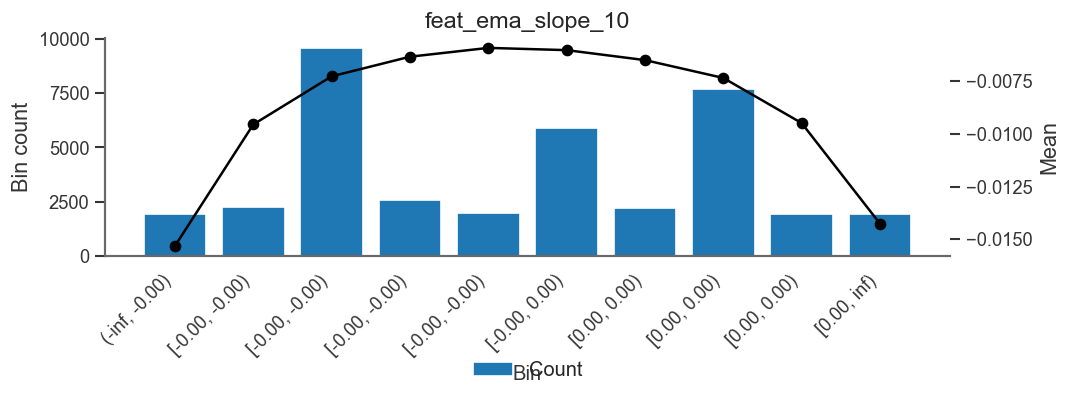




### feat_lr_r2_10


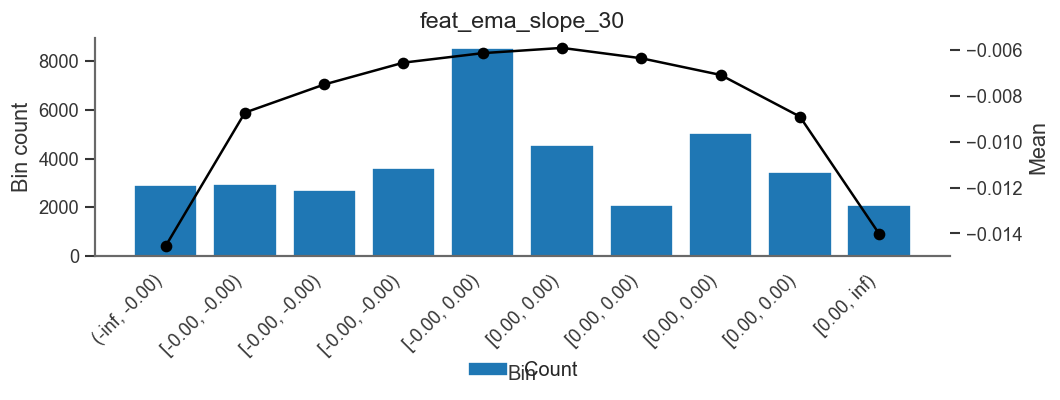




### feat_lr_residual_10


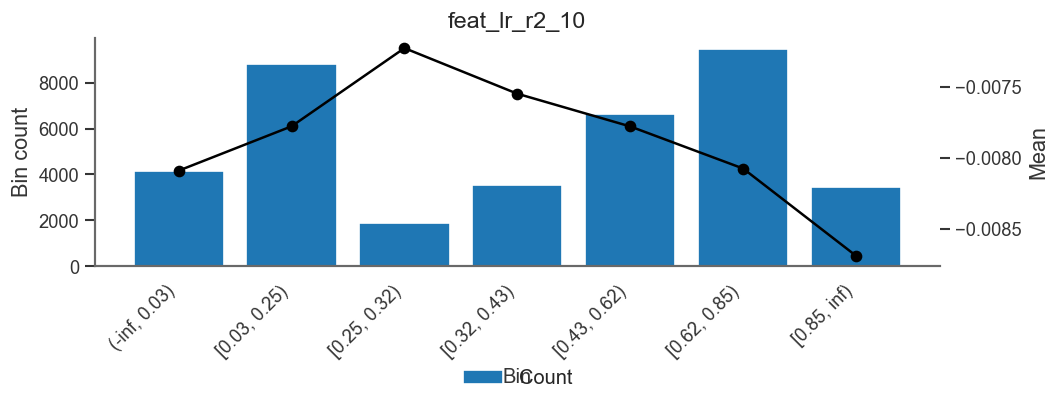




### feat_lr_residual_30


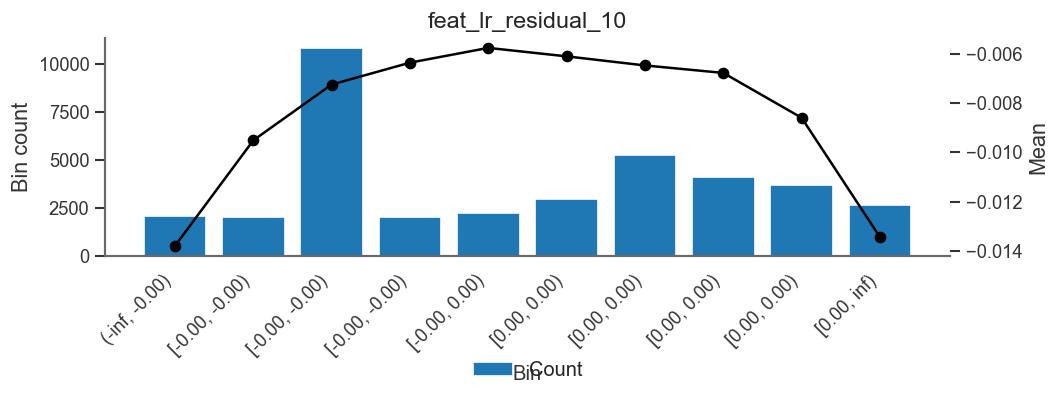




### feat_lr_residual_60


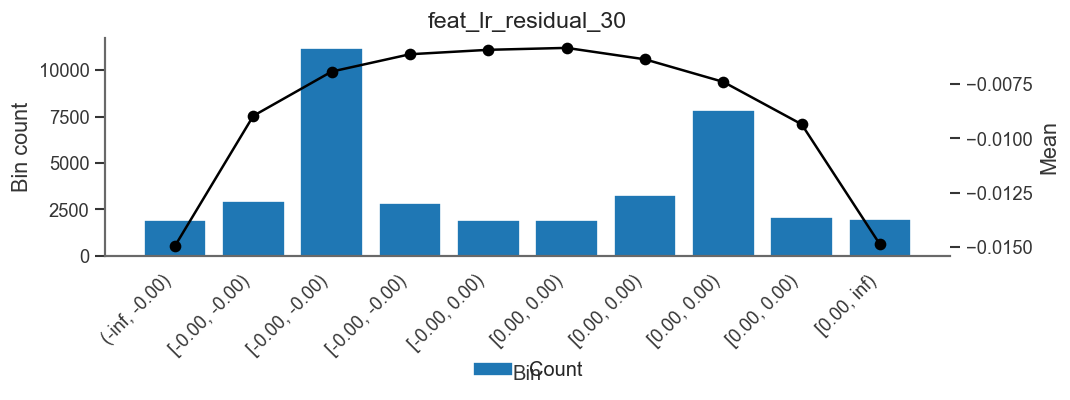




### feat_lr_slope_10


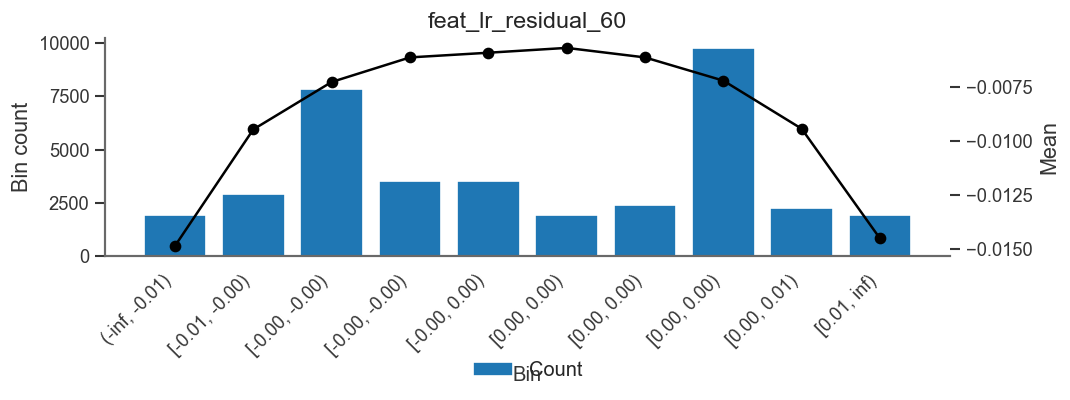




### feat_lr_slope_30


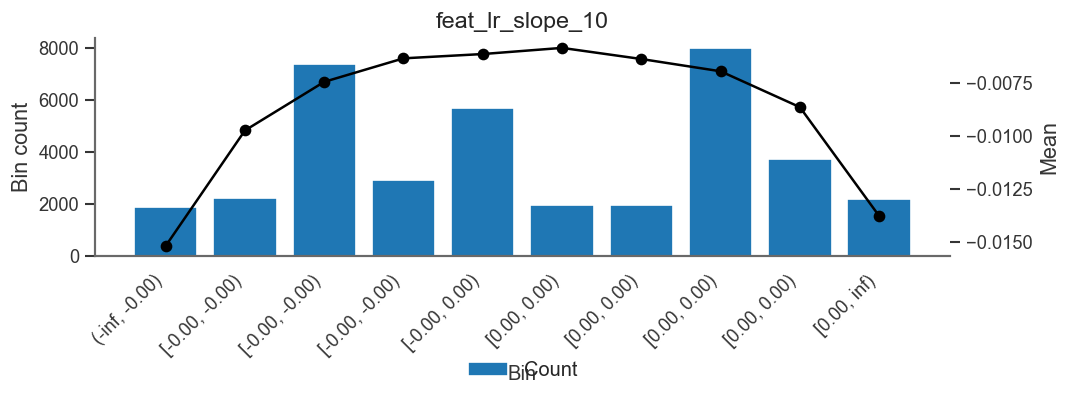




### feat_lr_slope_60


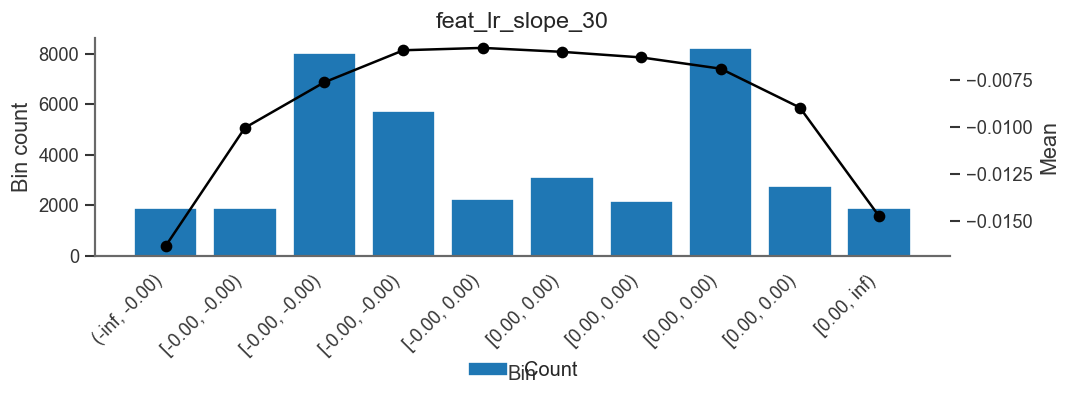



:::


## Accel

<style type="text/css">
#T_c5c73  {
  border-collapse: collapse;
  border: 1px solid black;
}
#T_c5c73 th {
  border: 1px solid black;
  padding: 4px 8px;
  text-align: center;
}
#T_c5c73 td {
  border: 1px solid black;
  padding: 4px 8px;
}
#T_c5c73 thead th {
  border-bottom: 2px solid black;
}
#T_c5c73_row0_col0, #T_c5c73_row0_col4, #T_c5c73_row1_col0, #T_c5c73_row1_col4, #T_c5c73_row2_col0, #T_c5c73_row2_col4, #T_c5c73_row3_col0, #T_c5c73_row3_col4, #T_c5c73_row4_col0, #T_c5c73_row4_col4, #T_c5c73_row5_col0, #T_c5c73_row5_col4, #T_c5c73_row6_col0, #T_c5c73_row6_col4, #T_c5c73_row7_col0, #T_c5c73_row7_col4 {
  text-align: left;
}
#T_c5c73_row0_col1, #T_c5c73_row0_col2, #T_c5c73_row0_col3, #T_c5c73_row1_col1, #T_c5c73_row1_col2, #T_c5c73_row1_col3, #T_c5c73_row2_col1, #T_c5c73_row2_col2, #T_c5c73_row2_col3, #T_c5c73_row3_col1, #T_c5c73_row3_col2, #T_c5c73_row3_col3, #T_c5c73_row4_col1, #T_c5c73_row4_col2, #T_c5c73_row4_col3, #T_c5c73_row5_col1, #T_c5c73_row5_col2, #
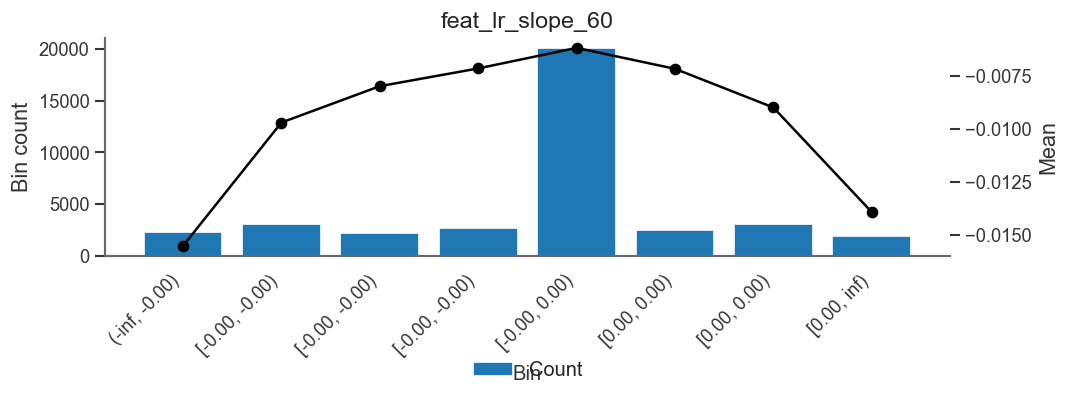



::: {.panel-tabset}


### feat_return_momentum_delta_10


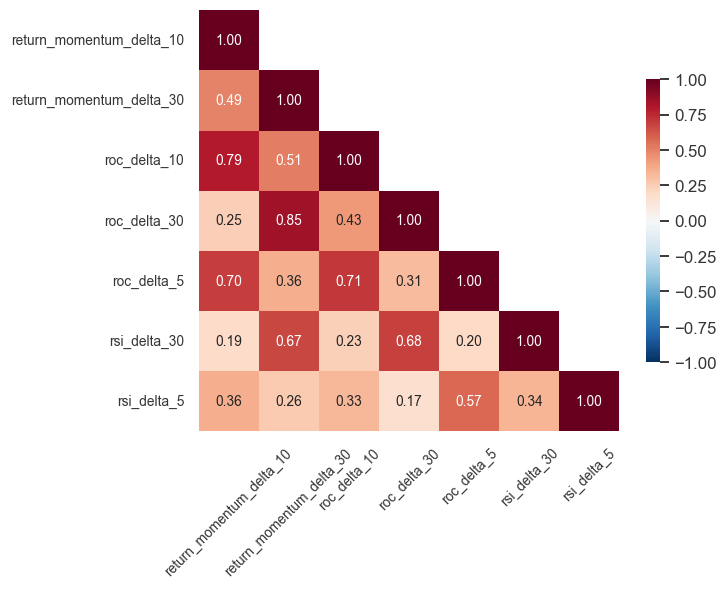




### feat_return_momentum_delta_30


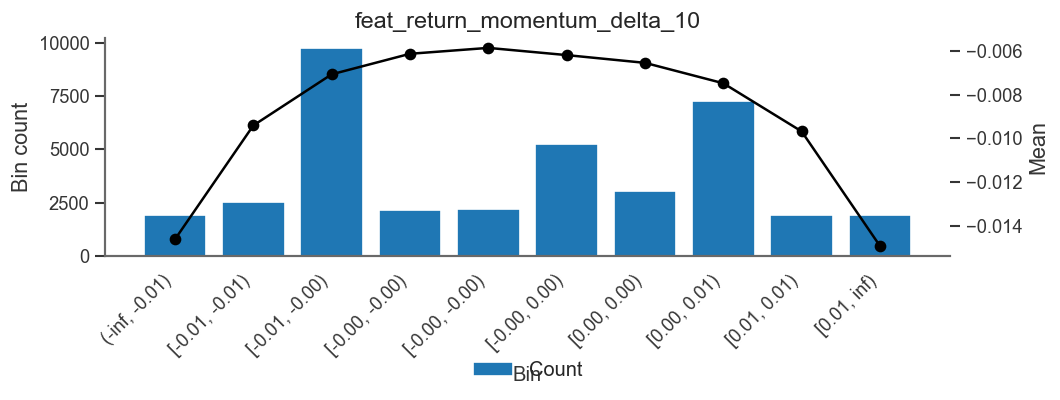




### feat_roc_delta_10


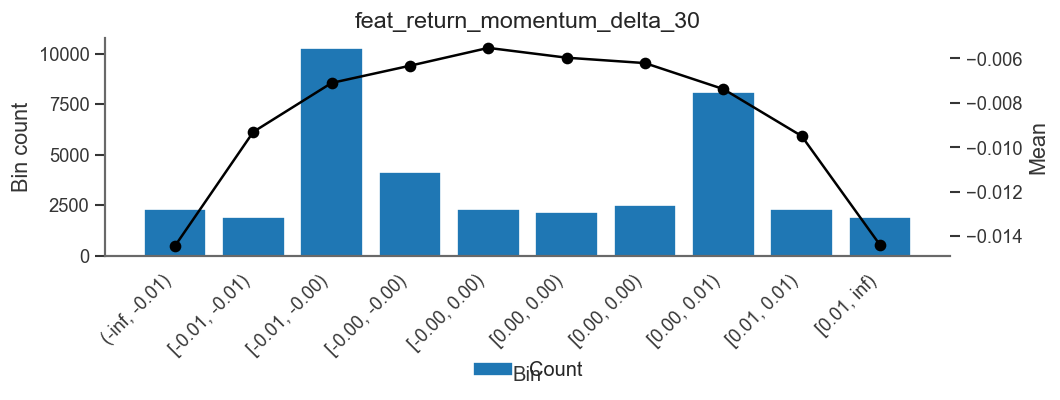




### feat_roc_delta_30


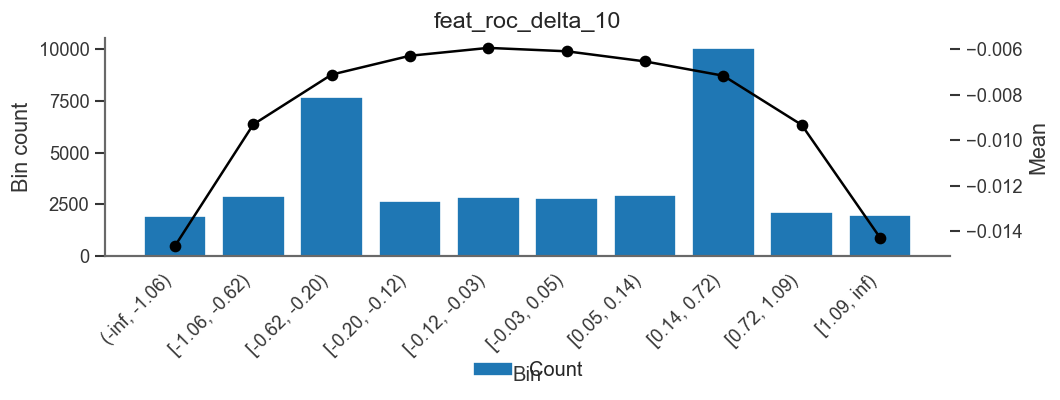




### feat_roc_delta_5


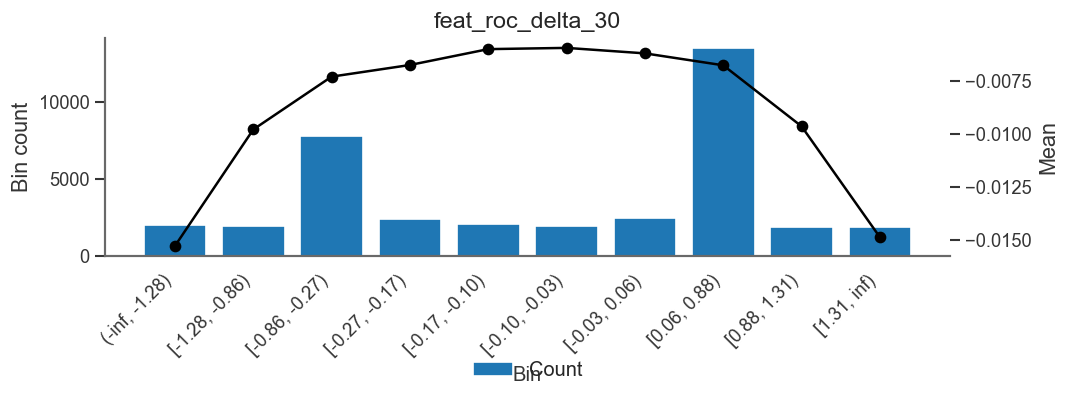




### feat_rsi_delta_30


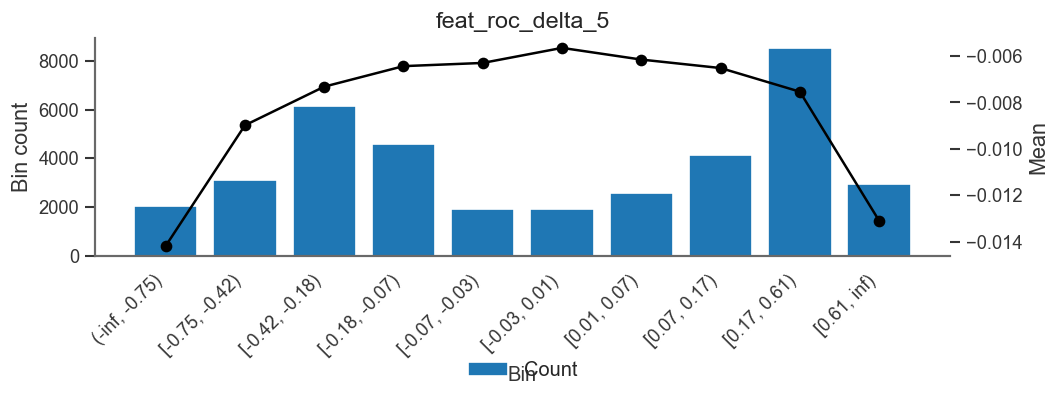




### feat_rsi_delta_5


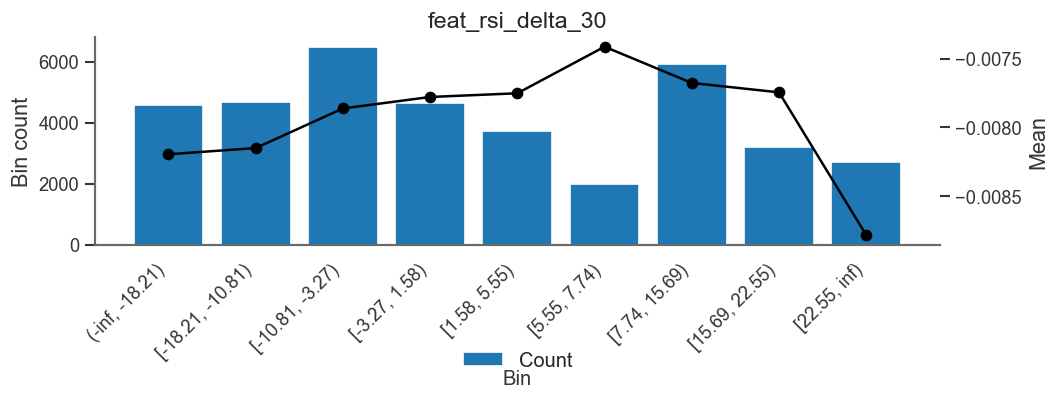



:::


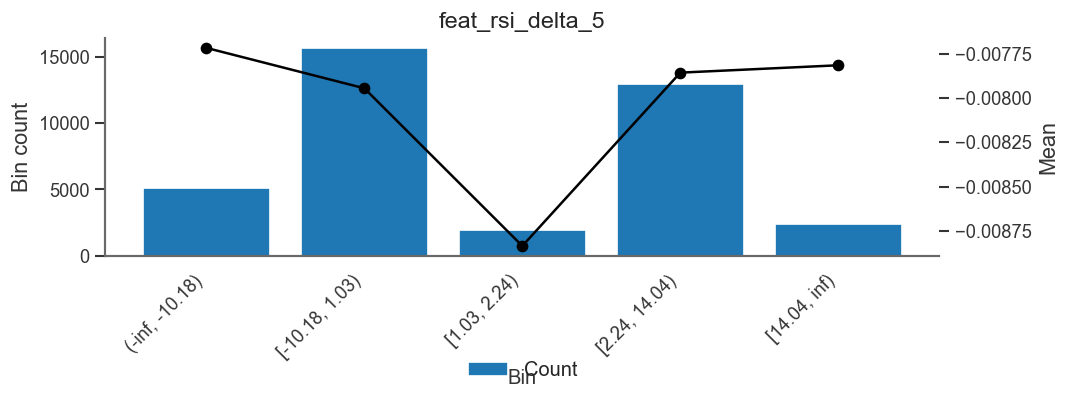

In [5]:
#| output: asis
#| echo: false
#| warning: false

TABSET_OPEN  = "::: {.panel-tabset}"
TABSET_CLOSE = ":::"

GROUP_ORDER = [
    "Price Action", "Volatility", "Volume", "Gap", "Candle Pattern",
    "Time/Session", "Taker Flow", "Momentum", "Trend", "Autocorrelation",
    "Market Structure", "Swing", "Tail Risk", "Ichimoku", "Donchian",
    "Trend Slope", "Accel",
]
_available = set(groups_df["Group"].unique())
_ordered_groups = [g for g in GROUP_ORDER if g in _available] + \
                  sorted(g for g in _available if g not in set(GROUP_ORDER))

MI_THRESHOLD   = 0.001
CORR_THRESHOLD = 0.98

_fs_selected = []
_fs_dropped_mi   = {}
_fs_dropped_corr = {}
_fs_dropped_qual = {f: 'quality: null/inf/variance' for f in feat_cols_quality_dropped}

for group in _ordered_groups:
    feats_in_group = sorted(groups_df[groups_df["Group"] == group]["Feature"].tolist())
    feats_mi_ok = [f for f in feats_in_group
                   if iv_results.get(f, {}).get("mi", 0) > MI_THRESHOLD]
    corr_dedup = {}
    if len(feats_mi_ok) >= 2:
        _cm = df_train[feats_mi_ok].corr().abs()
        _seen = set()
        for i, fa in enumerate(feats_mi_ok):
            if fa in _seen:
                continue
            for fb in feats_mi_ok[i+1:]:
                if fb in _seen:
                    continue
                if _cm.loc[fa, fb] >= CORR_THRESHOLD:
                    mi_a = iv_results.get(fa, {}).get("mi", 0)
                    mi_b = iv_results.get(fb, {}).get("mi", 0)
                    drop = fb if mi_a >= mi_b else fa
                    corr_dedup[drop] = fa if mi_a >= mi_b else fb
                    _seen.add(drop)
    feats_pass = [f for f in feats_mi_ok if f not in corr_dedup]
    for _f in feats_in_group:
        _mi_val = iv_results.get(_f, {}).get('mi', 0)
        if _mi_val != _mi_val or _mi_val <= MI_THRESHOLD:
            _fs_dropped_mi[_f] = f'mi <= {MI_THRESHOLD} (mi={_mi_val:.5f})'
        elif _f in corr_dedup:
            _fs_dropped_corr[_f] = f'duplikatum -> {corr_dedup[_f]}'
        else:
            _fs_selected.append(_f)

    def _dontes(f):
        mi_val = iv_results.get(f, {}).get("mi", float("nan"))
        if mi_val != mi_val or mi_val <= MI_THRESHOLD:
            return "✗ kizár (MI)"
        if f in corr_dedup:
            return f"✗ duplikátum → {corr_dedup[f].replace('feat_','')}"
        return ""

    print(f"\n## {group}\n")
    group_iv_rows = []
    for f in feats_in_group:
        res = iv_results.get(f, {})
        mi_val = res.get("mi", float("nan"))
        group_iv_rows.append({"Feature": f, "IV": round(res.get("iv", float("nan")), 5),
                               "MI": round(mi_val, 5), "N_bins": res.get("n_bins", 0), "Döntés": _dontes(f)})
    group_iv_df = (pd.DataFrame(group_iv_rows).sort_values("MI", ascending=False).reset_index(drop=True))
    print(analysis_table_html(group_iv_df))

    if len(feats_pass) >= 2:
        corr_data = df_train[feats_pass].corr()
        n = len(feats_pass)
        cell_sz = 0.55; margin = 2.0
        fig_h = max(4.0, n * cell_sz + margin)
        fig_w = max(5.0, n * cell_sz + margin + 1.0)
        lbl_sz = max(6, min(9, 90 // n)); ann_sz = max(6, min(9, 100 // n))
        mask = np.triu(np.ones_like(corr_data, dtype=bool), k=1)
        with plt.rc_context({"axes.grid": False}):
            fig_c, ax_c = plt.subplots(figsize=(fig_w, fig_h))
            sns.heatmap(corr_data, ax=ax_c, mask=mask, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
                        annot=(n <= 20), fmt=".2f", annot_kws={"size": ann_sz}, linewidths=0, square=True,
                        cbar_kws={"shrink": 0.6},
                        xticklabels=[f.replace("feat_", "") for f in feats_pass],
                        yticklabels=[f.replace("feat_", "") for f in feats_pass])
            ax_c.tick_params(axis="x", rotation=45, labelsize=lbl_sz)
            ax_c.tick_params(axis="y", rotation=0, labelsize=lbl_sz)
            fig_c.tight_layout()
        buf_c = io.BytesIO()
        fig_c.savefig(buf_c, format="png", dpi=110, bbox_inches="tight")
        plt.close(fig_c); buf_c.seek(0)
        img_c_b64 = base64.b64encode(buf_c.read()).decode("utf-8")
        print(f'<img src="data:image/png;base64,{img_c_b64}" style="max-width:900px; margin-bottom:1rem;"/>\n')

    if not feats_pass:
        print("*Minden feature kizárva — nincs megjeleníthető plot.*\n")
    else:
        print(TABSET_OPEN + "\n")
        for feat in feats_pass:
            print(f"\n### {feat}\n")
            res = iv_results.get(feat, {}); ob = res.get("ob")
            if ob is None:
                print("*Nem elégséges adat a binninghez.*\n"); continue
            _show_bak = plt.show; plt.show = lambda *a, **kw: None
            try:
                ob.binning_table.plot(add_special=False, add_missing=False, show_bin_labels=True, figsize=(9, 4))
                fig = plt.gcf()
                for ax in fig.get_axes(): ax.grid(False)
                fig.tight_layout()
            finally:
                plt.show = _show_bak
            buf = io.BytesIO()
            fig.savefig(buf, format="png", dpi=120, bbox_inches="tight")
            plt.close(fig); buf.seek(0)
            img_b64 = base64.b64encode(buf.read()).decode("utf-8")
            print(f'<img src="data:image/png;base64,{img_b64}" style="max-width:820px;"/>\n')
        print(TABSET_CLOSE + "\n")


## Összefoglaló — Feature szelekció eredménye

Csoport-bajnokok (legjobb MI), Top 10, és teljes kizárási lista MI szerint rendezve.


In [6]:
#| label: tbl-summary
#| echo: false

import pandas as _pd

_summary_rows = []
for _f in feat_cols:
    _mi = iv_results.get(_f, {}).get("mi", float("nan"))
    _iv = iv_results.get(_f, {}).get("iv", float("nan"))
    _grp = assign_group(_f)
    if _f in _fs_dropped_corr:
        _dec = f"duplikátum → {_fs_dropped_corr[_f].replace('feat_', '')}"
    elif _f in _fs_dropped_mi:
        _dec = f"MI ≤ {MI_THRESHOLD}"
    else:
        _dec = "✓ selected"
    _summary_rows.append({"feature": _f.replace("feat_", ""), "group": _grp,
                           "mi": _mi, "iv": _iv, "decision": _dec, "full_name": _f})
for _f in feat_cols_quality_dropped:
    _summary_rows.append({"feature": _f.replace("feat_", ""), "group": assign_group(_f),
                           "mi": float("nan"), "iv": float("nan"),
                           "decision": "quality: null/inf/variance", "full_name": _f})

summary_df = _pd.DataFrame(_summary_rows).sort_values("mi", ascending=False, na_position="last")
summary_df["mi_disp"] = summary_df["mi"].apply(lambda x: f"{x:.4f}" if x == x else "—")
summary_df["iv_disp"] = summary_df["iv"].apply(lambda x: f"{x:.5f}" if x == x else "—")
_sel_df = summary_df[summary_df["decision"] == "✓ selected"].copy()
top10_feats = _sel_df["full_name"].head(10).tolist()
_grp_best_name = {}; _grp_best_feat = {}
for _, _row in _sel_df.iterrows():
    _g = _row["group"]
    if _g not in _grp_best_feat:
        _grp_best_feat[_g] = _row["full_name"]
        _grp_best_name[_g] = _row["feature"]
top1_per_group_feats = list(_grp_best_feat.values())

_champ_rows = [f"| {_g} | {_fname} | {_sel_df[_sel_df['feature'] == _fname]['mi_disp'].values[0]} |"
               for _g, _fname in _grp_best_name.items()]
display(Markdown(
    f"### Csoport bajnokok ({len(_grp_best_feat)} csoport)\n\n"
    "| Csoport | Feature | MI |\n|---------|---------|-----|\n" + "\n".join(_champ_rows)
))
_top10_rows = [f"| {i+1} | {r['feature']} | {r['group']} | {r['mi_disp']} | {r['iv_disp']} |"
               for i, (_, r) in enumerate(_sel_df.head(10).iterrows())]
display(Markdown(
    "### Top 10 feature (MI szerint)\n\n"
    "| # | Feature | Csoport | MI | IV |\n|---|---------|---------|-----|-----|\n" + "\n".join(_top10_rows)
))
_all_rows = [f"| {r['feature']} | {r['group']} | {r['mi_disp']} | {r['iv_disp']} | {r['decision']} |"
             for _, r in summary_df.iterrows()]
display(Markdown(
    f"### Összes feature MI szerint rendezve ({len(summary_df)} db)\n\n"
    "| Feature | Csoport | MI | IV | Döntés |\n|---------|---------|-----|-----|--------|\n" + "\n".join(_all_rows)
))


### Csoport bajnokok (17 csoport)

| Csoport | Feature | MI |
|---------|---------|-----|
| Volatility | natr_14 | 0.1232 |
| Tail Risk | neg_return_mean_60 | 0.1070 |
| Donchian | donchian_width_30 | 0.1004 |
| Price Action | returns_std_14 | 0.1000 |
| Market Structure | max_drawdown_60 | 0.0989 |
| Momentum | roc_14 | 0.0566 |
| Trend | sma_ratio_140 | 0.0498 |
| Ichimoku | price_vs_kijun | 0.0467 |
| Trend Slope | ema_slope_30 | 0.0458 |
| Accel | roc_delta_30 | 0.0408 |
| Time/Session | day_open_return | 0.0396 |
| Volume | ad_line | 0.0334 |
| Taker Flow | taker_flow_confirmed_return_10 | 0.0330 |
| Candle Pattern | signed_body_ratio | 0.0224 |
| Gap | gap_open | 0.0151 |
| Autocorrelation | return_autocorr_lag1_30 | 0.0050 |
| Swing | swing_high_5 | 0.0029 |

### Top 10 feature (MI szerint)

| # | Feature | Csoport | MI | IV |
|---|---------|---------|-----|-----|
| 1 | natr_14 | Volatility | 0.1232 | 0.00295 |
| 2 | gk_vol_30 | Volatility | 0.1228 | 0.00298 |
| 3 | gk_vol_60 | Volatility | 0.1204 | 0.00286 |
| 4 | parkinson_vol_10 | Volatility | 0.1136 | 0.00298 |
| 5 | hist_vol_20 | Volatility | 0.1111 | 0.00273 |
| 6 | neg_return_mean_60 | Tail Risk | 0.1070 | 0.00295 |
| 7 | donchian_width_30 | Donchian | 0.1004 | 0.00269 |
| 8 | returns_std_14 | Price Action | 0.1000 | 0.00288 |
| 9 | max_drawdown_60 | Market Structure | 0.0989 | 0.00270 |
| 10 | pos_return_mean_60 | Tail Risk | 0.0988 | 0.00280 |

### Összes feature MI szerint rendezve (208 db)

| Feature | Csoport | MI | IV | Döntés |
|---------|---------|-----|-----|--------|
| natr_14 | Volatility | 0.1232 | 0.00295 | ✓ selected |
| gk_vol_30 | Volatility | 0.1228 | 0.00298 | ✓ selected |
| gk_vol_60 | Volatility | 0.1204 | 0.00286 | ✓ selected |
| parkinson_vol_60 | Volatility | 0.1156 | 0.00296 | duplikátum → duplikatum -> gk_vol_60 |
| parkinson_vol_10 | Volatility | 0.1136 | 0.00298 | ✓ selected |
| parkinson_vol_30 | Volatility | 0.1123 | 0.00294 | duplikátum → duplikatum -> gk_vol_30 |
| hist_vol_20 | Volatility | 0.1111 | 0.00273 | ✓ selected |
| gk_vol_10 | Volatility | 0.1104 | 0.00299 | duplikátum → duplikatum -> parkinson_vol_10 |
| neg_return_mean_60 | Tail Risk | 0.1070 | 0.00295 | ✓ selected |
| donchian_width_30 | Donchian | 0.1004 | 0.00269 | ✓ selected |
| returns_std_14 | Price Action | 0.1000 | 0.00288 | ✓ selected |
| max_drawdown_60 | Market Structure | 0.0989 | 0.00270 | ✓ selected |
| pos_return_mean_60 | Tail Risk | 0.0988 | 0.00280 | ✓ selected |
| donchian_width_60 | Donchian | 0.0980 | 0.00267 | ✓ selected |
| pos_return_mean_30 | Tail Risk | 0.0933 | 0.00265 | ✓ selected |
| donchian_width_10 | Donchian | 0.0903 | 0.00265 | ✓ selected |
| neg_return_mean_30 | Tail Risk | 0.0898 | 0.00285 | ✓ selected |
| hml_range | Price Action | 0.0883 | 0.00233 | ✓ selected |
| ohlc_range | Price Action | 0.0877 | 0.00231 | duplikátum → duplikatum -> hml_range |
| max_drawdown_30 | Market Structure | 0.0834 | 0.00273 | ✓ selected |
| max_drawdown_10 | Market Structure | 0.0810 | 0.00242 | ✓ selected |
| bb_width_140 | Volatility | 0.0730 | 0.00250 | ✓ selected |
| bb_width_14 | Volatility | 0.0721 | 0.00260 | ✓ selected |
| pos_return_mean_10 | Tail Risk | 0.0675 | 0.00209 | ✓ selected |
| neg_return_mean_10 | Tail Risk | 0.0658 | 0.00226 | ✓ selected |
| returns_sma_14 | Price Action | 0.0566 | 0.00185 | ✓ selected |
| roc_14 | Momentum | 0.0566 | 0.00185 | ✓ selected |
| dist_rolling_low_10 | Market Structure | 0.0524 | 0.00176 | ✓ selected |
| sma_ratio_140 | Trend | 0.0498 | 0.00203 | ✓ selected |
| dist_rolling_high_60 | Market Structure | 0.0484 | 0.00211 | ✓ selected |
| dist_rolling_high_30 | Market Structure | 0.0473 | 0.00200 | ✓ selected |
| price_vs_kijun | Ichimoku | 0.0467 | 0.00201 | ✓ selected |
| kijun_ratio | Ichimoku | 0.0467 | 0.00201 | duplikátum → duplikatum -> price_vs_kijun |
| ema_ratio_140 | Trend | 0.0460 | 0.00201 | duplikátum → duplikatum -> sma_ratio_140 |
| ema_slope_30 | Trend Slope | 0.0458 | 0.00199 | ✓ selected |
| roc_140 | Momentum | 0.0454 | 0.00196 | ✓ selected |
| senkou_b_ratio | Ichimoku | 0.0445 | 0.00197 | ✓ selected |
| return_30 | Price Action | 0.0445 | 0.00185 | ✓ selected |
| price_vs_tenkan | Ichimoku | 0.0437 | 0.00190 | ✓ selected |
| tenkan_ratio | Ichimoku | 0.0437 | 0.00190 | duplikátum → duplikatum -> price_vs_tenkan |
| dist_rolling_low_30 | Market Structure | 0.0435 | 0.00180 | ✓ selected |
| lr_slope_60 | Trend Slope | 0.0435 | 0.00203 | ✓ selected |
| lr_residual_60 | Trend Slope | 0.0432 | 0.00179 | ✓ selected |
| returns_log | Price Action | 0.0432 | 0.00180 | ✓ selected |
| kama_ratio_10_2_30 | Trend | 0.0431 | 0.00195 | ✓ selected |
| dist_rolling_high_10 | Market Structure | 0.0426 | 0.00187 | ✓ selected |
| return_60 | Price Action | 0.0415 | 0.00207 | ✓ selected |
| lr_slope_10 | Trend Slope | 0.0410 | 0.00176 | ✓ selected |
| roc_delta_30 | Accel | 0.0408 | 0.00184 | ✓ selected |
| return_10 | Price Action | 0.0407 | 0.00183 | ✓ selected |
| lr_residual_30 | Trend Slope | 0.0406 | 0.00176 | ✓ selected |
| dist_rolling_low_60 | Market Structure | 0.0406 | 0.00181 | ✓ selected |
| ema_ratio_14 | Trend | 0.0397 | 0.00185 | ✓ selected |
| day_open_return | Time/Session | 0.0396 | 0.00193 | ✓ selected |
| sma_ratio_14 | Trend | 0.0389 | 0.00171 | duplikátum → duplikatum -> ema_ratio_14 |
| rolling_drawdown_30 | Market Structure | 0.0373 | 0.00184 | duplikátum → duplikatum -> dist_rolling_high_30 |
| roc_delta_5 | Accel | 0.0372 | 0.00166 | ✓ selected |
| ichimoku_cloud_thickness | Ichimoku | 0.0370 | 0.00206 | ✓ selected |
| return_momentum_delta_30 | Accel | 0.0367 | 0.00177 | ✓ selected |
| tenkan_kijun_delta | Ichimoku | 0.0366 | 0.00184 | ✓ selected |
| lr_slope_30 | Trend Slope | 0.0365 | 0.00189 | ✓ selected |
| rolling_drawdown_60 | Market Structure | 0.0362 | 0.00199 | duplikátum → duplikatum -> dist_rolling_high_60 |
| rolling_drawdown_10 | Market Structure | 0.0357 | 0.00150 | ✓ selected |
| atr_14 | Volatility | 0.0357 | 0.00132 | ✓ selected |
| ema_slope_10 | Trend Slope | 0.0355 | 0.00175 | ✓ selected |
| wma_ratio_14 | Trend | 0.0339 | 0.00178 | ✓ selected |
| ad_line | Volume | 0.0334 | 0.00053 | ✓ selected |
| taker_flow_confirmed_return_10 | Taker Flow | 0.0330 | 0.00176 | ✓ selected |
| roc_delta_10 | Accel | 0.0328 | 0.00173 | ✓ selected |
| return_momentum_delta_10 | Accel | 0.0323 | 0.00175 | ✓ selected |
| lr_residual_10 | Trend Slope | 0.0317 | 0.00173 | ✓ selected |
| volume_sma_14 | Volume | 0.0288 | 0.00154 | ✓ selected |
| weekly_open_return | Time/Session | 0.0245 | 0.00151 | ✓ selected |
| taker_flow_confirmed_return_30 | Taker Flow | 0.0230 | 0.00176 | duplikátum → duplikatum -> taker_flow_confirmed_return_10 |
| signed_body_ratio | Candle Pattern | 0.0224 | 0.00030 | ✓ selected |
| macd_signal_12_26_9 | Trend | 0.0216 | 0.00107 | ✓ selected |
| obv | Volume | 0.0198 | 0.00050 | ✓ selected |
| volume_confirmed_return_10 | Volume | 0.0192 | 0.00124 | ✓ selected |
| volume_confirmed_return_30 | Volume | 0.0180 | 0.00129 | ✓ selected |
| macd_diff | Trend | 0.0169 | 0.00099 | ✓ selected |
| macd_12_26 | Trend | 0.0169 | 0.00116 | ✓ selected |
| gap_open | Gap | 0.0151 | 0.00108 | ✓ selected |
| body_ratio | Candle Pattern | 0.0147 | 0.00027 | ✓ selected |
| williams_r_14 | Momentum | 0.0108 | 0.00010 | ✓ selected |
| stoch_k_14 | Momentum | 0.0107 | 0.00010 | duplikátum → duplikatum -> williams_r_14 |
| body_ratio_sma_30 | Candle Pattern | 0.0106 | 0.00080 | ✓ selected |
| atr_dist_low_30 | Market Structure | 0.0102 | 0.00028 | ✓ selected |
| hour_sin | Time/Session | 0.0097 | 0.00080 | ✓ selected |
| close_position | Price Action | 0.0092 | 0.00045 | ✓ selected |
| taker_buy_quote_ratio_10 | Taker Flow | 0.0091 | 0.00062 | ✓ selected |
| donchian_position_10 | Donchian | 0.0083 | 0.00013 | ✓ selected |
| adx_pos_14 | Trend | 0.0083 | 0.00048 | ✓ selected |
| recovery_ratio_10 | Market Structure | 0.0081 | 0.00014 | ✓ selected |
| taker_buy_base_ratio_10 | Taker Flow | 0.0080 | 0.00061 | duplikátum → duplikatum -> taker_buy_quote_ratio_10 |
| day_range_position | Time/Session | 0.0078 | 0.00056 | ✓ selected |
| donchian_position_30 | Donchian | 0.0078 | 0.00025 | ✓ selected |
| bb_width_rank_60 | Volatility | 0.0077 | 0.00013 | ✓ selected |
| wick_imbalance_sma_10 | Candle Pattern | 0.0076 | 0.00017 | ✓ selected |
| quote_volume_rank_10 | Taker Flow | 0.0075 | 0.00005 | ✓ selected |
| time_since_low_60 | Market Structure | 0.0075 | 0.00033 | ✓ selected |
| weekend | Time/Session | 0.0073 | 0.00062 | ✓ selected |
| trade_count_rank_30 | Taker Flow | 0.0069 | 0.00010 | ✓ selected |
| prev_session_high_dist | Market Structure | 0.0066 | 0.00032 | ✓ selected |
| volume_rank_10 | Volume | 0.0064 | 0.00006 | ✓ selected |
| dayofweek_sin | Time/Session | 0.0059 | 0.00050 | ✓ selected |
| efficiency_ratio_10 | Market Structure | 0.0058 | 0.00017 | ✓ selected |
| lower_wick_ratio | Candle Pattern | 0.0057 | 0.00061 | ✓ selected |
| rsi_14 | Momentum | 0.0056 | 0.00040 | ✓ selected |
| return_asymmetry_30 | Tail Risk | 0.0055 | 0.00051 | ✓ selected |
| adx_neg_14 | Trend | 0.0053 | 0.00026 | ✓ selected |
| upper_wick_ratio | Candle Pattern | 0.0053 | 0.00049 | ✓ selected |
| bb_position_140 | Volatility | 0.0051 | 0.00065 | ✓ selected |
| adx_14 | Trend | 0.0051 | 0.00039 | ✓ selected |
| bars_into_session_norm | Time/Session | 0.0051 | 0.00070 | ✓ selected |
| return_autocorr_lag1_30 | Autocorrelation | 0.0050 | 0.00027 | ✓ selected |
| return_autocorr_lag1_60 | Autocorrelation | 0.0050 | 0.00037 | ✓ selected |
| body_ratio_sma_10 | Candle Pattern | 0.0046 | 0.00061 | ✓ selected |
| cmf_20 | Volume | 0.0045 | 0.00016 | ✓ selected |
| obv_roc_14 | Volume | 0.0045 | 0.00088 | ✓ selected |
| volume_ratio_14 | Volume | 0.0044 | 0.00036 | ✓ selected |
| recovery_ratio_60 | Market Structure | 0.0043 | 0.00033 | ✓ selected |
| rsi_delta_30 | Accel | 0.0038 | 0.00025 | ✓ selected |
| lr_r2_10 | Trend Slope | 0.0037 | 0.00025 | ✓ selected |
| bb_position_14 | Volatility | 0.0037 | 0.00015 | ✓ selected |
| atr_dist_low_60 | Market Structure | 0.0036 | 0.00029 | ✓ selected |
| time_since_high_10 | Market Structure | 0.0033 | 0.00008 | ✓ selected |
| trade_count_rank_10 | Taker Flow | 0.0032 | 0.00011 | ✓ selected |
| bull_bars_ratio_30 | Candle Pattern | 0.0032 | 0.00016 | ✓ selected |
| taker_buy_base_ratio_30 | Taker Flow | 0.0029 | 0.00052 | ✓ selected |
| swing_high_5 | Swing | 0.0029 | 0.00015 | ✓ selected |
| hist_vol_rank_60 | Volatility | 0.0025 | 0.00028 | ✓ selected |
| taker_buy_quote_ratio_30 | Taker Flow | 0.0024 | 0.00051 | duplikátum → duplikatum -> taker_buy_base_ratio_30 |
| time_since_low_10 | Market Structure | 0.0024 | 0.00012 | ✓ selected |
| cci_20 | Momentum | 0.0023 | 0.00018 | ✓ selected |
| quote_volume_ratio_60 | Taker Flow | 0.0023 | 0.00036 | ✓ selected |
| signed_body_sma_30 | Candle Pattern | 0.0022 | 0.00040 | ✓ selected |
| mfi_14 | Volume | 0.0021 | 0.00014 | ✓ selected |
| hour_cos | Time/Session | 0.0021 | 0.00048 | ✓ selected |
| lower_low_count_5 | Swing | 0.0020 | 0.00019 | ✓ selected |
| avg_trade_quote_30 | Taker Flow | 0.0019 | 0.00057 | ✓ selected |
| time_since_high_60 | Market Structure | 0.0019 | 0.00038 | ✓ selected |
| quote_volume_ratio_30 | Taker Flow | 0.0018 | 0.00030 | ✓ selected |
| rsi_delta_5 | Accel | 0.0016 | 0.00011 | ✓ selected |
| stoch_d_14 | Momentum | 0.0015 | 0.00013 | ✓ selected |
| quote_volume_rank_30 | Taker Flow | 0.0015 | 0.00010 | ✓ selected |
| bull_bars_ratio_60 | Candle Pattern | 0.0015 | 0.00014 | ✓ selected |
| efficiency_ratio_30 | Market Structure | 0.0015 | 0.00036 | ✓ selected |
| return_autocorr_lag5_60 | Autocorrelation | 0.0015 | 0.00012 | ✓ selected |
| return_asymmetry_60 | Tail Risk | 0.0012 | 0.00055 | ✓ selected |
| range_expansion_10_30 | Market Structure | 0.0012 | 0.00021 | ✓ selected |
| higher_high_count_5 | Swing | 0.0012 | 0.00007 | ✓ selected |
| engulf_bull | Candle Pattern | 0.0011 | 0.00000 | ✓ selected |
| trade_count_ratio_30 | Taker Flow | 0.0009 | 0.00015 | MI ≤ 0.001 |
| lr_r2_30 | Trend Slope | 0.0009 | 0.00026 | MI ≤ 0.001 |
| inside_bar | Candle Pattern | 0.0008 | 0.00009 | MI ≤ 0.001 |
| rsi_delta_10 | Accel | 0.0006 | 0.00009 | MI ≤ 0.001 |
| shooting_star | Candle Pattern | 0.0005 | 0.00000 | MI ≤ 0.001 |
| directional_agreement_10_30 | Swing | 0.0005 | 0.00016 | MI ≤ 0.001 |
| trade_count_accel_10_30 | Taker Flow | 0.0003 | 0.00018 | MI ≤ 0.001 |
| return_asymmetry_10 | Tail Risk | 0.0002 | 0.00021 | MI ≤ 0.001 |
| donchian_breakout_10 | Donchian | 0.0002 | 0.00000 | MI ≤ 0.001 |
| quote_volume_ratio_10 | Taker Flow | 0.0001 | 0.00036 | MI ≤ 0.001 |
| signed_body_sma_10 | Candle Pattern | 0.0000 | 0.00015 | MI ≤ 0.001 |
| lower_high_count_5 | Swing | 0.0000 | 0.00028 | MI ≤ 0.001 |
| efficiency_ratio_60 | Market Structure | 0.0000 | 0.00047 | MI ≤ 0.001 |
| return_z_30 | Price Action | 0.0000 | 0.00016 | MI ≤ 0.001 |
| trade_count_ratio_60 | Taker Flow | 0.0000 | 0.00025 | MI ≤ 0.001 |
| trade_count_ratio_10 | Taker Flow | 0.0000 | 0.00009 | MI ≤ 0.001 |
| returns_kurt_14 | Price Action | 0.0000 | 0.00015 | MI ≤ 0.001 |
| higher_low_count_5 | Swing | 0.0000 | 0.00015 | MI ≤ 0.001 |
| returns_skew_14 | Price Action | 0.0000 | 0.00011 | MI ≤ 0.001 |
| return_z_60 | Price Action | 0.0000 | 0.00016 | MI ≤ 0.001 |
| swing_low_5 | Swing | 0.0000 | 0.00011 | MI ≤ 0.001 |
| return_z_10 | Price Action | 0.0000 | 0.00016 | MI ≤ 0.001 |
| bb_width_rank_20 | Volatility | 0.0000 | 0.00008 | MI ≤ 0.001 |
| hist_vol_rank_20 | Volatility | 0.0000 | 0.00014 | MI ≤ 0.001 |
| natr_rank_60 | Volatility | 0.0000 | 0.00039 | MI ≤ 0.001 |
| natr_rank_20 | Volatility | 0.0000 | 0.00028 | MI ≤ 0.001 |
| variance_ratio_10_60 | Autocorrelation | 0.0000 | 0.00024 | MI ≤ 0.001 |
| recovery_ratio_30 | Market Structure | 0.0000 | 0.00028 | MI ≤ 0.001 |
| session_asia | Time/Session | 0.0000 | 0.00041 | MI ≤ 0.001 |
| return_autocorr_lag5_30 | Autocorrelation | 0.0000 | 0.00015 | MI ≤ 0.001 |
| session_us | Time/Session | 0.0000 | 0.00060 | MI ≤ 0.001 |
| session_europe | Time/Session | 0.0000 | 0.00014 | MI ≤ 0.001 |
| dayofweek_cos | Time/Session | 0.0000 | 0.00050 | MI ≤ 0.001 |
| volume_rank_30 | Volume | 0.0000 | 0.00010 | MI ≤ 0.001 |
| volume_accel_10_30 | Volume | 0.0000 | 0.00020 | MI ≤ 0.001 |
| wick_imbalance_sma_30 | Candle Pattern | 0.0000 | 0.00013 | MI ≤ 0.001 |
| vol_adj_return_30 | Price Action | 0.0000 | 0.00016 | MI ≤ 0.001 |
| vol_adj_return_10 | Price Action | 0.0000 | 0.00016 | MI ≤ 0.001 |
| hammer | Candle Pattern | 0.0000 | 0.00000 | MI ≤ 0.001 |
| doji | Candle Pattern | 0.0000 | 0.00000 | MI ≤ 0.001 |
| time_since_high_30 | Market Structure | 0.0000 | 0.00026 | MI ≤ 0.001 |
| time_since_low_30 | Market Structure | 0.0000 | 0.00023 | MI ≤ 0.001 |
| engulf_bear | Candle Pattern | 0.0000 | 0.00000 | MI ≤ 0.001 |
| atr_dist_high_10 | Market Structure | 0.0000 | 0.00008 | MI ≤ 0.001 |
| atr_dist_low_10 | Market Structure | 0.0000 | 0.00017 | MI ≤ 0.001 |
| atr_dist_high_30 | Market Structure | 0.0000 | 0.00021 | MI ≤ 0.001 |
| prev_session_low_dist | Market Structure | 0.0000 | 0.00079 | MI ≤ 0.001 |
| atr_dist_high_60 | Market Structure | 0.0000 | 0.00033 | MI ≤ 0.001 |
| outside_bar | Candle Pattern | 0.0000 | 0.00003 | MI ≤ 0.001 |
| bull_bars_ratio_10 | Candle Pattern | 0.0000 | 0.00009 | MI ≤ 0.001 |
| donchian_breakout_30 | Donchian | 0.0000 | 0.00000 | MI ≤ 0.001 |
| donchian_breakout_60 | Donchian | 0.0000 | 0.00000 | MI ≤ 0.001 |
| donchian_position_60 | Donchian | 0.0000 | 0.00035 | MI ≤ 0.001 |
| lr_r2_60 | Trend Slope | 0.0000 | 0.00027 | MI ≤ 0.001 |
| gap_open_abs_sma_10 | Gap | — | — | quality: null/inf/variance |
| gap_open_abs_sma_30 | Gap | — | — | quality: null/inf/variance |

In [7]:
#| label: tbl-output-summary
#| echo: false

import json as _json
from datetime import datetime as _dt

_created_at = _dt.now().strftime('%Y-%m-%d %H:%M:%S')
_run_id     = _dt.now().strftime('run_%Y%m%d_%H%M%S')
_all_dropped = []
for _f, _r in _fs_dropped_qual.items(): _all_dropped.append({'col': _f, 'reason': _r})
for _f, _r in _fs_dropped_mi.items():
    if _f not in _fs_dropped_qual: _all_dropped.append({'col': _f, 'reason': _r})
for _f, _r in _fs_dropped_corr.items(): _all_dropped.append({'col': _f, 'reason': _r})
_asset_id   = MODEL_ID.split('_')[1] if len(MODEL_ID.split('_')) > 1 else 'solusdt'
_direction  = MODEL_ID.split('_')[2] if len(MODEL_ID.split('_')) > 2 else 'l'
_target_col = 'long_mfe_fw60' if _direction == 'l' else 'short_mfe_fw60'
feature_set = {
    'run_id': _run_id, 'asset_id': _asset_id, 'model_id': MODEL_ID, 'target_col': _target_col,
    'created_at': _created_at, 'target_cols': [_target_col],
    'selected': sorted(_fs_selected), 'top10': top10_feats, 'top1_per_group': top1_per_group_feats,
    'dropped': _all_dropped, 'review': [],
    'provenance': {'snapshot_id': SNAPSHOT_ID, 'sample_rows': len(df_train),
                   'min_open_time': str(df_train['open_time'].min()),
                   'max_open_time': str(df_train['open_time'].max())},
    'thresholds': {'mi_threshold': MI_THRESHOLD, 'corr_threshold': CORR_THRESHOLD,
                   'max_null_rate': 0.01, 'max_inf_rate': 0.001, 'min_variance': 1e-8},
}
_fe_dir = ARTIFACT_DIR_PATH / 'feature_engineering'
_fe_dir.mkdir(parents=True, exist_ok=True)
_out_path = _fe_dir / 'feature_set.json'
_out_path.write_text(_json.dumps(feature_set, indent=4, ensure_ascii=False), encoding='utf-8')
display(Markdown(
    f'**Feature szelekció eredménye**\n\n'
    f'| Kategória | Darab |\n|-----------|-------|\n'
    f'| selected | {len(feature_set["selected"])} |\n'
    f'| top10 | {len(feature_set["top10"])} |\n'
    f'| top1_per_group | {len(feature_set["top1_per_group"])} |\n'
    f'| dropped (quality) | {len(_fs_dropped_qual)} |\n'
    f'| dropped (MI) | {len(_fs_dropped_mi)} |\n'
    f'| dropped (duplikátum) | {len(_fs_dropped_corr)} |\n'
    f'\n**Output:** `{_out_path}` \u2713'
))


**Feature szelekció eredménye**

| Kategória | Darab |
|-----------|-------|
| selected | 138 |
| top10 | 10 |
| top1_per_group | 17 |
| dropped (quality) | 2 |
| dropped (MI) | 56 |
| dropped (duplikátum) | 14 |

**Output:** `D:\repos\chronoquant\artifacts\lgbm_solusdt_s_fw60_2101_2605\feature_engineering\feature_set.json` ✓